# 12 - SDXL Feasibility or Restoration

**Origin:** Existing Previous Version of Notebook 25, Pre-refactor  
**Refactor status:** Finished       
**Validation status:** Finished         
**Completion gate passed:** Yes  
**Output root:** `outputs/12_sdxl_feasibility_or_restoration/`  
**Depends on:** Notebooks 01 and 08

## Purpose

Determine whether the pinned Stable Diffusion XL inpainting implementation can be evaluated rigorously on the available hardware.

This execution uses the approved `feasibility_only` branch. It does not authorize full SDXL candidate generation.

The current probe is deliberately quality-oriented and methodologically comparable:

- pinned SDXL inpainting model and revision;
- 768 × 768 inference;
- 30 denoising steps;
- fixed generic restoration prompt;
- fixed seed 2026;
- FP16 CUDA execution;
- model CPU offload;
- PyTorch scaled-dot-product attention;
- VAE slicing and tiling;
- exact outside-mask preservation.

Model loading and inference run in an isolated worker process with a hard 1,500-second wall-clock limit. If that limit is exceeded, the worker is terminated, the attempt is recorded as `timed_out` with failure type `runtime_guardrail`, and no slower fallback or retry is attempted.

A timeout or CUDA out-of-memory failure is evidence about hardware feasibility. It is not evidence that SDXL produces poor restorations.

The allowed availability states are:

- `full_evaluation_complete`;
- `partial_evaluation`;
- `feasibility_only`;
- `unavailable`;
- `failed`.

In feasibility-only mode, the notebook must not create SDXL candidate tables, restoration manifests, or placeholder metric rows.

## Batch 1 - Contract, Initialization, and Dependency Preflight

This batch:

- initializes the Notebook 12 execution identity;
- loads the approved versioned SDXL configuration;
- reads the refreshed project inventory and path registry;
- validates the completed Notebook 08 handoff;
- declares all approved inputs and outputs;
- verifies helper, worker, and schema versions;
- verifies the pinned local model snapshot without loading it;
- verifies the 25-minute isolated-worker guardrail;
- verifies the quality-preserving inference and memory policies;
- validates the feasibility report structure;
- checks the completed legacy cleanup;
- creates only the approved Notebook 12 output directories.

It does not load the SDXL pipeline, perform inference, or create canonical output artifacts.

In [1]:
from pathlib import Path
from importlib.metadata import version as package_version
import json
import platform
import sys

import pandas as pd
import torch
import yaml
from IPython.display import display


# ---------------------------------------------------------------------------
# Minimal repository bootstrap
# ---------------------------------------------------------------------------

CURRENT_DIRECTORY = Path.cwd().resolve()

PROJECT_ROOT_MATCHES = [
    candidate
    for candidate in (
        CURRENT_DIRECTORY,
        *CURRENT_DIRECTORY.parents,
    )
    if (
        (candidate / ".git").exists()
        and (candidate / "src" / "restoration_eval").is_dir()
        and (candidate / "notebooks").is_dir()
    )
]

if not PROJECT_ROOT_MATCHES:
    raise FileNotFoundError(
        "Could not locate the painting-restoration repository root "
        f"from {CURRENT_DIRECTORY}."
    )

PROJECT_ROOT = PROJECT_ROOT_MATCHES[0]
SOURCE_DIRECTORY = PROJECT_ROOT / "src"

if str(SOURCE_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIRECTORY))


# ---------------------------------------------------------------------------
# Versioned project helpers
# ---------------------------------------------------------------------------

from restoration_eval import __version__ as PACKAGE_VERSION

from restoration_eval.manifests import (
    MANIFESTS_MODULE_VERSION,
    sha256_file,
    utc_now_iso,
)

from restoration_eval.paths import (
    INVENTORY_RUN_PATH,
    PATHS_MODULE_VERSION,
    PROJECT_FILE_INVENTORY_PATH,
    PROJECT_PATHS_JSON_PATH,
    ensure_output_subdirs,
    load_project_paths_registry,
    notebook_output_root,
    require_notebook_output_path,
    to_repo_relative,
    validate_project_paths_registry,
)

from restoration_eval.restoration_sdxl import (
    SDXL_CONFIG_SCHEMA_VERSION,
    SDXL_HELPER_NAME,
    SDXL_HELPER_VERSION,
    inspect_local_model_cache,
    load_sdxl_config,
)

from restoration_eval.restoration_sdxl_worker import (
    WORKER_VERSION as SDXL_WORKER_VERSION,
)

from restoration_eval.schemas import (
    ARTIFACT_MANIFEST_SCHEMA,
    CASE_REGISTRY_SCHEMA,
    MODEL_ELIGIBILITY_SCHEMA,
    SCHEMAS_MODULE_VERSION,
    SDXL_FEASIBILITY_ATTEMPTS_SCHEMA,
    VALIDATION_CHECKS_SCHEMA,
    get_schema,
    validate_dataframe,
)

from restoration_eval.validation import (
    VALIDATION_MODULE_VERSION,
    ValidationCollector,
)


# ---------------------------------------------------------------------------
# Notebook execution identity
# ---------------------------------------------------------------------------

NOTEBOOK_ID = "12"
NOTEBOOK_STEM = "12_sdxl_feasibility_or_restoration"
NOTEBOOK_NAME = "SDXL Feasibility or Restoration"

ORIGIN = (
    "Existing Previous Version of Notebook 25, Pre-refactor; "
    "rebuilt as a guarded feasibility audit against normalized "
    "Notebook 08 contracts"
)

RUN_STARTED_AT_UTC = utc_now_iso()

SUPPORTED_PYTHON_MINORS = {
    (3, 11),
    (3, 12),
}

HELPER_VERSIONS = {
    "restoration_eval": PACKAGE_VERSION,
    "paths": PATHS_MODULE_VERSION,
    "schemas": SCHEMAS_MODULE_VERSION,
    "manifests": MANIFESTS_MODULE_VERSION,
    "validation": VALIDATION_MODULE_VERSION,
    "restoration_sdxl": SDXL_HELPER_VERSION,
    "restoration_sdxl_worker": SDXL_WORKER_VERSION,
}

PACKAGE_VERSIONS = {
    "torch": package_version("torch"),
    "diffusers": package_version("diffusers"),
    "transformers": package_version("transformers"),
    "accelerate": package_version("accelerate"),
    "safetensors": package_version("safetensors"),
    "Pillow": package_version("Pillow"),
    "pandas": pd.__version__,
    "PyYAML": yaml.__version__,
}

CUDA_AVAILABLE = bool(torch.cuda.is_available())

if CUDA_AVAILABLE:
    CUDA_PROPERTIES = torch.cuda.get_device_properties(0)
    GPU_NAME = str(torch.cuda.get_device_name(0))
    GPU_TOTAL_MEMORY_BYTES = int(CUDA_PROPERTIES.total_memory)
else:
    GPU_NAME = ""
    GPU_TOTAL_MEMORY_BYTES = 0

HARDWARE = {
    "cuda_available": CUDA_AVAILABLE,
    "gpu_name": GPU_NAME,
    "gpu_total_memory_bytes": GPU_TOTAL_MEMORY_BYTES,
    "gpu_total_memory_gib": round(
        GPU_TOTAL_MEMORY_BYTES / (1024 ** 3),
        3,
    ),
}

print("Notebook:", f"{NOTEBOOK_ID} - {NOTEBOOK_NAME}")
print("Repository root:", PROJECT_ROOT)
print("Run started:", RUN_STARTED_AT_UTC)
print("Python executable:", sys.executable)
print("Python:", platform.python_version())
print("CUDA available:", CUDA_AVAILABLE)
print("GPU:", GPU_NAME or "none")
print("GPU memory GiB:", HARDWARE["gpu_total_memory_gib"])
print("SDXL helper:", SDXL_HELPER_VERSION)
print("SDXL worker:", SDXL_WORKER_VERSION)
print("Schemas:", SCHEMAS_MODULE_VERSION)

Notebook: 12 - SDXL Feasibility or Restoration
Repository root: D:\Masters\FH\Thesis\painting-restoration-eval
Run started: 2026-08-25T15:42:48.269227Z
Python executable: D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Scripts\python.exe
Python: 3.12.6
CUDA available: True
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
GPU memory GiB: 6.0
SDXL helper: 2.0.0
SDXL worker: 1.0.0
Schemas: 1.10.0


In [2]:
# ---------------------------------------------------------------------------
# Approved configuration and preparation paths
# ---------------------------------------------------------------------------

CONFIG_PATH = (
    PROJECT_ROOT
    / "config"
    / "experiments"
    / "sdxl.yaml"
)

HELPER_PATH = (
    PROJECT_ROOT
    / "src"
    / "restoration_eval"
    / "restoration_sdxl.py"
)

WORKER_PATH = (
    PROJECT_ROOT
    / "src"
    / "restoration_eval"
    / "restoration_sdxl_worker.py"
)

SCHEMAS_PATH = (
    PROJECT_ROOT
    / "src"
    / "restoration_eval"
    / "schemas.py"
)

NOTEBOOK_PATH = (
    PROJECT_ROOT
    / "notebooks"
    / "12_sdxl_feasibility_or_restoration.ipynb"
)

sdxl_config = load_sdxl_config(CONFIG_PATH)

configured_inputs = sdxl_config["inputs"]
configured_output = sdxl_config["output"]
configured_model = sdxl_config["model"]
configured_prompt = sdxl_config["prompt_policy"]
configured_memory = sdxl_config["memory_strategy"]
configured_execution = sdxl_config["execution"]
configured_selection = sdxl_config["selection"]
configured_scope = sdxl_config["scope"]


# ---------------------------------------------------------------------------
# Explicit input paths
# ---------------------------------------------------------------------------

INPUTS = {
    "project_inventory": (
        PROJECT_ROOT / PROJECT_FILE_INVENTORY_PATH
    ),
    "inventory_run": (
        PROJECT_ROOT / INVENTORY_RUN_PATH
    ),
    "project_paths_registry": (
        PROJECT_ROOT / PROJECT_PATHS_JSON_PATH
    ),
    "sdxl_config": CONFIG_PATH,
    "artworks": (
        PROJECT_ROOT
        / configured_inputs["artworks_path"]
    ),
    "case_registry": (
        PROJECT_ROOT
        / configured_inputs["case_registry_path"]
    ),
    "model_eligibility": (
        PROJECT_ROOT
        / configured_inputs["model_eligibility_path"]
    ),
    "schema_registry": (
        PROJECT_ROOT
        / configured_inputs["schema_registry_path"]
    ),
    "upstream_run_manifest": (
        PROJECT_ROOT
        / configured_inputs["upstream_run_manifest_path"]
    ),
    "upstream_artifacts": (
        PROJECT_ROOT
        / configured_inputs["upstream_artifacts_path"]
    ),
    "evaluation_contract_config": (
        PROJECT_ROOT
        / configured_inputs["evaluation_contract_config_path"]
    ),
    "stable_diffusion_config": (
        PROJECT_ROOT
        / configured_inputs["stable_diffusion_config_path"]
    ),
    "sdxl_helper": HELPER_PATH,
    "sdxl_worker": WORKER_PATH,
    "schemas_helper": SCHEMAS_PATH,
}


# ---------------------------------------------------------------------------
# Inventory, registry, and Notebook 08 handoff
# ---------------------------------------------------------------------------

inventory_df = pd.read_csv(
    INPUTS["project_inventory"],
    low_memory=False,
)

with INPUTS["inventory_run"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    inventory_run = json.load(handle)

project_paths_registry = load_project_paths_registry(
    PROJECT_ROOT
)

with INPUTS["upstream_run_manifest"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    upstream_run_manifest = json.load(handle)

upstream_artifacts_df = pd.read_csv(
    INPUTS["upstream_artifacts"]
)

with INPUTS["schema_registry"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    upstream_schema_registry = json.load(handle)

with INPUTS["evaluation_contract_config"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    evaluation_contract_config = yaml.safe_load(handle)

with INPUTS["stable_diffusion_config"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    stable_diffusion_config = yaml.safe_load(handle)

inventory_relative_paths = set(
    inventory_df["relative_path"]
    .astype(str)
    .str.replace("\\", "/", regex=False)
)

project_paths_errors = validate_project_paths_registry(
    project_paths_registry
)

upstream_artifact_validation = validate_dataframe(
    upstream_artifacts_df,
    ARTIFACT_MANIFEST_SCHEMA,
)

upstream_schema_names = {
    schema_record["name"]
    for schema_record
    in upstream_schema_registry["schemas"]
}

registry_artifacts = project_paths_registry["artifacts"]

if isinstance(registry_artifacts, dict):
    project_registry_keys = set(registry_artifacts)
else:
    project_registry_keys = {
        record["artifact_key"]
        for record in registry_artifacts
    }


# ---------------------------------------------------------------------------
# Read-only local model-cache inspection
# ---------------------------------------------------------------------------

local_cache_audit = inspect_local_model_cache(
    sdxl_config
)


# ---------------------------------------------------------------------------
# Notebook-owned output paths
# ---------------------------------------------------------------------------

OUTPUT_ROOT = notebook_output_root(
    NOTEBOOK_STEM,
    PROJECT_ROOT,
    create=False,
)

OUTPUTS = {
    "feasibility_attempts": (
        OUTPUT_ROOT
        / configured_output["feasibility_attempts_path"]
    ),
    "feasibility_report": (
        OUTPUT_ROOT
        / configured_output["feasibility_report_path"]
    ),
    "run_manifest": (
        OUTPUT_ROOT
        / configured_output["run_manifest_path"]
    ),
    "artifact_manifest": (
        OUTPUT_ROOT
        / configured_output["artifacts_path"]
    ),
    "validation_checks": (
        OUTPUT_ROOT
        / configured_output["validation_path"]
    ),
    "attempt_work_directory": (
        OUTPUT_ROOT
        / configured_output["attempt_work_directory"]
    ),
}

for output_path in OUTPUTS.values():
    require_notebook_output_path(
        output_path,
        NOTEBOOK_STEM,
        PROJECT_ROOT,
    )

OUTPUT_DIRECTORIES = ensure_output_subdirs(
    NOTEBOOK_STEM,
    (
        "data",
        "reports",
        "manifests",
        "validation",
        "work",
    ),
    PROJECT_ROOT,
)

existing_output_files = sorted(
    path
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

prohibited_full_mode_paths = {
    "candidates": (
        OUTPUT_ROOT / "data" / "candidates.csv"
    ),
    "restored_images": (
        OUTPUT_ROOT / "images" / "restored"
    ),
    "runtime_summary": (
        OUTPUT_ROOT / "metrics" / "runtime_summary.csv"
    ),
}

print("Inventory run:", inventory_run["inventory_run_id"])
print("Inventory rows:", len(inventory_df))
print("Notebook 08 status:", upstream_run_manifest["run_status"])
print("Project registry artifacts:", len(registry_artifacts))
print("Pinned model snapshot:", local_cache_audit["snapshot_path"])
print("Pinned snapshot exists:", local_cache_audit["snapshot_exists"])
print("Pinned snapshot files:", local_cache_audit["file_count"])
print(
    "Pinned snapshot size GiB:",
    round(local_cache_audit["size_bytes"] / (1024 ** 3), 3),
)
print("Output root:", OUTPUT_ROOT)
print("Approved output directories:", len(OUTPUT_DIRECTORIES))
print("Pre-existing output files:", len(existing_output_files))

Inventory run: inventory_20260825T131551Z_5c017d3e
Inventory rows: 11131
Notebook 08 status: completed
Project registry artifacts: 67
Pinned model snapshot: E:\HFCache\hub\models--diffusers--stable-diffusion-xl-1.0-inpainting-0.1\snapshots\115134f363124c53c7d878647567d04daf26e41e
Pinned snapshot exists: True
Pinned snapshot files: 18
Pinned snapshot size GiB: 6.465
Output root: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\12_sdxl_feasibility_or_restoration
Approved output directories: 5
Pre-existing output files: 0


In [3]:
# ---------------------------------------------------------------------------
# Normalized input contract
# ---------------------------------------------------------------------------

input_contract_records = [
    {
        "input_key": "project_inventory",
        "producer": "tools/build_project_inventory.py",
        "relative_path": to_repo_relative(
            INPUTS["project_inventory"],
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "csv",
        "schema_version": "project_file_inventory.v1",
        "required_columns_or_keys": (
            "inventory_schema_version, inventory_run_id, "
            "relative_path, file_kind, size_bytes, hash_value"
        ),
        "expected_cardinality": len(inventory_df),
        "applicability": "repository",
    },
    {
        "input_key": "inventory_run",
        "producer": "tools/build_project_inventory.py",
        "relative_path": to_repo_relative(
            INPUTS["inventory_run"],
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "json",
        "schema_version": "inventory_run.v1",
        "required_columns_or_keys": (
            "inventory_run_id, status, inventory_sha256, summary"
        ),
        "expected_cardinality": 1,
        "applicability": "repository",
    },
    {
        "input_key": "project_paths_registry",
        "producer": "validated notebook handoffs",
        "relative_path": to_repo_relative(
            INPUTS["project_paths_registry"],
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "json",
        "schema_version": "project_paths.v1",
        "required_columns_or_keys": (
            "registry_schema_version, artifacts"
        ),
        "expected_cardinality": len(registry_artifacts),
        "applicability": "repository",
    },
    {
        "input_key": "sdxl_config",
        "producer": "project configuration",
        "relative_path": to_repo_relative(
            INPUTS["sdxl_config"],
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "yaml",
        "schema_version": SDXL_CONFIG_SCHEMA_VERSION,
        "required_columns_or_keys": (
            "dataset, inputs, output, model, prompt_policy, "
            "memory_strategy, execution, selection, scope, "
            "availability, schema_versions"
        ),
        "expected_cardinality": 1,
        "applicability": "sdxl_feasibility",
    },
    {
        "input_key": "artworks",
        "producer": "Notebook 01",
        "relative_path": to_repo_relative(
            INPUTS["artworks"],
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "csv",
        "schema_version": sdxl_config[
            "schema_versions"
        ]["artworks"],
        "required_columns_or_keys": (
            "painting_id, title, artist, category"
        ),
        "expected_cardinality": 50,
        "applicability": "controlled_50",
    },
    {
        "input_key": "case_registry",
        "producer": "Notebook 08",
        "relative_path": to_repo_relative(
            INPUTS["case_registry"],
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "csv",
        "schema_version": CASE_REGISTRY_SCHEMA.version,
        "required_columns_or_keys": ", ".join(
            CASE_REGISTRY_SCHEMA.required_columns
        ),
        "expected_cardinality": 525,
        "applicability": "all_experiment_cases",
    },
    {
        "input_key": "model_eligibility",
        "producer": "Notebook 08",
        "relative_path": to_repo_relative(
            INPUTS["model_eligibility"],
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "csv",
        "schema_version": MODEL_ELIGIBILITY_SCHEMA.version,
        "required_columns_or_keys": ", ".join(
            MODEL_ELIGIBILITY_SCHEMA.required_columns
        ),
        "expected_cardinality": 2100,
        "applicability": "all_case_model_pairs",
    },
    {
        "input_key": "schema_registry",
        "producer": "Notebook 08",
        "relative_path": to_repo_relative(
            INPUTS["schema_registry"],
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "json",
        "schema_version": "schema_registry.v1",
        "required_columns_or_keys": (
            "schema_registry_version, producer_module, schemas"
        ),
        "expected_cardinality": len(
            upstream_schema_registry["schemas"]
        ),
        "applicability": "normalized_contracts",
    },
    {
        "input_key": "upstream_run_manifest",
        "producer": "Notebook 08",
        "relative_path": to_repo_relative(
            INPUTS["upstream_run_manifest"],
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "json",
        "schema_version": "run_manifest.v1",
        "required_columns_or_keys": (
            "run_id, run_status, validation_summary, "
            "completion_gate_passed"
        ),
        "expected_cardinality": 1,
        "applicability": "notebook_08_handoff",
    },
    {
        "input_key": "upstream_artifacts",
        "producer": "Notebook 08",
        "relative_path": to_repo_relative(
            INPUTS["upstream_artifacts"],
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "csv",
        "schema_version": ARTIFACT_MANIFEST_SCHEMA.version,
        "required_columns_or_keys": ", ".join(
            ARTIFACT_MANIFEST_SCHEMA.required_columns
        ),
        "expected_cardinality": len(upstream_artifacts_df),
        "applicability": "notebook_08_handoff",
    },
    {
        "input_key": "evaluation_contract_config",
        "producer": "project configuration",
        "relative_path": to_repo_relative(
            INPUTS["evaluation_contract_config"],
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "yaml",
        "schema_version": evaluation_contract_config[
            "config_schema_version"
        ],
        "required_columns_or_keys": (
            "dataset, inputs, output, region_policy, "
            "eligibility_policy, expected"
        ),
        "expected_cardinality": 1,
        "applicability": "evaluation_contract",
    },
    {
        "input_key": "stable_diffusion_config",
        "producer": "project configuration",
        "relative_path": to_repo_relative(
            INPUTS["stable_diffusion_config"],
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "yaml",
        "schema_version": stable_diffusion_config[
            "config_schema_version"
        ],
        "required_columns_or_keys": (
            "model, prompt_policy, candidate_design"
        ),
        "expected_cardinality": 1,
        "applicability": "comparable_prompt_context",
    },
    {
        "input_key": "sdxl_helper",
        "producer": "project helper",
        "relative_path": to_repo_relative(
            INPUTS["sdxl_helper"],
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "python",
        "schema_version": SDXL_HELPER_VERSION,
        "required_columns_or_keys": (
            "configuration loading, worklist construction, "
            "guarded execution, availability derivation, reporting"
        ),
        "expected_cardinality": 1,
        "applicability": "sdxl_feasibility",
    },
    {
        "input_key": "sdxl_worker",
        "producer": "project helper",
        "relative_path": to_repo_relative(
            INPUTS["sdxl_worker"],
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "python",
        "schema_version": SDXL_WORKER_VERSION,
        "required_columns_or_keys": (
            "isolated model loading, inference, compositing, "
            "technical validation"
        ),
        "expected_cardinality": 1,
        "applicability": "isolated_sdxl_attempt",
    },
    {
        "input_key": "schemas_helper",
        "producer": "project helper",
        "relative_path": to_repo_relative(
            INPUTS["schemas_helper"],
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "python",
        "schema_version": SCHEMAS_MODULE_VERSION,
        "required_columns_or_keys": (
            "sdxl_feasibility_attempts.v1"
        ),
        "expected_cardinality": 1,
        "applicability": "normalized_schema",
    },
]

INPUT_CONTRACT_DF = pd.DataFrame(
    input_contract_records
)


# ---------------------------------------------------------------------------
# Normalized output contract
# ---------------------------------------------------------------------------

output_contract_records = [
    {
        "output_key": "sdxl.feasibility_attempts",
        "relative_path": to_repo_relative(
            OUTPUTS["feasibility_attempts"],
            PROJECT_ROOT,
        ),
        "format": "csv",
        "schema_version": (
            SDXL_FEASIBILITY_ATTEMPTS_SCHEMA.version
        ),
        "artifact_role": "primary",
        "expected_cardinality": 1,
        "downstream_consumers": (
            "Notebooks 13-35 conditional availability handling"
        ),
    },
    {
        "output_key": "sdxl.feasibility_report",
        "relative_path": to_repo_relative(
            OUTPUTS["feasibility_report"],
            PROJECT_ROOT,
        ),
        "format": "markdown",
        "schema_version": sdxl_config[
            "schema_versions"
        ]["feasibility_report"],
        "artifact_role": "reporting",
        "expected_cardinality": 1,
        "downstream_consumers": (
            "thesis review and downstream availability decisions"
        ),
    },
    {
        "output_key": "run_manifest",
        "relative_path": to_repo_relative(
            OUTPUTS["run_manifest"],
            PROJECT_ROOT,
        ),
        "format": "json",
        "schema_version": sdxl_config[
            "schema_versions"
        ]["run_manifest"],
        "artifact_role": "reproducibility",
        "expected_cardinality": 1,
        "downstream_consumers": "Notebooks 13-35",
    },
    {
        "output_key": "artifact_manifest",
        "relative_path": to_repo_relative(
            OUTPUTS["artifact_manifest"],
            PROJECT_ROOT,
        ),
        "format": "csv",
        "schema_version": sdxl_config[
            "schema_versions"
        ]["artifact_manifest"],
        "artifact_role": "handoff",
        "expected_cardinality": configured_output[
            "artifact_record_count"
        ],
        "downstream_consumers": "Notebooks 13-35",
    },
    {
        "output_key": "validation_checks",
        "relative_path": to_repo_relative(
            OUTPUTS["validation_checks"],
            PROJECT_ROOT,
        ),
        "format": "csv",
        "schema_version": VALIDATION_CHECKS_SCHEMA.version,
        "artifact_role": "validation",
        "expected_cardinality": "one consolidated table",
        "downstream_consumers": (
            "completion gate and project-path registry"
        ),
    },
    {
        "output_key": "attempt_work_directory",
        "relative_path": to_repo_relative(
            OUTPUTS["attempt_work_directory"],
            PROJECT_ROOT,
        ),
        "format": "directory",
        "schema_version": "sdxl_worker_job.v1",
        "artifact_role": "temporary",
        "expected_cardinality": (
            "at most one owned job, result, and probe image"
        ),
        "downstream_consumers": (
            "current notebook only; removed after final validation"
        ),
    },
]

OUTPUT_CONTRACT_DF = pd.DataFrame(
    output_contract_records
)


# ---------------------------------------------------------------------------
# Approved standalone report structure
# ---------------------------------------------------------------------------

REPORT_STRUCTURE = [
    {
        "section_order": 1,
        "section": "Decision",
        "content": (
            "Validated availability state and feasibility-only scope"
        ),
    },
    {
        "section_order": 2,
        "section": "Current quality-oriented probe",
        "content": (
            "Status, failure classification, runtime, model, "
            "revision, settings, timeout, memory strategy, and "
            "technical validation"
        ),
    },
    {
        "section_order": 3,
        "section": "Runtime projection",
        "content": (
            "Conditional projections for 410 primary cases and "
            "1,010 comparable candidates"
        ),
    },
    {
        "section_order": 4,
        "section": "Environment",
        "content": (
            "Python, package versions, CUDA device, and VRAM"
        ),
    },
    {
        "section_order": 5,
        "section": "Legacy context",
        "content": (
            "Clearly labelled historical runtime observations "
            "used only as contextual evidence"
        ),
    },
    {
        "section_order": 6,
        "section": "Interpretation and downstream contract",
        "content": (
            "Hardware-versus-quality boundary and conditional "
            "Notebook 13-35 behavior"
        ),
    },
    {
        "section_order": 7,
        "section": "Limitations",
        "content": (
            "Single-case feasibility limits and prohibited claims"
        ),
    },
]

REPORT_STRUCTURE_DF = pd.DataFrame(
    REPORT_STRUCTURE
)

display(INPUT_CONTRACT_DF)
display(OUTPUT_CONTRACT_DF)
display(REPORT_STRUCTURE_DF)

print("Declared inputs:", len(INPUT_CONTRACT_DF))
print("Declared outputs:", len(OUTPUT_CONTRACT_DF))
print(
    "Canonical output files:",
    configured_output["total_canonical_file_count"],
)
print(
    "Artifact-manifest records:",
    configured_output["artifact_record_count"],
)
print("Report sections:", len(REPORT_STRUCTURE_DF))

,input_key,producer,relative_path,required,format,schema_version,required_columns_or_keys,expected_cardinality,applicability
0,project_inventory,tools/build_project_inventory.py,outputs/inventory/project_file_inventory.csv,True,csv,project_file_inventory.v1,"inventory_schema_version, inventory_run_id, re...",11131,repository
1,inventory_run,tools/build_project_inventory.py,outputs/inventory/inventory_run.json,True,json,inventory_run.v1,"inventory_run_id, status, inventory_sha256, su...",1,repository
2,project_paths_registry,validated notebook handoffs,outputs/inventory/project_paths.json,True,json,project_paths.v1,"registry_schema_version, artifacts",67,repository
3,sdxl_config,project configuration,config/experiments/sdxl.yaml,True,yaml,sdxl_config.v1,"dataset, inputs, output, model, prompt_policy,...",1,sdxl_feasibility
4,artworks,Notebook 01,outputs/01_dataset_verification/data/artworks.csv,True,csv,artworks.v1,"painting_id, title, artist, category",50,controlled_50
5,case_registry,Notebook 08,outputs/08_experiment_contracts_and_region_pol...,True,csv,case_registry.v1,"case_id, dataset_id, dataset_scope, experiment...",525,all_experiment_cases
6,model_eligibility,Notebook 08,outputs/08_experiment_contracts_and_region_pol...,True,csv,model_eligibility.v1,"case_id, model_id, eligible, eligibility_reaso...",2100,all_case_model_pairs
7,schema_registry,Notebook 08,outputs/08_experiment_contracts_and_region_pol...,True,json,schema_registry.v1,"schema_registry_version, producer_module, schemas",5,normalized_contracts
8,upstream_run_manifest,Notebook 08,outputs/08_experiment_contracts_and_region_pol...,True,json,run_manifest.v1,"run_id, run_status, validation_summary, comple...",1,notebook_08_handoff
9,upstream_artifacts,Notebook 08,outputs/08_experiment_contracts_and_region_pol...,True,csv,artifact_manifest.v1,"artifact_id, artifact_key, producer_notebook, ...",7,notebook_08_handoff


,output_key,relative_path,format,schema_version,artifact_role,expected_cardinality,downstream_consumers
0,sdxl.feasibility_attempts,outputs/12_sdxl_feasibility_or_restoration/dat...,csv,sdxl_feasibility_attempts.v1,primary,1,Notebooks 13-35 conditional availability handling
1,sdxl.feasibility_report,outputs/12_sdxl_feasibility_or_restoration/rep...,markdown,report.sdxl_feasibility.v1,reporting,1,thesis review and downstream availability deci...
2,run_manifest,outputs/12_sdxl_feasibility_or_restoration/man...,json,run_manifest.v1,reproducibility,1,Notebooks 13-35
3,artifact_manifest,outputs/12_sdxl_feasibility_or_restoration/man...,csv,artifact_manifest.v1,handoff,3,Notebooks 13-35
4,validation_checks,outputs/12_sdxl_feasibility_or_restoration/val...,csv,validation_checks.v1,validation,one consolidated table,completion gate and project-path registry
5,attempt_work_directory,outputs/12_sdxl_feasibility_or_restoration/wor...,directory,sdxl_worker_job.v1,temporary,"at most one owned job, result, and probe image",current notebook only; removed after final val...


,section_order,section,content
0,1,Decision,Validated availability state and feasibility-o...
1,2,Current quality-oriented probe,"Status, failure classification, runtime, model..."
2,3,Runtime projection,Conditional projections for 410 primary cases ...
3,4,Environment,"Python, package versions, CUDA device, and VRAM"
4,5,Legacy context,Clearly labelled historical runtime observatio...
5,6,Interpretation and downstream contract,Hardware-versus-quality boundary and condition...
6,7,Limitations,Single-case feasibility limits and prohibited ...


Declared inputs: 15
Declared outputs: 6
Canonical output files: 5
Artifact-manifest records: 3
Report sections: 7


In [4]:
# ---------------------------------------------------------------------------
# Batch 1 validation
# ---------------------------------------------------------------------------

VALIDATION = ValidationCollector()


def add_batch_1_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage="batch_1_preflight",
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# Python and helper compatibility
python_minor = (
    sys.version_info.major,
    sys.version_info.minor,
)

add_batch_1_check(
    check_id="python_version",
    description=(
        "Python is one of the provisionally supported "
        "3.11 or 3.12 environments."
    ),
    expected=sorted(SUPPORTED_PYTHON_MINORS),
    observed=python_minor,
    passed=python_minor in SUPPORTED_PYTHON_MINORS,
)

add_batch_1_check(
    check_id="helper_versions",
    description=(
        "The current SDXL helper, isolated worker, and schema "
        "module versions match the approved preparation layer."
    ),
    expected={
        "restoration_sdxl": "2.0.0",
        "restoration_sdxl_worker": "1.0.0",
        "schemas": "1.10.0",
    },
    observed={
        "restoration_sdxl": SDXL_HELPER_VERSION,
        "restoration_sdxl_worker": SDXL_WORKER_VERSION,
        "schemas": SCHEMAS_MODULE_VERSION,
    },
    passed=(
        SDXL_HELPER_VERSION == "2.0.0"
        and SDXL_WORKER_VERSION == "1.0.0"
        and SCHEMAS_MODULE_VERSION == "1.10.0"
    ),
)

add_batch_1_check(
    check_id="sdxl_schema_registered",
    description=(
        "The normalized SDXL feasibility-attempt schema "
        "is registered locally."
    ),
    expected=SDXL_FEASIBILITY_ATTEMPTS_SCHEMA.version,
    observed=get_schema(
        "sdxl_feasibility_attempts"
    ).version,
    passed=(
        get_schema("sdxl_feasibility_attempts")
        is SDXL_FEASIBILITY_ATTEMPTS_SCHEMA
    ),
)


# Required input files and inventory
missing_input_files = {
    input_key: str(path)
    for input_key, path in INPUTS.items()
    if not path.is_file()
}

add_batch_1_check(
    check_id="required_input_files",
    description="Every declared input file exists.",
    expected={},
    observed=missing_input_files,
    passed=not missing_input_files,
)

add_batch_1_check(
    check_id="inventory_run_status",
    description=(
        "The canonical inventory completed without read errors."
    ),
    expected={
        "status": "completed",
        "read_error_count": 0,
    },
    observed={
        "status": inventory_run["status"],
        "read_error_count": inventory_run[
            "summary"
        ]["read_error_count"],
    },
    passed=(
        inventory_run["status"] == "completed"
        and inventory_run["summary"]["read_error_count"] == 0
    ),
)

observed_inventory_sha256 = sha256_file(
    INPUTS["project_inventory"]
)

add_batch_1_check(
    check_id="inventory_checksum",
    description=(
        "The inventory CSV matches the checksum in its run manifest."
    ),
    expected=inventory_run["inventory_sha256"],
    observed=observed_inventory_sha256,
    passed=(
        observed_inventory_sha256
        == inventory_run["inventory_sha256"]
    ),
)

inventory_exempt_keys = {
    "project_inventory",
    "inventory_run",
}

declared_inventory_paths = {
    input_key: to_repo_relative(
        input_path,
        PROJECT_ROOT,
    )
    for input_key, input_path in INPUTS.items()
    if input_key not in inventory_exempt_keys
}

missing_inventory_records = {
    input_key: relative_path
    for input_key, relative_path
    in declared_inventory_paths.items()
    if relative_path not in inventory_relative_paths
}

add_batch_1_check(
    check_id="declared_inputs_in_inventory",
    description=(
        "Every declared repository input other than the "
        "inventory's self-excluded files appears in the inventory."
    ),
    expected={},
    observed=missing_inventory_records,
    passed=not missing_inventory_records,
)


# Project registry and Notebook 08 handoff
add_batch_1_check(
    check_id="project_paths_registry",
    description=(
        "The project-path registry satisfies its structural contract."
    ),
    expected=[],
    observed=project_paths_errors,
    passed=not project_paths_errors,
)

missing_registry_keys = sorted(
    set(configured_inputs["required_registry_keys"])
    - project_registry_keys
)

add_batch_1_check(
    check_id="required_registry_keys",
    description=(
        "All required normalized handoff keys exist in "
        "the project-path registry."
    ),
    expected=[],
    observed=missing_registry_keys,
    passed=not missing_registry_keys,
)

add_batch_1_check(
    check_id="notebook_08_completion",
    description=(
        "Notebook 08 is completed and passed its completion gate."
    ),
    expected={
        "run_status": "completed",
        "completion_gate_passed": True,
    },
    observed={
        "run_status": upstream_run_manifest[
            "run_status"
        ],
        "completion_gate_passed": upstream_run_manifest.get(
            "completion_gate_passed"
        ),
    },
    passed=(
        upstream_run_manifest["run_status"]
        == configured_inputs["required_upstream_run_status"]
        and bool(
            upstream_run_manifest.get(
                "completion_gate_passed"
            )
        )
    ),
)

add_batch_1_check(
    check_id="upstream_artifact_schema",
    description=(
        "The Notebook 08 artifact manifest satisfies "
        "the normalized artifact schema."
    ),
    expected=True,
    observed=upstream_artifact_validation.passed,
    passed=upstream_artifact_validation.passed,
    details=upstream_artifact_validation.to_dict(),
)

required_upstream_schema_names = {
    "case_registry",
    "model_eligibility",
}

missing_upstream_schemas = sorted(
    required_upstream_schema_names
    - upstream_schema_names
)

add_batch_1_check(
    check_id="upstream_schema_registry",
    description=(
        "Notebook 08 declares the normalized case and "
        "eligibility schemas required by Notebook 12."
    ),
    expected=[],
    observed=missing_upstream_schemas,
    passed=not missing_upstream_schemas,
)


# Feasibility-only configuration
add_batch_1_check(
    check_id="execution_scope",
    description=(
        "The configuration authorizes one feasibility attempt "
        "and prohibits full SDXL execution."
    ),
    expected={
        "mode": "feasibility_only",
        "attempts": 1,
        "full_execution_authorized": False,
    },
    observed={
        "mode": configured_execution["mode"],
        "attempts": configured_execution[
            "maximum_current_attempts"
        ],
        "full_execution_authorized": configured_scope[
            "full_execution_authorized"
        ],
    },
    passed=(
        configured_execution["mode"] == "feasibility_only"
        and configured_execution[
            "maximum_current_attempts"
        ] == 1
        and configured_scope["current_attempt_count"] == 1
        and not configured_scope[
            "full_execution_authorized"
        ]
    ),
)

add_batch_1_check(
    check_id="hard_timeout_policy",
    description=(
        "Each SDXL attempt has a 25-minute isolated-worker "
        "timeout with no retry."
    ),
    expected={
        "timeout_seconds": 1500,
        "stop_after_timeout": True,
        "retry_failed_attempts": False,
    },
    observed={
        "timeout_seconds": configured_execution[
            "per_attempt_timeout_seconds"
        ],
        "stop_after_timeout": configured_execution[
            "stop_after_timeout"
        ],
        "retry_failed_attempts": configured_execution[
            "retry_failed_attempts"
        ],
    },
    passed=(
        configured_execution[
            "per_attempt_timeout_seconds"
        ] == 1500
        and configured_execution["stop_after_timeout"]
        and configured_execution["stop_after_cuda_oom"]
        and configured_execution["stop_after_model_failure"]
        and not configured_execution[
            "retry_failed_attempts"
        ]
        and configured_execution["timeout_policy_id"]
        == "isolated_worker_hard_timeout.v1"
    ),
)

add_batch_1_check(
    check_id="pinned_model_contract",
    description=(
        "The exact SDXL inpainting model and revision are "
        "pinned for local-only loading."
    ),
    expected={
        "hf_model_id": (
            "diffusers/"
            "stable-diffusion-xl-1.0-inpainting-0.1"
        ),
        "revision": (
            "115134f363124c53c7d878647567d04daf26e41e"
        ),
        "local_files_only": True,
    },
    observed={
        "hf_model_id": configured_model["hf_model_id"],
        "revision": configured_model["model_revision"],
        "local_files_only": configured_model[
            "local_files_only"
        ],
    },
    passed=(
        configured_model["hf_model_id"]
        == (
            "diffusers/"
            "stable-diffusion-xl-1.0-inpainting-0.1"
        )
        and configured_model["model_revision"]
        == "115134f363124c53c7d878647567d04daf26e41e"
        and configured_model["local_files_only"]
    ),
)

add_batch_1_check(
    check_id="quality_oriented_probe",
    description=(
        "The probe preserves the approved 768 px, 30-step "
        "quality-oriented settings."
    ),
    expected={
        "inference_size": [768, 768],
        "steps": 30,
        "guidance_scale": 7.5,
        "strength": 1.0,
        "seed": 2026,
    },
    observed={
        "inference_size": [
            configured_model["inference_width"],
            configured_model["inference_height"],
        ],
        "steps": configured_model[
            "num_inference_steps"
        ],
        "guidance_scale": configured_model[
            "guidance_scale"
        ],
        "strength": configured_model["strength"],
        "seed": configured_model["seed"],
    },
    passed=(
        configured_model["inference_width"] == 768
        and configured_model["inference_height"] == 768
        and configured_model["output_width"] == 768
        and configured_model["output_height"] == 768
        and configured_model["num_inference_steps"] == 30
        and configured_model["guidance_scale"] == 7.5
        and configured_model["strength"] == 1.0
        and configured_model["seed"] == 2026
        and configured_model["precision"] == "float16"
        and configured_model["scheduler"] == "DDIMScheduler"
    ),
)

add_batch_1_check(
    check_id="optimized_memory_policy",
    description=(
        "The memory policy uses quality-preserving SDXL "
        "optimizations without slower fallback strategies."
    ),
    expected={
        "model_cpu_offload": True,
        "sequential_cpu_offload": False,
        "attention_backend": "pytorch_sdpa",
        "attention_slicing": False,
        "vae_slicing": True,
        "vae_tiling": True,
        "torch_compile": False,
    },
    observed={
        "model_cpu_offload": configured_memory[
            "model_cpu_offload"
        ],
        "sequential_cpu_offload": configured_memory[
            "sequential_cpu_offload"
        ],
        "attention_backend": configured_memory[
            "attention_backend"
        ],
        "attention_slicing": configured_memory[
            "attention_slicing"
        ],
        "vae_slicing": configured_memory["vae_slicing"],
        "vae_tiling": configured_memory["vae_tiling"],
        "torch_compile": configured_memory["torch_compile"],
    },
    passed=(
        configured_memory["model_cpu_offload"]
        and not configured_memory[
            "sequential_cpu_offload"
        ]
        and configured_memory["attention_backend"]
        == "pytorch_sdpa"
        and not configured_memory["attention_slicing"]
        and configured_memory["vae_slicing"]
        and configured_memory["vae_tiling"]
        and not configured_memory["xformers"]
        and not configured_memory["torch_compile"]
        and not configured_memory["allow_tf32"]
    ),
)

add_batch_1_check(
    check_id="non_metric_case_selection",
    description=(
        "The feasibility case is predeclared and cannot be "
        "chosen using restoration metrics."
    ),
    expected={
        "policy": (
            "predeclared_representative_non_metric.v1"
        ),
        "case_id": "canonical__p039__loss_large",
        "prohibit_metric_selection": True,
    },
    observed={
        "policy": configured_selection["policy_id"],
        "case_id": configured_selection[
            "deterministic_case_id"
        ],
        "prohibit_metric_selection": configured_selection[
            "prohibit_metric_selection"
        ],
    },
    passed=(
        configured_selection["policy_id"]
        == "predeclared_representative_non_metric.v1"
        and configured_selection[
            "deterministic_case_id"
        ] == "canonical__p039__loss_large"
        and configured_selection[
            "prohibit_metric_selection"
        ]
    ),
)


# Local cache and hardware
add_batch_1_check(
    check_id="pinned_local_snapshot",
    description=(
        "The exact configured SDXL revision is present in "
        "the local Hugging Face cache."
    ),
    expected={
        "snapshot_exists": True,
        "model_index_exists": True,
        "minimum_size_bytes": 6_000_000_000,
    },
    observed={
        "snapshot_exists": local_cache_audit[
            "snapshot_exists"
        ],
        "model_index_exists": local_cache_audit[
            "model_index_exists"
        ],
        "file_count": local_cache_audit["file_count"],
        "size_bytes": local_cache_audit["size_bytes"],
    },
    passed=(
        local_cache_audit["snapshot_exists"]
        and local_cache_audit["model_index_exists"]
        and local_cache_audit["file_count"] > 0
        and local_cache_audit["size_bytes"]
        >= 6_000_000_000
        and local_cache_audit["pinned_revision"]
        == configured_model["model_revision"]
        and local_cache_audit["local_files_only"]
    ),
    details=local_cache_audit,
)

add_batch_1_check(
    check_id="cuda_environment",
    description=(
        "CUDA is available for the approved FP16 probe and "
        "CPU fallback remains prohibited."
    ),
    expected={
        "cuda_available": True,
        "requested_device": "cuda",
        "allow_cpu_fallback": False,
    },
    observed={
        "cuda_available": CUDA_AVAILABLE,
        "requested_device": configured_model[
            "requested_device"
        ],
        "allow_cpu_fallback": configured_model[
            "allow_cpu_fallback"
        ],
        "gpu_name": GPU_NAME,
        "gpu_total_memory_gib": HARDWARE[
            "gpu_total_memory_gib"
        ],
    },
    passed=(
        CUDA_AVAILABLE
        and configured_model["requested_device"] == "cuda"
        and not configured_model["allow_cpu_fallback"]
    ),
)

add_batch_1_check(
    check_id="hardware_feasibility_scope",
    description=(
        "The recorded GPU memory is consistent with retaining "
        "the guarded feasibility-only branch."
    ),
    expected={
        "gpu_memory_gib_greater_than": 0,
        "gpu_memory_gib_less_than": 12,
        "execution_mode": "feasibility_only",
    },
    observed={
        "gpu_memory_gib": HARDWARE[
            "gpu_total_memory_gib"
        ],
        "execution_mode": configured_execution["mode"],
    },
    passed=(
        0 < HARDWARE["gpu_total_memory_gib"] < 12
        and configured_execution["mode"]
        == "feasibility_only"
    ),
)


# Cleanup and output ownership
legacy_absent_paths = [
    PROJECT_ROOT
    / "notebooks"
    / "12_feature_similarity.ipynb",
    PROJECT_ROOT
    / "notebooks"
    / "25_sdxl_feasibility_audit_cleaned.ipynb",
    PROJECT_ROOT
    / "outputs"
    / "12_opencv_feature_similarity",
]

legacy_retained_paths = [
    PROJECT_ROOT
    / "notebooks"
    / "25_stable_diffusion_feature_similarity.ipynb",
    PROJECT_ROOT
    / "outputs"
    / "25_stable_diffusion_feature_similarity",
]

unexpected_legacy_paths = [
    to_repo_relative(path, PROJECT_ROOT)
    for path in legacy_absent_paths
    if path.exists()
]

missing_retained_paths = [
    to_repo_relative(path, PROJECT_ROOT)
    for path in legacy_retained_paths
    if not path.exists()
]

add_batch_1_check(
    check_id="legacy_cleanup",
    description=(
        "The approved Notebook 12 legacy targets are absent "
        "while unrelated Notebook 25 feature evidence remains."
    ),
    expected={
        "unexpected_legacy_paths": [],
        "missing_retained_paths": [],
    },
    observed={
        "unexpected_legacy_paths": unexpected_legacy_paths,
        "missing_retained_paths": missing_retained_paths,
    },
    passed=(
        not unexpected_legacy_paths
        and not missing_retained_paths
        and NOTEBOOK_PATH.is_file()
    ),
)

add_batch_1_check(
    check_id="empty_output_root",
    description=(
        "Notebook 12 begins without stale output files."
    ),
    expected=0,
    observed=len(existing_output_files),
    passed=len(existing_output_files) == 0,
    details=[
        to_repo_relative(path, PROJECT_ROOT)
        for path in existing_output_files
    ],
)

prohibited_full_mode_existing = {
    output_key: to_repo_relative(
        output_path,
        PROJECT_ROOT,
    )
    for output_key, output_path
    in prohibited_full_mode_paths.items()
    if output_path.exists()
}

add_batch_1_check(
    check_id="no_full_mode_outputs",
    description=(
        "The feasibility branch has not created candidates, "
        "restored-image directories, or runtime metrics."
    ),
    expected={},
    observed=prohibited_full_mode_existing,
    passed=not prohibited_full_mode_existing,
)

output_paths_safe = all(
    len(str(path.resolve())) < 240
    for path in OUTPUTS.values()
)

add_batch_1_check(
    check_id="output_path_contract",
    description=(
        "Every output remains within the Notebook 12 root "
        "and below the conservative path-length limit."
    ),
    expected=True,
    observed=output_paths_safe,
    passed=output_paths_safe,
)

add_batch_1_check(
    check_id="output_contract_cardinality",
    description=(
        "Feasibility-only mode declares five canonical files "
        "and three artifact-manifest records."
    ),
    expected={
        "canonical_files": 5,
        "artifact_records": 3,
    },
    observed={
        "canonical_files": configured_output[
            "total_canonical_file_count"
        ],
        "artifact_records": configured_output[
            "artifact_record_count"
        ],
    },
    passed=(
        configured_output[
            "total_canonical_file_count"
        ] == 5
        and configured_output[
            "artifact_record_count"
        ] == 3
        and len(OUTPUT_CONTRACT_DF) == 6
    ),
)

add_batch_1_check(
    check_id="report_structure",
    description=(
        "The standalone feasibility report has all seven "
        "approved sections."
    ),
    expected=[
        "Decision",
        "Current quality-oriented probe",
        "Runtime projection",
        "Environment",
        "Legacy context",
        "Interpretation and downstream contract",
        "Limitations",
    ],
    observed=REPORT_STRUCTURE_DF[
        "section"
    ].tolist(),
    passed=(
        REPORT_STRUCTURE_DF["section"].tolist()
        == [
            "Decision",
            "Current quality-oriented probe",
            "Runtime projection",
            "Environment",
            "Legacy context",
            "Interpretation and downstream contract",
            "Limitations",
        ]
    ),
)


# ---------------------------------------------------------------------------
# Render and enforce the Batch 1 gate
# ---------------------------------------------------------------------------

BATCH_1_VALIDATION_DF = VALIDATION.to_dataframe()

BATCH_1_ONLY_VALIDATION_DF = (
    BATCH_1_VALIDATION_DF.loc[
        BATCH_1_VALIDATION_DF[
            "validation_stage"
        ].eq("batch_1_preflight")
    ]
    .reset_index(drop=True)
)

BATCH_1_VALIDATION_SUMMARY = VALIDATION.summary()

display(
    pd.DataFrame(
        [local_cache_audit]
    )
)
display(INPUT_CONTRACT_DF)
display(OUTPUT_CONTRACT_DF)
display(REPORT_STRUCTURE_DF)
display(BATCH_1_ONLY_VALIDATION_DF)

print("Batch 1 validation summary:")
print(
    json.dumps(
        BATCH_1_VALIDATION_SUMMARY,
        indent=2,
    )
)

VALIDATION.raise_for_blocking()

print(
    "Batch 1 passed. The normalized feasibility contract, "
    "pinned local cache, 25-minute worker guardrail, "
    "quality-oriented probe policy, report structure, and "
    "Notebook 08 handoff are valid. No model was loaded and "
    "no restoration was generated."
)

,cache_source,hub_root,model_cache_root,snapshot_path,pinned_revision,snapshot_exists,model_index_exists,file_count,size_bytes,local_files_only
0,HUGGINGFACE_HUB_CACHE,E:\HFCache\hub,E:\HFCache\hub\models--diffusers--stable-diffu...,E:\HFCache\hub\models--diffusers--stable-diffu...,115134f363124c53c7d878647567d04daf26e41e,True,True,18,6941218469,True


,input_key,producer,relative_path,required,format,schema_version,required_columns_or_keys,expected_cardinality,applicability
0,project_inventory,tools/build_project_inventory.py,outputs/inventory/project_file_inventory.csv,True,csv,project_file_inventory.v1,"inventory_schema_version, inventory_run_id, re...",11131,repository
1,inventory_run,tools/build_project_inventory.py,outputs/inventory/inventory_run.json,True,json,inventory_run.v1,"inventory_run_id, status, inventory_sha256, su...",1,repository
2,project_paths_registry,validated notebook handoffs,outputs/inventory/project_paths.json,True,json,project_paths.v1,"registry_schema_version, artifacts",67,repository
3,sdxl_config,project configuration,config/experiments/sdxl.yaml,True,yaml,sdxl_config.v1,"dataset, inputs, output, model, prompt_policy,...",1,sdxl_feasibility
4,artworks,Notebook 01,outputs/01_dataset_verification/data/artworks.csv,True,csv,artworks.v1,"painting_id, title, artist, category",50,controlled_50
5,case_registry,Notebook 08,outputs/08_experiment_contracts_and_region_pol...,True,csv,case_registry.v1,"case_id, dataset_id, dataset_scope, experiment...",525,all_experiment_cases
6,model_eligibility,Notebook 08,outputs/08_experiment_contracts_and_region_pol...,True,csv,model_eligibility.v1,"case_id, model_id, eligible, eligibility_reaso...",2100,all_case_model_pairs
7,schema_registry,Notebook 08,outputs/08_experiment_contracts_and_region_pol...,True,json,schema_registry.v1,"schema_registry_version, producer_module, schemas",5,normalized_contracts
8,upstream_run_manifest,Notebook 08,outputs/08_experiment_contracts_and_region_pol...,True,json,run_manifest.v1,"run_id, run_status, validation_summary, comple...",1,notebook_08_handoff
9,upstream_artifacts,Notebook 08,outputs/08_experiment_contracts_and_region_pol...,True,csv,artifact_manifest.v1,"artifact_id, artifact_key, producer_notebook, ...",7,notebook_08_handoff


,output_key,relative_path,format,schema_version,artifact_role,expected_cardinality,downstream_consumers
0,sdxl.feasibility_attempts,outputs/12_sdxl_feasibility_or_restoration/dat...,csv,sdxl_feasibility_attempts.v1,primary,1,Notebooks 13-35 conditional availability handling
1,sdxl.feasibility_report,outputs/12_sdxl_feasibility_or_restoration/rep...,markdown,report.sdxl_feasibility.v1,reporting,1,thesis review and downstream availability deci...
2,run_manifest,outputs/12_sdxl_feasibility_or_restoration/man...,json,run_manifest.v1,reproducibility,1,Notebooks 13-35
3,artifact_manifest,outputs/12_sdxl_feasibility_or_restoration/man...,csv,artifact_manifest.v1,handoff,3,Notebooks 13-35
4,validation_checks,outputs/12_sdxl_feasibility_or_restoration/val...,csv,validation_checks.v1,validation,one consolidated table,completion gate and project-path registry
5,attempt_work_directory,outputs/12_sdxl_feasibility_or_restoration/wor...,directory,sdxl_worker_job.v1,temporary,"at most one owned job, result, and probe image",current notebook only; removed after final val...


,section_order,section,content
0,1,Decision,Validated availability state and feasibility-o...
1,2,Current quality-oriented probe,"Status, failure classification, runtime, model..."
2,3,Runtime projection,Conditional projections for 410 primary cases ...
3,4,Environment,"Python, package versions, CUDA device, and VRAM"
4,5,Legacy context,Clearly labelled historical runtime observatio...
5,6,Interpretation and downstream contract,Hardware-versus-quality boundary and condition...
6,7,Limitations,Single-case feasibility limits and prohibited ...


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_1_preflight,python_version,Python is one of the provisionally supported 3...,blocking,"[[3, 11], [3, 12]]","[3, 12]",True,
1,batch_1_preflight,helper_versions,"The current SDXL helper, isolated worker, and ...",blocking,"{""restoration_sdxl"": ""2.0.0"", ""restoration_sdx...","{""restoration_sdxl"": ""2.0.0"", ""restoration_sdx...",True,
2,batch_1_preflight,sdxl_schema_registered,The normalized SDXL feasibility-attempt schema...,blocking,sdxl_feasibility_attempts.v1,sdxl_feasibility_attempts.v1,True,
3,batch_1_preflight,required_input_files,Every declared input file exists.,blocking,{},{},True,
4,batch_1_preflight,inventory_run_status,The canonical inventory completed without read...,blocking,"{""read_error_count"": 0, ""status"": ""completed""}","{""read_error_count"": 0, ""status"": ""completed""}",True,
5,batch_1_preflight,inventory_checksum,The inventory CSV matches the checksum in its ...,blocking,41f958227a910e77f14db3e98111a1682faa14174d4ffb...,41f958227a910e77f14db3e98111a1682faa14174d4ffb...,True,
6,batch_1_preflight,declared_inputs_in_inventory,Every declared repository input other than the...,blocking,{},{},True,
7,batch_1_preflight,project_paths_registry,The project-path registry satisfies its struct...,blocking,[],[],True,
8,batch_1_preflight,required_registry_keys,All required normalized handoff keys exist in ...,blocking,[],[],True,
9,batch_1_preflight,notebook_08_completion,Notebook 08 is completed and passed its comple...,blocking,"{""completion_gate_passed"": true, ""run_status"":...","{""completion_gate_passed"": true, ""run_status"":...",True,


Batch 1 validation summary:
{
  "check_count": 27,
  "passed_count": 27,
  "failed_count": 0,
  "blocking_failure_count": 0,
  "overall_passed": true,
  "failed_check_ids": []
}
Batch 1 passed. The normalized feasibility contract, pinned local cache, 25-minute worker guardrail, quality-oriented probe policy, report structure, and Notebook 08 handoff are valid. No model was loaded and no restoration was generated.


## Batch 2 - Normalized Input Handoff and Feasibility-Attempt Design

This batch:

- loads and validates the normalized Notebook 01 and Notebook 08 tables;
- reconstructs the same 410-case eligible restoration scope used by Notebook 11;
- audits every referenced input, clean image, mask, and source manifest;
- selects the predeclared non-metric feasibility case;
- constructs exactly one quality-oriented SDXL attempt;
- records complete input and mask checksums;
- renders the selected clean, damaged, and mask inputs for visual inspection;
- documents why the 1,500-second guardrail is a practical feasibility boundary;
- validates the complete attempt design before any model is loaded.

The feasibility case is fixed in configuration as `canonical__p039__loss_large`. It was selected before restoration and without using any metric or model output.

No SDXL pipeline is loaded and no restoration is generated in this batch.

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from restoration_eval.restoration_sdxl import (
    build_feasibility_attempt_plan,
    build_sdxl_eligible_worklist,
    materialize_attempt_input_checksums,
    select_feasibility_case,
)

from restoration_eval.schemas import (
    ARTWORKS_SCHEMA,
)


# ---------------------------------------------------------------------------
# Load normalized upstream tables
# ---------------------------------------------------------------------------

artworks_df = pd.read_csv(
    INPUTS["artworks"],
)

case_registry_df = pd.read_csv(
    INPUTS["case_registry"],
)

model_eligibility_df = pd.read_csv(
    INPUTS["model_eligibility"],
)

artworks_validation = validate_dataframe(
    artworks_df,
    ARTWORKS_SCHEMA,
    allow_extra_columns=True,
)

case_registry_validation = validate_dataframe(
    case_registry_df,
    CASE_REGISTRY_SCHEMA,
    allow_extra_columns=True,
)

model_eligibility_validation = validate_dataframe(
    model_eligibility_df,
    MODEL_ELIGIBILITY_SCHEMA,
    allow_extra_columns=True,
)


# ---------------------------------------------------------------------------
# Reconstruct the exact eligible SDXL scope
# ---------------------------------------------------------------------------

execution_worklist_df = build_sdxl_eligible_worklist(
    case_registry_df,
    model_eligibility_df,
    artworks_df,
    sdxl_config,
)

selected_case = select_feasibility_case(
    execution_worklist_df,
    sdxl_config,
)

feasibility_attempt_plan_df = (
    build_feasibility_attempt_plan(
        selected_case,
        sdxl_config,
    )
)

feasibility_attempt_plan_df = (
    materialize_attempt_input_checksums(
        feasibility_attempt_plan_df,
        project_root=PROJECT_ROOT,
    )
)

attempt_plan_validation = validate_dataframe(
    feasibility_attempt_plan_df,
    SDXL_FEASIBILITY_ATTEMPTS_SCHEMA,
)


# ---------------------------------------------------------------------------
# Core scope summaries
# ---------------------------------------------------------------------------

worklist_experiment_summary_df = (
    execution_worklist_df
    .groupby(
        "experiment_id",
        dropna=False,
    )
    .agg(
        case_count=("case_id", "nunique"),
        painting_count=("painting_id", "nunique"),
        zero_control_count=(
            "is_zero_control",
            lambda values: int(values.sum()),
        ),
    )
    .reset_index()
    .sort_values("experiment_id")
)

worklist_category_summary_df = (
    execution_worklist_df
    .groupby(
        "category",
        dropna=False,
    )
    .agg(
        case_count=("case_id", "nunique"),
        painting_count=("painting_id", "nunique"),
    )
    .reset_index()
    .sort_values("category")
)

eligibility_reason_summary_df = (
    execution_worklist_df
    .groupby(
        [
            "experiment_id",
            "eligibility_reason",
        ],
        dropna=False,
    )
    .size()
    .rename("case_count")
    .reset_index()
    .sort_values(
        [
            "experiment_id",
            "eligibility_reason",
        ]
    )
)

zero_control_count = int(
    execution_worklist_df[
        "is_zero_control"
    ].sum()
)

nonzero_case_count = (
    len(execution_worklist_df)
    - zero_control_count
)

print("Artworks:", len(artworks_df))
print("Case-registry rows:", len(case_registry_df))
print(
    "Model-eligibility rows:",
    len(model_eligibility_df),
)
print("Eligible SDXL cases:", len(execution_worklist_df))
print("Eligible nonzero cases:", nonzero_case_count)
print("Zero controls:", zero_control_count)
print("Selected case:", selected_case["case_id"])
print(
    "Planned current attempts:",
    len(feasibility_attempt_plan_df),
)
print(
    "Attempt-plan schema passed:",
    attempt_plan_validation.passed,
)

Artworks: 50
Case-registry rows: 525
Model-eligibility rows: 2100
Eligible SDXL cases: 410
Eligible nonzero cases: 360
Zero controls: 50
Selected case: canonical__p039__loss_large
Planned current attempts: 1
Attempt-plan schema passed: True


In [6]:
# ---------------------------------------------------------------------------
# Referenced image-path audit
# ---------------------------------------------------------------------------

path_specifications = [
    {
        "path_kind": "input_image",
        "column": "input_image_path",
        "expected_mode": "RGB",
    },
    {
        "path_kind": "clean_image",
        "column": "clean_image_path",
        "expected_mode": "RGB",
    },
    {
        "path_kind": "mask_or_effect",
        "column": "mask_or_effect_path",
        "expected_mode": "L",
    },
]

unique_path_jobs = []

for specification in path_specifications:
    unique_values = sorted(
        execution_worklist_df[
            specification["column"]
        ]
        .dropna()
        .astype(str)
        .unique()
    )

    for relative_path in unique_values:
        unique_path_jobs.append(
            {
                **specification,
                "relative_path": (
                    relative_path
                    .replace("\\", "/")
                ),
            }
        )

path_audit_records = []
total_path_jobs = len(unique_path_jobs)

inventory_lookup = (
    inventory_df
    .drop_duplicates(
        "relative_path",
        keep="last",
    )
    .set_index("relative_path")
)

for path_index, job in enumerate(
    unique_path_jobs,
    start=1,
):
    relative_path = job["relative_path"]
    path_object = Path(relative_path)

    repository_relative = (
        not path_object.is_absolute()
        and ".." not in path_object.parts
    )

    absolute_path = (
        PROJECT_ROOT / path_object
    ).resolve()

    file_exists = absolute_path.is_file()
    inventory_recorded = (
        relative_path in inventory_relative_paths
    )

    width = None
    height = None
    image_mode = ""
    image_format = ""
    read_error = ""

    if file_exists:
        try:
            with Image.open(absolute_path) as image:
                width = int(image.width)
                height = int(image.height)
                image_mode = str(image.mode)
                image_format = str(
                    image.format or ""
                ).upper()
        except Exception as exc:
            read_error = (
                f"{type(exc).__name__}: {exc}"
            )

    if inventory_recorded:
        inventory_record = (
            inventory_lookup.loc[
                relative_path
            ]
        )

        inventory_read_error_count = int(
            inventory_record[
                "read_error_count"
            ]
        )
    else:
        inventory_read_error_count = None

    path_audit_records.append(
        {
            "path_kind": job["path_kind"],
            "relative_path": relative_path,
            "repository_relative": repository_relative,
            "file_exists": file_exists,
            "inventory_recorded": inventory_recorded,
            "width": width,
            "height": height,
            "mode": image_mode,
            "format": image_format,
            "expected_mode": job["expected_mode"],
            "dimensions_valid": (
                width == 768
                and height == 768
            ),
            "mode_valid": (
                image_mode
                == job["expected_mode"]
            ),
            "format_valid": (
                image_format == "PNG"
            ),
            "inventory_read_error_count": (
                inventory_read_error_count
            ),
            "inventory_readable": (
                inventory_read_error_count == 0
            ),
            "read_error": read_error,
        }
    )

    if (
        path_index % 100 == 0
        or path_index == total_path_jobs
    ):
        print(
            "Referenced-image audit:",
            f"{path_index}/{total_path_jobs}",
        )

worklist_path_audit_df = pd.DataFrame(
    path_audit_records
)

path_kind_summary_df = (
    worklist_path_audit_df
    .groupby(
        "path_kind",
        dropna=False,
    )
    .agg(
        file_count=("relative_path", "nunique"),
        repository_relative=(
            "repository_relative",
            "all",
        ),
        files_exist=("file_exists", "all"),
        inventory_recorded=(
            "inventory_recorded",
            "all",
        ),
        dimensions_valid=(
            "dimensions_valid",
            "all",
        ),
        modes_valid=("mode_valid", "all"),
        formats_valid=("format_valid", "all"),
        inventory_readable=(
            "inventory_readable",
            "all",
        ),
        read_error_count=(
            "read_error",
            lambda values: int(
                values.astype(str)
                .str.len()
                .gt(0)
                .sum()
            ),
        ),
    )
    .reset_index()
)


# ---------------------------------------------------------------------------
# Source-manifest audit
# ---------------------------------------------------------------------------

source_manifest_records = []

for relative_path in sorted(
    execution_worklist_df[
        "source_manifest_path"
    ]
    .dropna()
    .astype(str)
    .str.replace("\\", "/", regex=False)
    .unique()
):
    path_object = Path(relative_path)

    source_manifest_records.append(
        {
            "relative_path": relative_path,
            "repository_relative": (
                not path_object.is_absolute()
                and ".." not in path_object.parts
            ),
            "file_exists": (
                PROJECT_ROOT / path_object
            ).is_file(),
            "inventory_recorded": (
                relative_path
                in inventory_relative_paths
            ),
        }
    )

source_manifest_audit_df = pd.DataFrame(
    source_manifest_records
)

print(
    "Unique referenced images:",
    len(worklist_path_audit_df),
)
print(
    "Unique source manifests:",
    len(source_manifest_audit_df),
)
print(
    "Image read errors:",
    int(
        worklist_path_audit_df[
            "read_error"
        ]
        .astype(str)
        .str.len()
        .gt(0)
        .sum()
    ),
)

Referenced-image audit: 100/870
Referenced-image audit: 200/870
Referenced-image audit: 300/870
Referenced-image audit: 400/870
Referenced-image audit: 500/870
Referenced-image audit: 600/870
Referenced-image audit: 700/870
Referenced-image audit: 800/870
Referenced-image audit: 870/870
Unique referenced images: 870
Unique source manifests: 4
Image read errors: 0


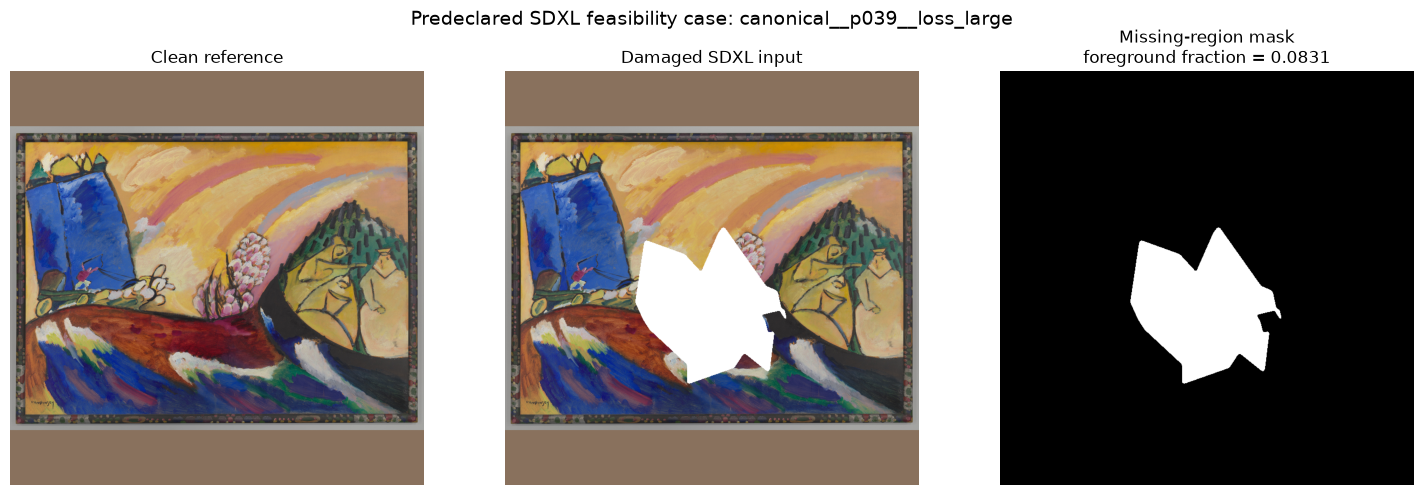

,case_id,painting_id,category,experiment_id,damage_or_degradation_type,target_damage_fraction,realized_damage_fraction,input_image_path,clean_image_path,mask_or_effect_path,eligibility_reason,input_semantics,mask_semantics,restoration_objective
0,canonical__p039__loss_large,p039,abstraction_surrealism,canonical_missing_region,binary_missing_region,0.125,0.113127,outputs/04_canonical_damaged_image_generation/...,outputs/02_image_preprocessing/images/clean/p0...,outputs/03_canonical_mask_generation/images/ma...,Approved binary missing-region restoration case.,rgb_image_with_synthetic_missing_content,binary_missing_region_mask; foreground >= 128,reconstruct deliberately removed painting content


,attempt_id,attempt_index,evidence_origin,case_id,painting_id,experiment_id,damage_or_degradation_type,input_image_path,mask_or_effect_path,input_sha256,...,gpu_peak_memory_bytes,projected_primary_hours,projected_comparable_hours,availability_state,status,failure_type,worker_return_code,error_type,error_message,issue
0,sdxl_probe__a80c364f5333,1,current_execution,canonical__p039__loss_large,p039,canonical_missing_region,binary_missing_region,outputs/04_canonical_damaged_image_generation/...,outputs/03_canonical_mask_generation/images/ma...,6d68f7e8be7320b6f253bc81c48a76dc26f1f8828d3cb7...,...,None,None,None,feasibility_only,planned,none,None,,,


,experiment_id,case_count,painting_count,zero_control_count
0,canonical_missing_region,250,50,50
1,damage_size_sensitivity,35,5,0
2,mask_robustness,75,5,0
3,synthetic_degradation,50,5,0


,category,case_count,painting_count
0,abstraction_surrealism,82,10
1,architecture_structured,82,10
2,high_texture_brushwork,82,10
3,landscape_natural,82,10
4,portrait_figure,82,10


,experiment_id,eligibility_reason,case_count
0,canonical_missing_region,Approved binary missing-region restoration case.,200
1,canonical_missing_region,Approved identity/no-op zero control for the b...,50
2,damage_size_sensitivity,Approved binary missing-region restoration case.,35
3,mask_robustness,Approved binary missing-region restoration case.,75
4,synthetic_degradation,Approved supplementary localized degradation d...,50


,path_kind,file_count,repository_relative,files_exist,inventory_recorded,dimensions_valid,modes_valid,formats_valid,inventory_readable,read_error_count
0,clean_image,50,True,True,True,True,True,True,True,0
1,input_image,410,True,True,True,True,True,True,True,0
2,mask_or_effect,410,True,True,True,True,True,True,True,0


,relative_path,repository_relative,file_exists,inventory_recorded
0,outputs/04_canonical_damaged_image_generation/...,True,True,True
1,outputs/05_damage_size_sensitivity_dataset_gen...,True,True,True
2,outputs/06_mask_robustness_dataset_generation/...,True,True,True
3,outputs/07_synthetic_degradation_dataset_gener...,True,True,True


,evidence,steps,width,height,runtime_seconds,interpretation
0,legacy_6_step_512,6,512,512,267.4,Observed legacy runtime; quality was insufficient
1,legacy_12_step_512,12,512,512,594.0,Observed legacy runtime; unrelated alterations...
2,30_step_512_linear_projection,30,512,512,1485.0,Step-only extrapolation; not an observed bench...
3,30_step_768_pixel_step_projection,30,768,768,3341.2,Pixel-and-step extrapolation; not an observed ...


,scope,item_count,per_item_guardrail_seconds,minimum_projected_hours_at_timeout
0,eligible_primary_cases,410,1500,170.833
1,comparable_candidates,1010,1500,420.833


Selected mask foreground fraction: 0.083077
Configured hard timeout: 1500 seconds
30-step 768 px rough projection: 55.69 minutes
Primary-scope lower bound at timeout: 170.83 hours
Comparable-scope lower bound at timeout: 420.83 hours


In [7]:
# ---------------------------------------------------------------------------
# Selected-case audit and inline visual inspection
# ---------------------------------------------------------------------------

selected_case_summary_columns = [
    "case_id",
    "painting_id",
    "category",
    "experiment_id",
    "damage_or_degradation_type",
    "target_damage_fraction",
    "realized_damage_fraction",
    "input_image_path",
    "clean_image_path",
    "mask_or_effect_path",
    "eligibility_reason",
    "input_semantics",
    "mask_semantics",
    "restoration_objective",
]

selected_case_summary_df = pd.DataFrame(
    [
        selected_case[
            selected_case_summary_columns
        ].to_dict()
    ]
)

selected_clean_path = (
    PROJECT_ROOT
    / str(selected_case["clean_image_path"])
)

selected_input_path = (
    PROJECT_ROOT
    / str(selected_case["input_image_path"])
)

selected_mask_path = (
    PROJECT_ROOT
    / str(selected_case["mask_or_effect_path"])
)

with Image.open(selected_clean_path) as image:
    selected_clean_image = image.convert(
        "RGB"
    ).copy()

with Image.open(selected_input_path) as image:
    selected_input_image = image.convert(
        "RGB"
    ).copy()

with Image.open(selected_mask_path) as image:
    selected_mask_image = image.convert(
        "L"
    ).copy()

selected_mask_array = np.asarray(
    selected_mask_image,
    dtype=np.uint8,
)

selected_mask_fraction = float(
    (
        selected_mask_array
        >= configured_model["mask_threshold"]
    ).mean()
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
)

axes[0].imshow(selected_clean_image)
axes[0].set_title("Clean reference")

axes[1].imshow(selected_input_image)
axes[1].set_title("Damaged SDXL input")

axes[2].imshow(
    selected_mask_image,
    cmap="gray",
    vmin=0,
    vmax=255,
)
axes[2].set_title(
    "Missing-region mask\n"
    f"foreground fraction = "
    f"{selected_mask_fraction:.4f}"
)

for axis in axes:
    axis.axis("off")

fig.suptitle(
    "Predeclared SDXL feasibility case: "
    f"{selected_case['case_id']}",
    fontsize=14,
)

plt.tight_layout()
plt.show()


# ---------------------------------------------------------------------------
# Guardrail rationale
# ---------------------------------------------------------------------------

legacy_six_step_seconds = 267.4
legacy_twelve_step_seconds = 594.0

steps_only_projection_seconds = (
    legacy_twelve_step_seconds
    * (
        configured_model[
            "num_inference_steps"
        ]
        / 12
    )
)

pixel_and_step_projection_seconds = (
    steps_only_projection_seconds
    * (
        (
            configured_model["inference_width"]
            * configured_model["inference_height"]
        )
        / (512 * 512)
    )
)

timeout_seconds = configured_execution[
    "per_attempt_timeout_seconds"
]

timeout_primary_lower_bound_hours = (
    timeout_seconds
    * configured_scope[
        "eligible_primary_case_count"
    ]
    / 3600
)

timeout_comparable_lower_bound_hours = (
    timeout_seconds
    * configured_scope[
        "comparable_candidate_count"
    ]
    / 3600
)

timeout_rationale_df = pd.DataFrame(
    [
        {
            "evidence": "legacy_6_step_512",
            "steps": 6,
            "width": 512,
            "height": 512,
            "runtime_seconds": (
                legacy_six_step_seconds
            ),
            "interpretation": (
                "Observed legacy runtime; "
                "quality was insufficient"
            ),
        },
        {
            "evidence": "legacy_12_step_512",
            "steps": 12,
            "width": 512,
            "height": 512,
            "runtime_seconds": (
                legacy_twelve_step_seconds
            ),
            "interpretation": (
                "Observed legacy runtime; "
                "unrelated alterations were visible"
            ),
        },
        {
            "evidence": "30_step_512_linear_projection",
            "steps": 30,
            "width": 512,
            "height": 512,
            "runtime_seconds": round(
                steps_only_projection_seconds,
                1,
            ),
            "interpretation": (
                "Step-only extrapolation; "
                "not an observed benchmark"
            ),
        },
        {
            "evidence": "30_step_768_pixel_step_projection",
            "steps": 30,
            "width": 768,
            "height": 768,
            "runtime_seconds": round(
                pixel_and_step_projection_seconds,
                1,
            ),
            "interpretation": (
                "Pixel-and-step extrapolation; "
                "not an observed benchmark"
            ),
        },
    ]
)

timeout_scope_lower_bounds_df = pd.DataFrame(
    [
        {
            "scope": "eligible_primary_cases",
            "item_count": configured_scope[
                "eligible_primary_case_count"
            ],
            "per_item_guardrail_seconds": (
                timeout_seconds
            ),
            "minimum_projected_hours_at_timeout": round(
                timeout_primary_lower_bound_hours,
                3,
            ),
        },
        {
            "scope": "comparable_candidates",
            "item_count": configured_scope[
                "comparable_candidate_count"
            ],
            "per_item_guardrail_seconds": (
                timeout_seconds
            ),
            "minimum_projected_hours_at_timeout": round(
                timeout_comparable_lower_bound_hours,
                3,
            ),
        },
    ]
)

display(selected_case_summary_df)
display(feasibility_attempt_plan_df)
display(worklist_experiment_summary_df)
display(worklist_category_summary_df)
display(eligibility_reason_summary_df)
display(path_kind_summary_df)
display(source_manifest_audit_df)
display(timeout_rationale_df)
display(timeout_scope_lower_bounds_df)

print(
    "Selected mask foreground fraction:",
    round(selected_mask_fraction, 6),
)
print(
    "Configured hard timeout:",
    timeout_seconds,
    "seconds",
)
print(
    "30-step 768 px rough projection:",
    round(
        pixel_and_step_projection_seconds
        / 60,
        2,
    ),
    "minutes",
)
print(
    "Primary-scope lower bound at timeout:",
    round(
        timeout_primary_lower_bound_hours,
        2,
    ),
    "hours",
)
print(
    "Comparable-scope lower bound at timeout:",
    round(
        timeout_comparable_lower_bound_hours,
        2,
    ),
    "hours",
)

In [8]:
# ---------------------------------------------------------------------------
# Batch 2 validation
# ---------------------------------------------------------------------------


def add_batch_2_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage="batch_2_input_design",
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# Upstream normalized schemas
for schema_name, validation_result in (
    (
        "artworks",
        artworks_validation,
    ),
    (
        "case_registry",
        case_registry_validation,
    ),
    (
        "model_eligibility",
        model_eligibility_validation,
    ),
):
    add_batch_2_check(
        check_id=f"schema_{schema_name}",
        description=(
            f"The {schema_name} table satisfies "
            "its normalized schema."
        ),
        expected=True,
        observed=validation_result.passed,
        passed=validation_result.passed,
        details=validation_result.to_dict(),
    )


# Exact eligible scope
approved_experiment_counts = {
    "canonical_missing_region": 250,
    "damage_size_sensitivity": 35,
    "mask_robustness": 75,
    "synthetic_degradation": 50,
}

observed_experiment_counts = (
    execution_worklist_df
    .groupby("experiment_id")
    .size()
    .to_dict()
)

add_batch_2_check(
    check_id="eligible_case_count",
    description=(
        "The SDXL feasibility worklist contains the same "
        "410 eligible cases as Notebook 11."
    ),
    expected=410,
    observed=len(execution_worklist_df),
    passed=(
        len(execution_worklist_df) == 410
    ),
)

add_batch_2_check(
    check_id="eligible_control_structure",
    description=(
        "The eligible scope contains 360 nonzero cases "
        "and 50 zero controls."
    ),
    expected={
        "nonzero": 360,
        "zero_control": 50,
    },
    observed={
        "nonzero": nonzero_case_count,
        "zero_control": zero_control_count,
    },
    passed=(
        nonzero_case_count == 360
        and zero_control_count == 50
    ),
)

add_batch_2_check(
    check_id="eligible_experiment_counts",
    description=(
        "Eligible cases match the approved experiment scopes."
    ),
    expected=approved_experiment_counts,
    observed=observed_experiment_counts,
    passed=(
        observed_experiment_counts
        == approved_experiment_counts
    ),
)


# Referenced inputs
referenced_file_columns = [
    "repository_relative",
    "file_exists",
    "inventory_recorded",
    "dimensions_valid",
    "mode_valid",
    "format_valid",
    "inventory_readable",
]

referenced_files_passed = bool(
    worklist_path_audit_df[
        referenced_file_columns
    ]
    .all(axis=1)
    .all()
    and worklist_path_audit_df[
        "read_error"
    ]
    .astype(str)
    .str.len()
    .eq(0)
    .all()
)

add_batch_2_check(
    check_id="referenced_image_contract",
    description=(
        "Every referenced input, clean image, and mask "
        "is repository-relative, inventoried, readable, "
        "768 × 768 PNG, and has the expected mode."
    ),
    expected=True,
    observed=referenced_files_passed,
    passed=referenced_files_passed,
    details=path_kind_summary_df.to_dict(
        orient="records"
    ),
)

source_manifests_passed = bool(
    source_manifest_audit_df[
        [
            "repository_relative",
            "file_exists",
            "inventory_recorded",
        ]
    ]
    .all(axis=1)
    .all()
)

add_batch_2_check(
    check_id="source_manifest_contract",
    description=(
        "Every source manifest is repository-relative, "
        "present, and inventoried."
    ),
    expected=True,
    observed=source_manifests_passed,
    passed=source_manifests_passed,
    details=source_manifest_audit_df.to_dict(
        orient="records"
    ),
)


# Predeclared feasibility case
selected_case_valid = bool(
    selected_case["case_id"]
    == "canonical__p039__loss_large"
    and selected_case["experiment_id"]
    == "canonical_missing_region"
    and selected_case[
        "damage_or_degradation_type"
    ] == "binary_missing_region"
    and selected_case[
        "mask_or_effect_id"
    ] == "mask__canonical__p039__loss_large"
    and not bool(
        selected_case["is_zero_control"]
    )
    and float(
        selected_case[
            "realized_damage_fraction"
        ]
    ) > 0
)

add_batch_2_check(
    check_id="predeclared_feasibility_case",
    description=(
        "The selected feasibility case is the exact "
        "predeclared canonical large-loss case."
    ),
    expected="canonical__p039__loss_large",
    observed=selected_case["case_id"],
    passed=selected_case_valid,
)

add_batch_2_check(
    check_id="selection_is_non_metric",
    description=(
        "The case-selection policy is fixed before "
        "restoration and prohibits metric selection."
    ),
    expected={
        "policy": (
            "predeclared_representative_non_metric.v1"
        ),
        "prohibit_metric_selection": True,
    },
    observed={
        "policy": configured_selection[
            "policy_id"
        ],
        "prohibit_metric_selection": (
            configured_selection[
                "prohibit_metric_selection"
            ]
        ),
    },
    passed=(
        configured_selection["policy_id"]
        == "predeclared_representative_non_metric.v1"
        and configured_selection[
            "prohibit_metric_selection"
        ]
    ),
)

add_batch_2_check(
    check_id="selected_mask_support",
    description=(
        "The selected feasibility mask has nonzero "
        "foreground support below full-image coverage."
    ),
    expected={
        "greater_than": 0.0,
        "less_than": 1.0,
    },
    observed=selected_mask_fraction,
    passed=(
        0.0
        < selected_mask_fraction
        < 1.0
    ),
)


# Exact feasibility-attempt design
add_batch_2_check(
    check_id="attempt_plan_schema",
    description=(
        "The feasibility-attempt plan satisfies its "
        "normalized schema."
    ),
    expected=True,
    observed=attempt_plan_validation.passed,
    passed=attempt_plan_validation.passed,
    details=attempt_plan_validation.to_dict(),
)

planned_attempt = (
    feasibility_attempt_plan_df.iloc[0]
)

add_batch_2_check(
    check_id="attempt_plan_cardinality",
    description=(
        "Exactly one current-execution SDXL attempt "
        "is planned."
    ),
    expected=1,
    observed=len(feasibility_attempt_plan_df),
    passed=(
        len(feasibility_attempt_plan_df) == 1
        and feasibility_attempt_plan_df[
            "attempt_id"
        ].is_unique
        and planned_attempt[
            "evidence_origin"
        ] == "current_execution"
        and planned_attempt["status"] == "planned"
    ),
)

checksum_contract_valid = bool(
    feasibility_attempt_plan_df[
        "input_sha256"
    ]
    .astype(str)
    .str.fullmatch(r"[0-9a-f]{64}")
    .all()
    and feasibility_attempt_plan_df[
        "mask_sha256"
    ]
    .astype(str)
    .str.fullmatch(r"[0-9a-f]{64}")
    .all()
)

add_batch_2_check(
    check_id="attempt_input_checksums",
    description=(
        "The planned attempt records complete input "
        "and mask SHA-256 checksums."
    ),
    expected=True,
    observed=checksum_contract_valid,
    passed=checksum_contract_valid,
)

attempt_settings_valid = bool(
    planned_attempt[
        "case_id"
    ] == "canonical__p039__loss_large"
    and planned_attempt[
        "num_inference_steps"
    ] == 30
    and planned_attempt[
        "inference_width"
    ] == 768
    and planned_attempt[
        "inference_height"
    ] == 768
    and planned_attempt[
        "precision"
    ] == "float16"
    and planned_attempt[
        "requested_device"
    ] == "cuda"
    and planned_attempt[
        "timeout_seconds"
    ] == 1500
    and planned_attempt[
        "model_cpu_offload"
    ]
    and not planned_attempt[
        "sequential_cpu_offload"
    ]
    and not planned_attempt[
        "attention_slicing"
    ]
    and planned_attempt[
        "vae_slicing"
    ]
    and planned_attempt[
        "vae_tiling"
    ]
)

add_batch_2_check(
    check_id="attempt_execution_policy",
    description=(
        "The attempt freezes the approved quality, "
        "device, timeout, and memory settings."
    ),
    expected=True,
    observed=attempt_settings_valid,
    passed=attempt_settings_valid,
)


# Guardrail interpretation
add_batch_2_check(
    check_id="timeout_feasibility_boundary",
    description=(
        "The 25-minute per-item timeout already implies "
        "an infeasible full local execution lower bound."
    ),
    expected={
        "primary_lower_bound_hours_at_timeout": (
            "greater_than_170"
        ),
        "comparable_lower_bound_hours_at_timeout": (
            "greater_than_420"
        ),
    },
    observed={
        "primary_lower_bound_hours_at_timeout": round(
            timeout_primary_lower_bound_hours,
            3,
        ),
        "comparable_lower_bound_hours_at_timeout": round(
            timeout_comparable_lower_bound_hours,
            3,
        ),
    },
    passed=(
        timeout_primary_lower_bound_hours > 170
        and timeout_comparable_lower_bound_hours > 420
    ),
    details=(
        "These are censored lower bounds if the worker "
        "times out, not completed-runtime estimates."
    ),
)


# No premature model or output execution
current_output_files = [
    path
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
]

add_batch_2_check(
    check_id="no_premature_outputs",
    description=(
        "Batch 2 created no canonical files and performed "
        "no SDXL inference."
    ),
    expected=0,
    observed=len(current_output_files),
    passed=len(current_output_files) == 0,
    details=[
        to_repo_relative(path, PROJECT_ROOT)
        for path in current_output_files
    ],
)


# ---------------------------------------------------------------------------
# Render and enforce the Batch 2 gate
# ---------------------------------------------------------------------------

BATCH_2_VALIDATION_DF = VALIDATION.to_dataframe()

BATCH_2_ONLY_VALIDATION_DF = (
    BATCH_2_VALIDATION_DF.loc[
        BATCH_2_VALIDATION_DF[
            "validation_stage"
        ].eq("batch_2_input_design")
    ]
    .reset_index(drop=True)
)

BATCH_2_VALIDATION_SUMMARY = VALIDATION.summary()

display(path_kind_summary_df)
display(source_manifest_audit_df)
display(selected_case_summary_df)
display(feasibility_attempt_plan_df)
display(timeout_scope_lower_bounds_df)
display(BATCH_2_ONLY_VALIDATION_DF)

print("Batch 2 cumulative validation summary:")
print(
    json.dumps(
        BATCH_2_VALIDATION_SUMMARY,
        indent=2,
    )
)

VALIDATION.raise_for_blocking()

print(
    "Batch 2 passed. The 410-case normalized handoff, "
    "predeclared feasibility case, referenced images, "
    "single-attempt design, input checksums, and timeout "
    "feasibility boundary are valid. No model was loaded "
    "and no restoration was generated."
)

,path_kind,file_count,repository_relative,files_exist,inventory_recorded,dimensions_valid,modes_valid,formats_valid,inventory_readable,read_error_count
0,clean_image,50,True,True,True,True,True,True,True,0
1,input_image,410,True,True,True,True,True,True,True,0
2,mask_or_effect,410,True,True,True,True,True,True,True,0


,relative_path,repository_relative,file_exists,inventory_recorded
0,outputs/04_canonical_damaged_image_generation/...,True,True,True
1,outputs/05_damage_size_sensitivity_dataset_gen...,True,True,True
2,outputs/06_mask_robustness_dataset_generation/...,True,True,True
3,outputs/07_synthetic_degradation_dataset_gener...,True,True,True


,case_id,painting_id,category,experiment_id,damage_or_degradation_type,target_damage_fraction,realized_damage_fraction,input_image_path,clean_image_path,mask_or_effect_path,eligibility_reason,input_semantics,mask_semantics,restoration_objective
0,canonical__p039__loss_large,p039,abstraction_surrealism,canonical_missing_region,binary_missing_region,0.125,0.113127,outputs/04_canonical_damaged_image_generation/...,outputs/02_image_preprocessing/images/clean/p0...,outputs/03_canonical_mask_generation/images/ma...,Approved binary missing-region restoration case.,rgb_image_with_synthetic_missing_content,binary_missing_region_mask; foreground >= 128,reconstruct deliberately removed painting content


,attempt_id,attempt_index,evidence_origin,case_id,painting_id,experiment_id,damage_or_degradation_type,input_image_path,mask_or_effect_path,input_sha256,...,gpu_peak_memory_bytes,projected_primary_hours,projected_comparable_hours,availability_state,status,failure_type,worker_return_code,error_type,error_message,issue
0,sdxl_probe__a80c364f5333,1,current_execution,canonical__p039__loss_large,p039,canonical_missing_region,binary_missing_region,outputs/04_canonical_damaged_image_generation/...,outputs/03_canonical_mask_generation/images/ma...,6d68f7e8be7320b6f253bc81c48a76dc26f1f8828d3cb7...,...,None,None,None,feasibility_only,planned,none,None,,,


,scope,item_count,per_item_guardrail_seconds,minimum_projected_hours_at_timeout
0,eligible_primary_cases,410,1500,170.833
1,comparable_candidates,1010,1500,420.833


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_2_input_design,schema_artworks,The artworks table satisfies its normalized sc...,blocking,True,True,True,"{""column_count"": 36, ""duplicate_primary_key_ro..."
1,batch_2_input_design,schema_case_registry,The case_registry table satisfies its normaliz...,blocking,True,True,True,"{""column_count"": 14, ""duplicate_primary_key_ro..."
2,batch_2_input_design,schema_model_eligibility,The model_eligibility table satisfies its norm...,blocking,True,True,True,"{""column_count"": 7, ""duplicate_primary_key_row..."
3,batch_2_input_design,eligible_case_count,The SDXL feasibility worklist contains the sam...,blocking,410,410,True,
4,batch_2_input_design,eligible_control_structure,The eligible scope contains 360 nonzero cases ...,blocking,"{""nonzero"": 360, ""zero_control"": 50}","{""nonzero"": 360, ""zero_control"": 50}",True,
5,batch_2_input_design,eligible_experiment_counts,Eligible cases match the approved experiment s...,blocking,"{""canonical_missing_region"": 250, ""damage_size...","{""canonical_missing_region"": 250, ""damage_size...",True,
6,batch_2_input_design,referenced_image_contract,"Every referenced input, clean image, and mask ...",blocking,True,True,True,"[{""dimensions_valid"": true, ""file_count"": 50, ..."
7,batch_2_input_design,source_manifest_contract,"Every source manifest is repository-relative, ...",blocking,True,True,True,"[{""file_exists"": true, ""inventory_recorded"": t..."
8,batch_2_input_design,predeclared_feasibility_case,The selected feasibility case is the exact pre...,blocking,canonical__p039__loss_large,canonical__p039__loss_large,True,
9,batch_2_input_design,selection_is_non_metric,The case-selection policy is fixed before rest...,blocking,"{""policy"": ""predeclared_representative_non_met...","{""policy"": ""predeclared_representative_non_met...",True,


Batch 2 cumulative validation summary:
{
  "check_count": 44,
  "passed_count": 44,
  "failed_count": 0,
  "blocking_failure_count": 0,
  "overall_passed": true,
  "failed_check_ids": []
}
Batch 2 passed. The 410-case normalized handoff, predeclared feasibility case, referenced images, single-attempt design, input checksums, and timeout feasibility boundary are valid. No model was loaded and no restoration was generated.


## Batch 3 - Isolated Worker and Watchdog Preflight

This batch validates the expensive-execution boundary before SDXL is loaded.

It:

- builds the exact worker-job payload without writing or executing it;
- verifies all pinned model snapshot components;
- verifies the FP16 weights, scheduler, tokenizers, encoders, UNet, and VAE;
- verifies that all worker paths are confined to the notebook-owned `work/attempts` directory;
- verifies the prompt, seed, inference, compositing, and memory policies passed to the worker;
- confirms the installed Diffusers pipeline, DDIM scheduler, PyTorch SDPA, CPU-offload, and VAE memory capabilities;
- runs harmless short-lived subprocesses to prove that the parent watchdog detects normal completion and forcibly terminates an overlong worker;
- confirms that no model or restoration output was created.

The watchdog subprocess test does not import or load SDXL. The actual model remains unloaded until Batch 4.

In [9]:
from diffusers import (
    DDIMScheduler,
    StableDiffusionXLInpaintPipeline,
)

from restoration_eval.restoration_sdxl import (
    build_worker_job,
    run_worker_process,
)


# ---------------------------------------------------------------------------
# Build the exact worker job without writing it
# ---------------------------------------------------------------------------

planned_attempt_record = (
    feasibility_attempt_plan_df
    .iloc[0]
    .to_dict()
)

(
    worker_job_payload,
    worker_job_path,
    worker_result_path,
    worker_output_path,
) = build_worker_job(
    planned_attempt_record,
    sdxl_config,
    project_root=PROJECT_ROOT,
    work_directory=OUTPUTS[
        "attempt_work_directory"
    ],
)

WORKER_OWNED_PATHS = (
    worker_job_path,
    worker_result_path,
    worker_output_path,
)


# ---------------------------------------------------------------------------
# Pinned snapshot-component audit
# ---------------------------------------------------------------------------

snapshot_root = Path(
    local_cache_audit["snapshot_path"]
)

required_snapshot_components = [
    "model_index.json",
    "scheduler/scheduler_config.json",
    "text_encoder/config.json",
    "text_encoder/model.fp16.safetensors",
    "text_encoder_2/config.json",
    "text_encoder_2/model.fp16.safetensors",
    "tokenizer/merges.txt",
    "tokenizer/special_tokens_map.json",
    "tokenizer/tokenizer_config.json",
    "tokenizer/vocab.json",
    "tokenizer_2/merges.txt",
    "tokenizer_2/special_tokens_map.json",
    "tokenizer_2/tokenizer_config.json",
    "tokenizer_2/vocab.json",
    "unet/config.json",
    "unet/diffusion_pytorch_model.fp16.safetensors",
    "vae/config.json",
    "vae/diffusion_pytorch_model.fp16.safetensors",
]

snapshot_component_records = []

for relative_path in required_snapshot_components:
    component_path = (
        snapshot_root / relative_path
    )

    snapshot_component_records.append(
        {
            "relative_path": relative_path,
            "exists": component_path.is_file(),
            "size_bytes": (
                int(component_path.stat().st_size)
                if component_path.is_file()
                else None
            ),
            "is_fp16_weight": (
                relative_path.endswith(
                    ".fp16.safetensors"
                )
            ),
        }
    )

snapshot_component_audit_df = pd.DataFrame(
    snapshot_component_records
)

snapshot_weight_summary_df = (
    snapshot_component_audit_df.loc[
        snapshot_component_audit_df[
            "is_fp16_weight"
        ]
    ]
    .copy()
)

unexpected_incomplete_cache_files = sorted(
    path.relative_to(
        snapshot_root
    ).as_posix()
    for path in snapshot_root.rglob(
        "*.incomplete"
    )
)


# ---------------------------------------------------------------------------
# Worker payload preview
# ---------------------------------------------------------------------------

worker_payload_preview_keys = [
    "job_schema_version",
    "attempt_id",
    "input_path",
    "mask_path",
    "output_path",
    "hf_model_id",
    "model_revision",
    "local_files_only",
    "precision",
    "scheduler",
    "seed",
    "num_inference_steps",
    "guidance_scale",
    "strength",
    "inference_width",
    "inference_height",
    "output_width",
    "output_height",
    "mask_threshold",
    "compositing_policy",
    "model_cpu_offload",
    "sequential_cpu_offload",
    "attention_slicing",
    "vae_slicing",
    "vae_tiling",
    "allow_tf32",
]

worker_payload_preview_df = pd.DataFrame(
    [
        {
            "field": key,
            "value": worker_job_payload[key],
        }
        for key in worker_payload_preview_keys
    ]
)

existing_worker_owned_paths = [
    path
    for path in WORKER_OWNED_PATHS
    if path.exists()
]

print("Worker job schema:", worker_job_payload["job_schema_version"])
print("Worker attempt:", worker_job_payload["attempt_id"])
print("Worker job path:", worker_job_path)
print("Worker result path:", worker_result_path)
print("Temporary probe image:", worker_output_path)
print(
    "Required snapshot components:",
    len(snapshot_component_audit_df),
)
print(
    "Missing snapshot components:",
    int(
        (
            ~snapshot_component_audit_df["exists"]
        ).sum()
    ),
)
print(
    "Existing worker-owned files:",
    len(existing_worker_owned_paths),
)

D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\transformers\utils\hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


Worker job schema: sdxl_worker_job.v1
Worker attempt: sdxl_probe__a80c364f5333
Worker job path: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\12_sdxl_feasibility_or_restoration\work\attempts\sdxl_probe__a80c364f5333.job.json
Worker result path: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\12_sdxl_feasibility_or_restoration\work\attempts\sdxl_probe__a80c364f5333.result.json
Temporary probe image: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\12_sdxl_feasibility_or_restoration\work\attempts\sdxl_probe__a80c364f5333.png
Required snapshot components: 18
Missing snapshot components: 0
Existing worker-owned files: 0


In [10]:
# ---------------------------------------------------------------------------
# Installed execution-capability preflight
# ---------------------------------------------------------------------------

sdpa_available = hasattr(
    torch.nn.functional,
    "scaled_dot_product_attention",
)

model_cpu_offload_available = hasattr(
    StableDiffusionXLInpaintPipeline,
    "enable_model_cpu_offload",
)

sequential_cpu_offload_available = hasattr(
    StableDiffusionXLInpaintPipeline,
    "enable_sequential_cpu_offload",
)

vae_slicing_available = hasattr(
    StableDiffusionXLInpaintPipeline,
    "enable_vae_slicing",
)

vae_tiling_available = hasattr(
    StableDiffusionXLInpaintPipeline,
    "enable_vae_tiling",
)

pipeline_from_pretrained_available = callable(
    getattr(
        StableDiffusionXLInpaintPipeline,
        "from_pretrained",
        None,
    )
)

ddim_from_config_available = callable(
    getattr(
        DDIMScheduler,
        "from_config",
        None,
    )
)

if CUDA_AVAILABLE:
    cuda_capability = tuple(
        int(value)
        for value in torch.cuda.get_device_capability(0)
    )

    cuda_memory_allocated_before_worker = int(
        torch.cuda.memory_allocated(0)
    )

    cuda_memory_reserved_before_worker = int(
        torch.cuda.memory_reserved(0)
    )
else:
    cuda_capability = ()
    cuda_memory_allocated_before_worker = 0
    cuda_memory_reserved_before_worker = 0

execution_capability_df = pd.DataFrame(
    [
        {
            "capability": "sdxl_pipeline_class",
            "available": (
                pipeline_from_pretrained_available
            ),
            "selected": True,
        },
        {
            "capability": "ddim_scheduler",
            "available": (
                ddim_from_config_available
            ),
            "selected": True,
        },
        {
            "capability": "pytorch_sdpa",
            "available": sdpa_available,
            "selected": True,
        },
        {
            "capability": "model_cpu_offload",
            "available": (
                model_cpu_offload_available
            ),
            "selected": True,
        },
        {
            "capability": (
                "sequential_cpu_offload"
            ),
            "available": (
                sequential_cpu_offload_available
            ),
            "selected": False,
        },
        {
            "capability": "vae_slicing",
            "available": vae_slicing_available,
            "selected": True,
        },
        {
            "capability": "vae_tiling",
            "available": vae_tiling_available,
            "selected": True,
        },
    ]
)

print("CUDA capability:", cuda_capability)
print(
    "CUDA memory allocated before worker:",
    cuda_memory_allocated_before_worker,
)
print(
    "CUDA memory reserved before worker:",
    cuda_memory_reserved_before_worker,
)
print("PyTorch SDPA available:", sdpa_available)
print(
    "Model CPU offload available:",
    model_cpu_offload_available,
)
print(
    "VAE slicing available:",
    vae_slicing_available,
)
print(
    "VAE tiling available:",
    vae_tiling_available,
)

CUDA capability: (8, 6)
CUDA memory allocated before worker: 0
CUDA memory reserved before worker: 0
PyTorch SDPA available: True
Model CPU offload available: True
VAE slicing available: True
VAE tiling available: True


In [11]:
# ---------------------------------------------------------------------------
# Harmless isolated-process watchdog tests
# ---------------------------------------------------------------------------

print(
    "Watchdog test 1/2: checking normal child-process completion."
)

watchdog_quick_result = run_worker_process(
    [
        sys.executable,
        "-c",
        (
            "print("
            "'watchdog_quick_exit'"
            ")"
        ),
    ],
    timeout_seconds=5.0,
    cwd=PROJECT_ROOT,
)

print(
    "Watchdog test 2/2: checking forced termination "
    "of an overlong child process."
)

watchdog_timeout_result = run_worker_process(
    [
        sys.executable,
        "-c",
        (
            "import time; "
            "time.sleep(5)"
        ),
    ],
    timeout_seconds=0.25,
    cwd=PROJECT_ROOT,
)

synthetic_watchdog_summary_df = pd.DataFrame(
    [
        {
            "test_id": "quick_completion",
            "configured_timeout_seconds": 5.0,
            "timed_out": (
                watchdog_quick_result.timed_out
            ),
            "return_code": (
                watchdog_quick_result.return_code
            ),
            "runtime_seconds": (
                watchdog_quick_result.runtime_seconds
            ),
            "stdout": (
                watchdog_quick_result.stdout.strip()
            ),
            "stderr": (
                watchdog_quick_result.stderr.strip()
            ),
        },
        {
            "test_id": "forced_timeout",
            "configured_timeout_seconds": 0.25,
            "timed_out": (
                watchdog_timeout_result.timed_out
            ),
            "return_code": (
                watchdog_timeout_result.return_code
            ),
            "runtime_seconds": (
                watchdog_timeout_result.runtime_seconds
            ),
            "stdout": (
                watchdog_timeout_result.stdout.strip()
            ),
            "stderr": (
                watchdog_timeout_result.stderr.strip()
            ),
        },
    ]
)

display(snapshot_component_audit_df)
display(snapshot_weight_summary_df)
display(worker_payload_preview_df)
display(execution_capability_df)
display(synthetic_watchdog_summary_df)

print(
    "Quick process completed:",
    not watchdog_quick_result.timed_out,
)
print(
    "Overlong process terminated:",
    watchdog_timeout_result.timed_out,
)
print(
    "Overlong-process runtime:",
    watchdog_timeout_result.runtime_seconds,
    "seconds",
)
print(
    "SDXL remains unloaded; only harmless Python "
    "child processes were launched."
)

Watchdog test 1/2: checking normal child-process completion.
Watchdog test 2/2: checking forced termination of an overlong child process.


,relative_path,exists,size_bytes,is_fp16_weight
0,model_index.json,True,690,False
1,scheduler/scheduler_config.json,True,479,False
2,text_encoder/config.json,True,746,False
3,text_encoder/model.fp16.safetensors,True,246144867,True
4,text_encoder_2/config.json,True,758,False
5,text_encoder_2/model.fp16.safetensors,True,1389382884,True
6,tokenizer/merges.txt,True,524619,False
7,tokenizer/special_tokens_map.json,True,472,False
8,tokenizer/tokenizer_config.json,True,737,False
9,tokenizer/vocab.json,True,1059962,False


,relative_path,exists,size_bytes,is_fp16_weight
3,text_encoder/model.fp16.safetensors,True,246144867,True
5,text_encoder_2/model.fp16.safetensors,True,1389382884,True
15,unet/diffusion_pytorch_model.fp16.safetensors,True,5135178560,True
17,vae/diffusion_pytorch_model.fp16.safetensors,True,167335338,True


,field,value
0,job_schema_version,sdxl_worker_job.v1
1,attempt_id,sdxl_probe__a80c364f5333
2,input_path,D:\Masters\FH\Thesis\painting-restoration-eval...
3,mask_path,D:\Masters\FH\Thesis\painting-restoration-eval...
4,output_path,D:\Masters\FH\Thesis\painting-restoration-eval...
5,hf_model_id,diffusers/stable-diffusion-xl-1.0-inpainting-0.1
6,model_revision,115134f363124c53c7d878647567d04daf26e41e
7,local_files_only,True
8,precision,float16
9,scheduler,DDIMScheduler


,capability,available,selected
0,sdxl_pipeline_class,True,True
1,ddim_scheduler,True,True
2,pytorch_sdpa,True,True
3,model_cpu_offload,True,True
4,sequential_cpu_offload,True,False
5,vae_slicing,True,True
6,vae_tiling,True,True


,test_id,configured_timeout_seconds,timed_out,return_code,runtime_seconds,stdout,stderr
0,quick_completion,5.00,False,0,0.114,watchdog_quick_exit,
1,forced_timeout,0.25,True,1,0.277,,


Quick process completed: True
Overlong process terminated: True
Overlong-process runtime: 0.277 seconds
SDXL remains unloaded; only harmless Python child processes were launched.


In [12]:
# ---------------------------------------------------------------------------
# Batch 3 validation
# ---------------------------------------------------------------------------


def add_batch_3_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage="batch_3_worker_preflight",
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# Complete pinned snapshot
snapshot_components_complete = bool(
    snapshot_component_audit_df[
        "exists"
    ].all()
    and snapshot_component_audit_df[
        "size_bytes"
    ].fillna(0).gt(0).all()
)

add_batch_3_check(
    check_id="snapshot_components",
    description=(
        "All 18 required pinned SDXL snapshot "
        "components exist and are nonempty."
    ),
    expected={
        "component_count": 18,
        "missing_count": 0,
    },
    observed={
        "component_count": len(
            snapshot_component_audit_df
        ),
        "missing_count": int(
            (
                ~snapshot_component_audit_df[
                    "exists"
                ]
            ).sum()
        ),
    },
    passed=(
        len(snapshot_component_audit_df) == 18
        and snapshot_components_complete
    ),
    details=snapshot_component_audit_df.to_dict(
        orient="records"
    ),
)

add_batch_3_check(
    check_id="fp16_weight_components",
    description=(
        "Both text encoders, the UNet, and the VAE "
        "use pinned FP16 Safetensors weights."
    ),
    expected=4,
    observed=len(snapshot_weight_summary_df),
    passed=(
        len(snapshot_weight_summary_df) == 4
        and snapshot_weight_summary_df[
            "exists"
        ].all()
        and snapshot_weight_summary_df[
            "relative_path"
        ]
        .str.endswith(
            ".fp16.safetensors"
        )
        .all()
    ),
)

add_batch_3_check(
    check_id="cache_has_no_incomplete_files",
    description=(
        "The pinned snapshot contains no incomplete "
        "download fragments."
    ),
    expected=[],
    observed=unexpected_incomplete_cache_files,
    passed=not unexpected_incomplete_cache_files,
)


# Exact worker-job contract
required_worker_job_keys = {
    "job_schema_version",
    "attempt_id",
    "input_path",
    "mask_path",
    "output_path",
    "hf_model_id",
    "model_revision",
    "local_files_only",
    "precision",
    "scheduler",
    "prompt",
    "negative_prompt",
    "seed",
    "num_inference_steps",
    "guidance_scale",
    "strength",
    "inference_width",
    "inference_height",
    "output_width",
    "output_height",
    "mask_threshold",
    "compositing_policy",
    "safety_checker_policy",
    "model_cpu_offload",
    "sequential_cpu_offload",
    "attention_slicing",
    "vae_slicing",
    "vae_tiling",
    "allow_tf32",
}

missing_worker_job_keys = sorted(
    required_worker_job_keys
    - set(worker_job_payload)
)

add_batch_3_check(
    check_id="worker_job_schema",
    description=(
        "The worker payload contains the complete "
        "versioned execution contract."
    ),
    expected={
        "schema": "sdxl_worker_job.v1",
        "missing_keys": [],
    },
    observed={
        "schema": worker_job_payload[
            "job_schema_version"
        ],
        "missing_keys": missing_worker_job_keys,
    },
    passed=(
        worker_job_payload[
            "job_schema_version"
        ] == "sdxl_worker_job.v1"
        and not missing_worker_job_keys
    ),
)

worker_root = OUTPUTS[
    "attempt_work_directory"
].resolve()

worker_paths_scoped = all(
    path.resolve().parent == worker_root
    for path in WORKER_OWNED_PATHS
)

add_batch_3_check(
    check_id="worker_path_ownership",
    description=(
        "Every temporary worker path is directly owned by "
        "the Notebook 12 work/attempts directory."
    ),
    expected=True,
    observed=worker_paths_scoped,
    passed=worker_paths_scoped,
    details=[
        str(path)
        for path in WORKER_OWNED_PATHS
    ],
)

add_batch_3_check(
    check_id="worker_paths_start_absent",
    description=(
        "No stale worker job, result, or temporary probe "
        "image exists before execution."
    ),
    expected=[],
    observed=[
        str(path)
        for path in existing_worker_owned_paths
    ],
    passed=not existing_worker_owned_paths,
)

worker_input_path = Path(
    worker_job_payload["input_path"]
)

worker_mask_path = Path(
    worker_job_payload["mask_path"]
)

worker_inputs_valid = bool(
    worker_input_path.is_file()
    and worker_mask_path.is_file()
    and sha256_file(worker_input_path)
    == planned_attempt_record["input_sha256"]
    and sha256_file(worker_mask_path)
    == planned_attempt_record["mask_sha256"]
)

add_batch_3_check(
    check_id="worker_input_identity",
    description=(
        "The absolute worker inputs exist and exactly match "
        "the checksums frozen in the attempt plan."
    ),
    expected=True,
    observed=worker_inputs_valid,
    passed=worker_inputs_valid,
)

worker_model_policy_valid = bool(
    worker_job_payload["hf_model_id"]
    == configured_model["hf_model_id"]
    and worker_job_payload["model_revision"]
    == configured_model["model_revision"]
    and worker_job_payload["local_files_only"]
    and worker_job_payload["precision"]
    == "float16"
    and worker_job_payload["scheduler"]
    == "DDIMScheduler"
    and worker_job_payload[
        "num_inference_steps"
    ] == 30
    and worker_job_payload[
        "inference_width"
    ] == 768
    and worker_job_payload[
        "inference_height"
    ] == 768
)

add_batch_3_check(
    check_id="worker_model_policy",
    description=(
        "The worker receives the exact pinned local model "
        "and quality-oriented inference settings."
    ),
    expected=True,
    observed=worker_model_policy_valid,
    passed=worker_model_policy_valid,
)

worker_prompt_policy_valid = bool(
    worker_job_payload["prompt"]
    == configured_prompt["prompt"]
    and worker_job_payload[
        "negative_prompt"
    ] == configured_prompt[
        "negative_prompt"
    ]
    and worker_job_payload["seed"]
    == configured_model["seed"]
)

add_batch_3_check(
    check_id="worker_prompt_policy",
    description=(
        "The worker receives the approved prompt, negative "
        "prompt, and fixed seed without per-case tuning."
    ),
    expected=True,
    observed=worker_prompt_policy_valid,
    passed=worker_prompt_policy_valid,
)

worker_memory_policy_valid = bool(
    worker_job_payload["model_cpu_offload"]
    and not worker_job_payload[
        "sequential_cpu_offload"
    ]
    and not worker_job_payload[
        "attention_slicing"
    ]
    and worker_job_payload["vae_slicing"]
    and worker_job_payload["vae_tiling"]
    and not worker_job_payload["allow_tf32"]
)

add_batch_3_check(
    check_id="worker_memory_policy",
    description=(
        "The worker receives only the approved "
        "quality-preserving memory strategy."
    ),
    expected=True,
    observed=worker_memory_policy_valid,
    passed=worker_memory_policy_valid,
)

add_batch_3_check(
    check_id="worker_compositing_policy",
    description=(
        "The worker uses inclusive mask thresholding and "
        "exact outside-mask preservation."
    ),
    expected={
        "mask_threshold": 128,
        "compositing_policy": (
            "masked_composite_preserve_outside.v1"
        ),
    },
    observed={
        "mask_threshold": worker_job_payload[
            "mask_threshold"
        ],
        "compositing_policy": (
            worker_job_payload[
                "compositing_policy"
            ]
        ),
    },
    passed=(
        worker_job_payload["mask_threshold"] == 128
        and worker_job_payload[
            "compositing_policy"
        ] == "masked_composite_preserve_outside.v1"
    ),
)


# Installed capabilities
selected_capabilities_available = bool(
    execution_capability_df.loc[
        execution_capability_df["selected"],
        "available",
    ].all()
)

add_batch_3_check(
    check_id="execution_capabilities",
    description=(
        "All selected pipeline, scheduler, SDPA, offload, "
        "and VAE capabilities are installed."
    ),
    expected=True,
    observed=selected_capabilities_available,
    passed=selected_capabilities_available,
    details=execution_capability_df.to_dict(
        orient="records"
    ),
)


# Parent watchdog behavior
quick_watchdog_passed = bool(
    not watchdog_quick_result.timed_out
    and watchdog_quick_result.return_code == 0
    and "watchdog_quick_exit"
    in watchdog_quick_result.stdout
)

add_batch_3_check(
    check_id="watchdog_normal_completion",
    description=(
        "The parent watchdog permits a normally completing "
        "child process to exit successfully."
    ),
    expected=True,
    observed=quick_watchdog_passed,
    passed=quick_watchdog_passed,
    details=synthetic_watchdog_summary_df.to_dict(
        orient="records"
    ),
)

timeout_watchdog_passed = bool(
    watchdog_timeout_result.timed_out
    and watchdog_timeout_result.return_code
    is not None
    and watchdog_timeout_result.runtime_seconds
    < 3.0
)

add_batch_3_check(
    check_id="watchdog_forced_termination",
    description=(
        "The parent watchdog forcibly terminates an "
        "overlong isolated child process."
    ),
    expected=True,
    observed=timeout_watchdog_passed,
    passed=timeout_watchdog_passed,
    details=synthetic_watchdog_summary_df.to_dict(
        orient="records"
    ),
)


# No model execution
current_output_files = [
    path
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
]

add_batch_3_check(
    check_id="no_model_or_output_execution",
    description=(
        "The SDXL model remains unloaded and Batch 3 "
        "created no notebook output files."
    ),
    expected={
        "output_file_count": 0,
        "worker_owned_path_count": 0,
    },
    observed={
        "output_file_count": len(
            current_output_files
        ),
        "worker_owned_path_count": sum(
            path.exists()
            for path in WORKER_OWNED_PATHS
        ),
    },
    passed=(
        len(current_output_files) == 0
        and not any(
            path.exists()
            for path in WORKER_OWNED_PATHS
        )
    ),
)


# ---------------------------------------------------------------------------
# Render and enforce the Batch 3 gate
# ---------------------------------------------------------------------------

BATCH_3_VALIDATION_DF = VALIDATION.to_dataframe()

BATCH_3_ONLY_VALIDATION_DF = (
    BATCH_3_VALIDATION_DF.loc[
        BATCH_3_VALIDATION_DF[
            "validation_stage"
        ].eq("batch_3_worker_preflight")
    ]
    .reset_index(drop=True)
)

BATCH_3_VALIDATION_SUMMARY = VALIDATION.summary()

display(snapshot_component_audit_df)
display(worker_payload_preview_df)
display(execution_capability_df)
display(synthetic_watchdog_summary_df)
display(BATCH_3_ONLY_VALIDATION_DF)

print("Batch 3 cumulative validation summary:")
print(
    json.dumps(
        BATCH_3_VALIDATION_SUMMARY,
        indent=2,
    )
)

VALIDATION.raise_for_blocking()

print(
    "Batch 3 passed. The pinned snapshot, worker-job "
    "contract, notebook-owned temporary paths, installed "
    "execution capabilities, and hard-timeout watchdog are "
    "valid. SDXL remains unloaded and no restoration was "
    "generated."
)

,relative_path,exists,size_bytes,is_fp16_weight
0,model_index.json,True,690,False
1,scheduler/scheduler_config.json,True,479,False
2,text_encoder/config.json,True,746,False
3,text_encoder/model.fp16.safetensors,True,246144867,True
4,text_encoder_2/config.json,True,758,False
5,text_encoder_2/model.fp16.safetensors,True,1389382884,True
6,tokenizer/merges.txt,True,524619,False
7,tokenizer/special_tokens_map.json,True,472,False
8,tokenizer/tokenizer_config.json,True,737,False
9,tokenizer/vocab.json,True,1059962,False


,field,value
0,job_schema_version,sdxl_worker_job.v1
1,attempt_id,sdxl_probe__a80c364f5333
2,input_path,D:\Masters\FH\Thesis\painting-restoration-eval...
3,mask_path,D:\Masters\FH\Thesis\painting-restoration-eval...
4,output_path,D:\Masters\FH\Thesis\painting-restoration-eval...
5,hf_model_id,diffusers/stable-diffusion-xl-1.0-inpainting-0.1
6,model_revision,115134f363124c53c7d878647567d04daf26e41e
7,local_files_only,True
8,precision,float16
9,scheduler,DDIMScheduler


,capability,available,selected
0,sdxl_pipeline_class,True,True
1,ddim_scheduler,True,True
2,pytorch_sdpa,True,True
3,model_cpu_offload,True,True
4,sequential_cpu_offload,True,False
5,vae_slicing,True,True
6,vae_tiling,True,True


,test_id,configured_timeout_seconds,timed_out,return_code,runtime_seconds,stdout,stderr
0,quick_completion,5.00,False,0,0.114,watchdog_quick_exit,
1,forced_timeout,0.25,True,1,0.277,,


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_3_worker_preflight,snapshot_components,All 18 required pinned SDXL snapshot component...,blocking,"{""component_count"": 18, ""missing_count"": 0}","{""component_count"": 18, ""missing_count"": 0}",True,"[{""exists"": true, ""is_fp16_weight"": false, ""re..."
1,batch_3_worker_preflight,fp16_weight_components,"Both text encoders, the UNet, and the VAE use ...",blocking,4,4,True,
2,batch_3_worker_preflight,cache_has_no_incomplete_files,The pinned snapshot contains no incomplete dow...,blocking,[],[],True,
3,batch_3_worker_preflight,worker_job_schema,The worker payload contains the complete versi...,blocking,"{""missing_keys"": [], ""schema"": ""sdxl_worker_jo...","{""missing_keys"": [], ""schema"": ""sdxl_worker_jo...",True,
4,batch_3_worker_preflight,worker_path_ownership,Every temporary worker path is directly owned ...,blocking,True,True,True,"[""D:\\Masters\\FH\\Thesis\\painting-restoratio..."
5,batch_3_worker_preflight,worker_paths_start_absent,"No stale worker job, result, or temporary prob...",blocking,[],[],True,
6,batch_3_worker_preflight,worker_input_identity,The absolute worker inputs exist and exactly m...,blocking,True,True,True,
7,batch_3_worker_preflight,worker_model_policy,The worker receives the exact pinned local mod...,blocking,True,True,True,
8,batch_3_worker_preflight,worker_prompt_policy,"The worker receives the approved prompt, negat...",blocking,True,True,True,
9,batch_3_worker_preflight,worker_memory_policy,The worker receives only the approved quality-...,blocking,True,True,True,


Batch 3 cumulative validation summary:
{
  "check_count": 59,
  "passed_count": 59,
  "failed_count": 0,
  "blocking_failure_count": 0,
  "overall_passed": true,
  "failed_check_ids": []
}
Batch 3 passed. The pinned snapshot, worker-job contract, notebook-owned temporary paths, installed execution capabilities, and hard-timeout watchdog are valid. SDXL remains unloaded and no restoration was generated.


## Batch 4 - Guarded SDXL Feasibility Execution

This batch performs exactly one quality-oriented SDXL feasibility attempt.

The complete model load and inference run inside an isolated child process. The parent process enforces the approved 1,500-second wall-clock limit.

Possible valid outcomes are:

- `completed / none / feasibility_only`: the probe completed and passed technical validation;
- `timed_out / runtime_guardrail / feasibility_only`: the worker exceeded 25 minutes and was terminated;
- `failed / cuda_out_of_memory / feasibility_only`: available VRAM was insufficient;
- `failed / model_unavailable / unavailable`: the pinned model could not be loaded locally.

A timeout or CUDA out-of-memory result is a successful feasibility finding, not a notebook failure.

Infrastructure, worker-contract, input-validation, or unclassified inference failures remain blocking because they would not establish a trustworthy feasibility conclusion.

Do not manually interrupt the execution cell. Allow the isolated-worker watchdog to terminate the process when necessary.

In [13]:
from datetime import (
    datetime,
    timedelta,
    timezone,
)

from restoration_eval.restoration_sdxl import (
    execute_feasibility_plan,
)


# ---------------------------------------------------------------------------
# Guarded execution declaration
# ---------------------------------------------------------------------------

ATTEMPT_EXECUTION_STARTED_AT_UTC = (
    datetime.now(timezone.utc)
)

ATTEMPT_DEADLINE_UTC = (
    ATTEMPT_EXECUTION_STARTED_AT_UTC
    + timedelta(
        seconds=configured_execution[
            "per_attempt_timeout_seconds"
        ]
    )
)

print("SDXL feasibility execution starting.")
print(
    "Attempt count:",
    len(feasibility_attempt_plan_df),
)
print(
    "Hard timeout:",
    configured_execution[
        "per_attempt_timeout_seconds"
    ],
    "seconds",
)
print(
    "Execution started UTC:",
    ATTEMPT_EXECUTION_STARTED_AT_UTC
    .isoformat()
    .replace("+00:00", "Z"),
)
print(
    "Latest watchdog deadline UTC:",
    ATTEMPT_DEADLINE_UTC
    .isoformat()
    .replace("+00:00", "Z"),
)
print(
    "Model:",
    configured_model["hf_model_id"],
)
print(
    "Revision:",
    configured_model["model_revision"],
)
print(
    "Settings:",
    (
        f"{configured_model['inference_width']} × "
        f"{configured_model['inference_height']}, "
        f"{configured_model['num_inference_steps']} steps"
    ),
)
print(
    "Do not manually interrupt this cell. "
    "The isolated watchdog will terminate the worker."
)


# ---------------------------------------------------------------------------
# Execute exactly one isolated attempt
# ---------------------------------------------------------------------------

(
    feasibility_attempts_df,
    WORKER_OWNED_PATHS,
) = execute_feasibility_plan(
    feasibility_attempt_plan_df,
    sdxl_config,
    project_root=PROJECT_ROOT,
    work_directory=OUTPUTS[
        "attempt_work_directory"
    ],
    python_executable=sys.executable,
)

ATTEMPT_EXECUTION_FINISHED_AT_UTC = (
    datetime.now(timezone.utc)
)

resolved_attempt = (
    feasibility_attempts_df.iloc[0]
)

SDXL_AVAILABILITY_STATE = str(
    resolved_attempt[
        "availability_state"
    ]
)

print("SDXL feasibility attempt resolved.")
print(
    "Execution finished UTC:",
    ATTEMPT_EXECUTION_FINISHED_AT_UTC
    .isoformat()
    .replace("+00:00", "Z"),
)
print(
    "Status:",
    resolved_attempt["status"],
)
print(
    "Failure type:",
    resolved_attempt["failure_type"],
)
print(
    "Availability state:",
    SDXL_AVAILABILITY_STATE,
)
print(
    "Recorded runtime seconds:",
    resolved_attempt["runtime_seconds"],
)
print(
    "Worker return code:",
    resolved_attempt["worker_return_code"],
)

SDXL feasibility execution starting.
Attempt count: 1
Hard timeout: 1500 seconds
Execution started UTC: 2026-08-25T20:27:42.106328Z
Latest watchdog deadline UTC: 2026-08-25T20:52:42.106328Z
Model: diffusers/stable-diffusion-xl-1.0-inpainting-0.1
Revision: 115134f363124c53c7d878647567d04daf26e41e
Settings: 768 × 768, 30 steps
Do not manually interrupt this cell. The isolated watchdog will terminate the worker.
SDXL feasibility progress: 1/1 attempt rows resolved
SDXL feasibility attempt resolved.
Execution finished UTC: 2026-08-25T20:39:16.719619Z
Status: completed
Failure type: none
Availability state: feasibility_only
Recorded runtime seconds: 694.081
Worker return code: 0


,attempt_id,case_id,hf_model_id,model_revision,status,failure_type,availability_state,model_load_succeeded,inference_started,inference_completed,...,outside_mask_changed_pixels,technical_validation_passed,model_load_seconds,inference_seconds,runtime_seconds,gpu_peak_memory_bytes,worker_return_code,error_type,error_message,issue
0,sdxl_probe__a80c364f5333,canonical__p039__loss_large,diffusers/stable-diffusion-xl-1.0-inpainting-0.1,115134f363124c53c7d878647567d04daf26e41e,completed,none,feasibility_only,True,True,True,...,0,True,2.801,625.626,694.081,5632166912,0,,,


,projection_scope,item_count,projection_basis,projected_hours
0,eligible_primary_cases,410,completed_wall_clock_extrapolation,79.048
1,comparable_candidates,1010,completed_wall_clock_extrapolation,194.728


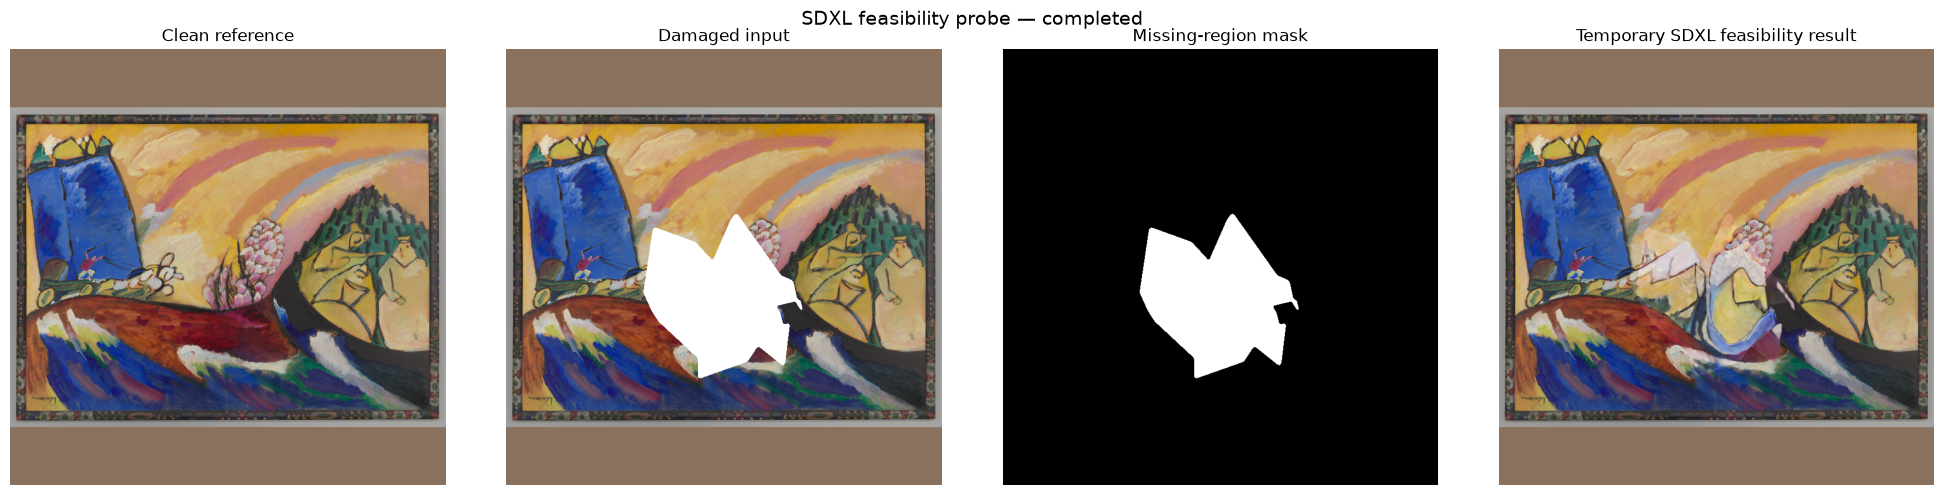

Temporary probe image: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\12_sdxl_feasibility_or_restoration\work\attempts\sdxl_probe__a80c364f5333.png
Temporary probe geometry: (768, 768)
Projection basis: completed_wall_clock_extrapolation
Post-execution schema passed: True


In [14]:
# ---------------------------------------------------------------------------
# Runtime projection with censored-timeout handling
# ---------------------------------------------------------------------------

resolved_status = str(
    resolved_attempt["status"]
)

resolved_failure_type = str(
    resolved_attempt["failure_type"]
)

if resolved_status == "timed_out":
    projection_basis = (
        "censored_lower_bound_at_timeout"
    )

    projection_runtime_seconds = float(
        resolved_attempt["timeout_seconds"]
    )

    feasibility_attempts_df.loc[
        feasibility_attempts_df.index[0],
        "projected_primary_hours",
    ] = round(
        projection_runtime_seconds
        * configured_scope[
            "eligible_primary_case_count"
        ]
        / 3600,
        3,
    )

    feasibility_attempts_df.loc[
        feasibility_attempts_df.index[0],
        "projected_comparable_hours",
    ] = round(
        projection_runtime_seconds
        * configured_scope[
            "comparable_candidate_count"
        ]
        / 3600,
        3,
    )

    existing_issue = str(
        feasibility_attempts_df.loc[
            feasibility_attempts_df.index[0],
            "issue",
        ]
        or ""
    ).strip()

    lower_bound_issue = (
        "Runtime projections are censored lower bounds "
        "based on the 1500-second guardrail."
    )

    feasibility_attempts_df.loc[
        feasibility_attempts_df.index[0],
        "issue",
    ] = (
        f"{existing_issue}; {lower_bound_issue}"
        if existing_issue
        else lower_bound_issue
    )

elif resolved_status == "completed":
    projection_basis = (
        "completed_wall_clock_extrapolation"
    )

else:
    projection_basis = (
        "not_available_for_this_failure"
    )

resolved_attempt = (
    feasibility_attempts_df.iloc[0]
)

post_execution_schema_validation = (
    validate_dataframe(
        feasibility_attempts_df,
        SDXL_FEASIBILITY_ATTEMPTS_SCHEMA,
    )
)


# ---------------------------------------------------------------------------
# Compact attempt and projection summaries
# ---------------------------------------------------------------------------

attempt_outcome_columns = [
    "attempt_id",
    "case_id",
    "hf_model_id",
    "model_revision",
    "status",
    "failure_type",
    "availability_state",
    "model_load_succeeded",
    "inference_started",
    "inference_completed",
    "timed_out",
    "output_generated",
    "output_geometry_valid",
    "outside_mask_changed_pixels",
    "technical_validation_passed",
    "model_load_seconds",
    "inference_seconds",
    "runtime_seconds",
    "gpu_peak_memory_bytes",
    "worker_return_code",
    "error_type",
    "error_message",
    "issue",
]

attempt_outcome_summary_df = (
    feasibility_attempts_df[
        attempt_outcome_columns
    ]
    .copy()
)

runtime_projection_summary_df = pd.DataFrame(
    [
        {
            "projection_scope": (
                "eligible_primary_cases"
            ),
            "item_count": configured_scope[
                "eligible_primary_case_count"
            ],
            "projection_basis": projection_basis,
            "projected_hours": (
                resolved_attempt[
                    "projected_primary_hours"
                ]
            ),
        },
        {
            "projection_scope": (
                "comparable_candidates"
            ),
            "item_count": configured_scope[
                "comparable_candidate_count"
            ],
            "projection_basis": projection_basis,
            "projected_hours": (
                resolved_attempt[
                    "projected_comparable_hours"
                ]
            ),
        },
    ]
)

display(attempt_outcome_summary_df)
display(runtime_projection_summary_df)


# ---------------------------------------------------------------------------
# Display the temporary result only when one exists
# ---------------------------------------------------------------------------

temporary_probe_exists = (
    worker_output_path.is_file()
)

if (
    bool(resolved_attempt["output_generated"])
    and temporary_probe_exists
):
    with Image.open(
        worker_output_path
    ) as image:
        selected_restored_image = (
            image.convert("RGB").copy()
        )

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(20, 5),
    )

    axes[0].imshow(selected_clean_image)
    axes[0].set_title("Clean reference")

    axes[1].imshow(selected_input_image)
    axes[1].set_title("Damaged input")

    axes[2].imshow(
        selected_mask_image,
        cmap="gray",
        vmin=0,
        vmax=255,
    )
    axes[2].set_title("Missing-region mask")

    axes[3].imshow(selected_restored_image)
    axes[3].set_title(
        "Temporary SDXL feasibility result"
    )

    for axis in axes:
        axis.axis("off")

    fig.suptitle(
        "SDXL feasibility probe — "
        f"{resolved_attempt['status']}",
        fontsize=14,
    )

    plt.tight_layout()
    plt.show()

    print(
        "Temporary probe image:",
        worker_output_path,
    )
    print(
        "Temporary probe geometry:",
        selected_restored_image.size,
    )
else:
    print(
        "No temporary restoration was produced. "
        "This is expected for a timeout, CUDA OOM, "
        "or model-unavailable outcome."
    )

print(
    "Projection basis:",
    projection_basis,
)
print(
    "Post-execution schema passed:",
    post_execution_schema_validation.passed,
)

In [15]:
# ---------------------------------------------------------------------------
# Batch 4 validation
# ---------------------------------------------------------------------------


def add_batch_4_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage="batch_4_guarded_execution",
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


resolved_attempt = (
    feasibility_attempts_df.iloc[0]
)

resolved_outcome_tuple = (
    str(resolved_attempt["status"]),
    str(resolved_attempt["failure_type"]),
    str(resolved_attempt["availability_state"]),
)

allowed_resolved_outcomes = {
    (
        "completed",
        "none",
        "feasibility_only",
    ),
    (
        "timed_out",
        "runtime_guardrail",
        "feasibility_only",
    ),
    (
        "failed",
        "cuda_out_of_memory",
        "feasibility_only",
    ),
    (
        "failed",
        "model_unavailable",
        "unavailable",
    ),
}


# Normalized result contract
add_batch_4_check(
    check_id="resolved_attempt_schema",
    description=(
        "The resolved attempt satisfies the normalized "
        "SDXL feasibility schema."
    ),
    expected=True,
    observed=(
        post_execution_schema_validation.passed
    ),
    passed=(
        post_execution_schema_validation.passed
    ),
    details=(
        post_execution_schema_validation.to_dict()
    ),
)

add_batch_4_check(
    check_id="single_attempt_resolved",
    description=(
        "Exactly one attempt was resolved and no planned "
        "row remains."
    ),
    expected={
        "row_count": 1,
        "planned_count": 0,
    },
    observed={
        "row_count": len(
            feasibility_attempts_df
        ),
        "planned_count": int(
            feasibility_attempts_df[
                "status"
            ].eq("planned").sum()
        ),
    },
    passed=(
        len(feasibility_attempts_df) == 1
        and not feasibility_attempts_df[
            "status"
        ].eq("planned").any()
    ),
)

add_batch_4_check(
    check_id="classified_execution_outcome",
    description=(
        "The attempt resolved to an approved completed, "
        "hardware-limited, or unavailable outcome."
    ),
    expected=sorted(
        "|".join(outcome)
        for outcome in allowed_resolved_outcomes
    ),
    observed="|".join(
        resolved_outcome_tuple
    ),
    passed=(
        resolved_outcome_tuple
        in allowed_resolved_outcomes
    ),
    details={
        "error_type": str(
            resolved_attempt["error_type"]
        ),
        "error_message": str(
            resolved_attempt["error_message"]
        ),
        "issue": str(
            resolved_attempt["issue"]
        ),
    },
)

add_batch_4_check(
    check_id="worker_return_recorded",
    description=(
        "The isolated worker has an explicit process "
        "return code and runtime."
    ),
    expected=True,
    observed={
        "worker_return_code": (
            resolved_attempt[
                "worker_return_code"
            ]
        ),
        "runtime_seconds": (
            resolved_attempt[
                "runtime_seconds"
            ]
        ),
    },
    passed=(
        not pd.isna(
            resolved_attempt[
                "worker_return_code"
            ]
        )
        and not pd.isna(
            resolved_attempt[
                "runtime_seconds"
            ]
        )
        and float(
            resolved_attempt[
                "runtime_seconds"
            ]
        ) > 0
    ),
)


# Outcome-specific technical contract
if resolved_status == "completed":
    outcome_technical_contract_passed = bool(
        resolved_attempt[
            "model_load_succeeded"
        ]
        and resolved_attempt[
            "inference_started"
        ]
        and resolved_attempt[
            "inference_completed"
        ]
        and not resolved_attempt[
            "timed_out"
        ]
        and resolved_attempt[
            "output_generated"
        ]
        and resolved_attempt[
            "output_geometry_valid"
        ]
        and resolved_attempt[
            "technical_validation_passed"
        ]
        and int(
            resolved_attempt[
                "outside_mask_changed_pixels"
            ]
        ) == 0
        and worker_output_path.is_file()
    )

elif resolved_status == "timed_out":
    timeout_runtime = float(
        resolved_attempt[
            "runtime_seconds"
        ]
    )

    configured_timeout = float(
        resolved_attempt[
            "timeout_seconds"
        ]
    )

    outcome_technical_contract_passed = bool(
        resolved_attempt["timed_out"]
        and resolved_failure_type
        == "runtime_guardrail"
        and timeout_runtime
        >= configured_timeout - 5
        and timeout_runtime
        <= configured_timeout + 30
    )

elif resolved_failure_type in {
    "cuda_out_of_memory",
    "model_unavailable",
}:
    outcome_technical_contract_passed = bool(
        not resolved_attempt[
            "inference_completed"
        ]
        and not resolved_attempt[
            "technical_validation_passed"
        ]
    )

else:
    outcome_technical_contract_passed = False

add_batch_4_check(
    check_id="outcome_technical_contract",
    description=(
        "The technical evidence is internally consistent "
        "with the classified execution outcome."
    ),
    expected=True,
    observed=outcome_technical_contract_passed,
    passed=outcome_technical_contract_passed,
)


# Timeout projection lower bounds
if resolved_status == "timed_out":
    timeout_projection_contract_passed = bool(
        projection_basis
        == "censored_lower_bound_at_timeout"
        and float(
            resolved_attempt[
                "projected_primary_hours"
            ]
        ) > 170
        and float(
            resolved_attempt[
                "projected_comparable_hours"
            ]
        ) > 420
    )
else:
    timeout_projection_contract_passed = True

add_batch_4_check(
    check_id="timeout_projection_interpretation",
    description=(
        "A timed-out attempt records project-scale "
        "runtime values as censored lower bounds."
    ),
    expected=True,
    observed={
        "projection_basis": projection_basis,
        "primary_hours": (
            resolved_attempt[
                "projected_primary_hours"
            ]
        ),
        "comparable_hours": (
            resolved_attempt[
                "projected_comparable_hours"
            ]
        ),
    },
    passed=timeout_projection_contract_passed,
)


# No retry or fallback
add_batch_4_check(
    check_id="no_retry_or_fallback",
    description=(
        "The notebook resolved one attempt without retry, "
        "CPU fallback, reduced steps, or reduced resolution."
    ),
    expected={
        "attempt_rows": 1,
        "retry_enabled": False,
        "cpu_fallback": False,
        "steps": 30,
        "resolution": [768, 768],
    },
    observed={
        "attempt_rows": len(
            feasibility_attempts_df
        ),
        "retry_enabled": configured_execution[
            "retry_failed_attempts"
        ],
        "cpu_fallback": configured_model[
            "allow_cpu_fallback"
        ],
        "steps": resolved_attempt[
            "num_inference_steps"
        ],
        "resolution": [
            resolved_attempt[
                "inference_width"
            ],
            resolved_attempt[
                "inference_height"
            ],
        ],
    },
    passed=(
        len(feasibility_attempts_df) == 1
        and not configured_execution[
            "retry_failed_attempts"
        ]
        and not configured_model[
            "allow_cpu_fallback"
        ]
        and resolved_attempt[
            "num_inference_steps"
        ] == 30
        and resolved_attempt[
            "inference_width"
        ] == 768
        and resolved_attempt[
            "inference_height"
        ] == 768
    ),
)


# Worker-owned files only
existing_work_files = sorted(
    path
    for path in OUTPUTS[
        "attempt_work_directory"
    ].rglob("*")
    if path.is_file()
) if OUTPUTS[
    "attempt_work_directory"
].is_dir() else []

approved_worker_filenames = {
    path.name
    for path in WORKER_OWNED_PATHS
}

unexpected_work_files = [
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in existing_work_files
    if path.name
    not in approved_worker_filenames
]

add_batch_4_check(
    check_id="temporary_worker_file_scope",
    description=(
        "Every retained execution file is an explicitly "
        "owned temporary worker artifact."
    ),
    expected=[],
    observed=unexpected_work_files,
    passed=not unexpected_work_files,
    details=[
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path in existing_work_files
    ],
)


# No canonical outputs yet
canonical_output_paths = [
    OUTPUTS["feasibility_attempts"],
    OUTPUTS["feasibility_report"],
    OUTPUTS["run_manifest"],
    OUTPUTS["artifact_manifest"],
    OUTPUTS["validation_checks"],
]

premature_canonical_outputs = [
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in canonical_output_paths
    if path.exists()
]

add_batch_4_check(
    check_id="no_premature_canonical_outputs",
    description=(
        "The execution batch retained only work files; "
        "canonical outputs have not yet been persisted."
    ),
    expected=[],
    observed=premature_canonical_outputs,
    passed=not premature_canonical_outputs,
)


# ---------------------------------------------------------------------------
# Render and enforce the Batch 4 gate
# ---------------------------------------------------------------------------

BATCH_4_VALIDATION_DF = VALIDATION.to_dataframe()

BATCH_4_ONLY_VALIDATION_DF = (
    BATCH_4_VALIDATION_DF.loc[
        BATCH_4_VALIDATION_DF[
            "validation_stage"
        ].eq("batch_4_guarded_execution")
    ]
    .reset_index(drop=True)
)

BATCH_4_VALIDATION_SUMMARY = VALIDATION.summary()

display(attempt_outcome_summary_df)
display(runtime_projection_summary_df)
display(BATCH_4_ONLY_VALIDATION_DF)

print("Batch 4 cumulative validation summary:")
print(
    json.dumps(
        BATCH_4_VALIDATION_SUMMARY,
        indent=2,
    )
)

VALIDATION.raise_for_blocking()

print(
    "Batch 4 passed. The isolated SDXL attempt resolved "
    f"as {resolved_status}/{resolved_failure_type} with "
    f"availability state {SDXL_AVAILABILITY_STATE}. "
    "Hardware limitations are retained as feasibility "
    "evidence rather than model-quality conclusions."
)

,attempt_id,case_id,hf_model_id,model_revision,status,failure_type,availability_state,model_load_succeeded,inference_started,inference_completed,...,outside_mask_changed_pixels,technical_validation_passed,model_load_seconds,inference_seconds,runtime_seconds,gpu_peak_memory_bytes,worker_return_code,error_type,error_message,issue
0,sdxl_probe__a80c364f5333,canonical__p039__loss_large,diffusers/stable-diffusion-xl-1.0-inpainting-0.1,115134f363124c53c7d878647567d04daf26e41e,completed,none,feasibility_only,True,True,True,...,0,True,2.801,625.626,694.081,5632166912,0,,,


,projection_scope,item_count,projection_basis,projected_hours
0,eligible_primary_cases,410,completed_wall_clock_extrapolation,79.048
1,comparable_candidates,1010,completed_wall_clock_extrapolation,194.728


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_4_guarded_execution,resolved_attempt_schema,The resolved attempt satisfies the normalized ...,blocking,True,True,True,"{""column_count"": 63, ""duplicate_primary_key_ro..."
1,batch_4_guarded_execution,single_attempt_resolved,Exactly one attempt was resolved and no planne...,blocking,"{""planned_count"": 0, ""row_count"": 1}","{""planned_count"": 0, ""row_count"": 1}",True,
2,batch_4_guarded_execution,classified_execution_outcome,"The attempt resolved to an approved completed,...",blocking,"[""completed|none|feasibility_only"", ""failed|cu...",completed|none|feasibility_only,True,"{""error_message"": """", ""error_type"": """", ""issue..."
3,batch_4_guarded_execution,worker_return_recorded,The isolated worker has an explicit process re...,blocking,True,"{""runtime_seconds"": 694.081, ""worker_return_co...",True,
4,batch_4_guarded_execution,outcome_technical_contract,The technical evidence is internally consisten...,blocking,True,True,True,
5,batch_4_guarded_execution,timeout_projection_interpretation,A timed-out attempt records project-scale runt...,blocking,True,"{""comparable_hours"": 194.728, ""primary_hours"":...",True,
6,batch_4_guarded_execution,no_retry_or_fallback,The notebook resolved one attempt without retr...,blocking,"{""attempt_rows"": 1, ""cpu_fallback"": false, ""re...","{""attempt_rows"": 1, ""cpu_fallback"": false, ""re...",True,
7,batch_4_guarded_execution,temporary_worker_file_scope,Every retained execution file is an explicitly...,blocking,[],[],True,"[""outputs/12_sdxl_feasibility_or_restoration/w..."
8,batch_4_guarded_execution,no_premature_canonical_outputs,The execution batch retained only work files; ...,blocking,[],[],True,


Batch 4 cumulative validation summary:
{
  "check_count": 68,
  "passed_count": 68,
  "failed_count": 0,
  "blocking_failure_count": 0,
  "overall_passed": true,
  "failed_check_ids": []
}
Batch 4 passed. The isolated SDXL attempt resolved as completed/none with availability state feasibility_only. Hardware limitations are retained as feasibility evidence rather than model-quality conclusions.


## Batch 5 - Technical, Visual, and Availability Audit

This batch interprets the completed SDXL feasibility probe without turning one restoration into a model-quality benchmark.

It:

- reloads the temporary worker output;
- uses the canonical region helper for masked, boundary, and bounding-box regions;
- independently verifies geometry, checksums, mask support, outside-mask preservation, and generated-region variation;
- reconciles the parent attempt record with the worker job and worker result contracts;
- renders full-image and masked-region crop comparisons;
- records a bounded qualitative review;
- separates technical executability from reference fidelity;
- derives the final `feasibility_only` availability decision;
- explicitly excludes SDXL from downstream unified metrics under the current run;
- records compute recommendations for any future full SDXL evaluation.

No canonical metric rows are created. The visual observations apply only to this one predeclared feasibility case.

In [16]:
from restoration_eval.regions import (
    REGIONS_MODULE_VERSION,
    boundary_region,
    crop_array,
    mask_bbox_region,
    masked_region,
    select_pixels,
)


# ---------------------------------------------------------------------------
# Reload worker-owned evidence
# ---------------------------------------------------------------------------

with worker_job_path.open(
    "r",
    encoding="utf-8-sig",
) as handle:
    persisted_worker_job = json.load(handle)

with worker_result_path.open(
    "r",
    encoding="utf-8-sig",
) as handle:
    persisted_worker_result = json.load(handle)

with Image.open(worker_output_path) as image:
    reloaded_restored_image = (
        image.convert("RGB").copy()
    )

clean_array = np.asarray(
    selected_clean_image,
    dtype=np.uint8,
)

damaged_array = np.asarray(
    selected_input_image,
    dtype=np.uint8,
)

mask_array = np.asarray(
    selected_mask_image,
    dtype=np.uint8,
)

restored_array = np.asarray(
    reloaded_restored_image,
    dtype=np.uint8,
)

binary_mask_array = (
    mask_array
    >= configured_model["mask_threshold"]
)

outside_mask_array = ~binary_mask_array


# ---------------------------------------------------------------------------
# Canonical technical regions
# ---------------------------------------------------------------------------

canonical_masked_region = masked_region(
    binary_mask_array
)

canonical_boundary_region = boundary_region(
    binary_mask_array,
    width_pixels=3,
    mode="both",
)

canonical_bbox_region = mask_bbox_region(
    binary_mask_array,
    margin=24,
)

masked_damaged_pixels = select_pixels(
    damaged_array,
    canonical_masked_region,
)

masked_restored_pixels = select_pixels(
    restored_array,
    canonical_masked_region,
)

outside_changed_map = np.any(
    restored_array != damaged_array,
    axis=2,
) & outside_mask_array

inside_changed_map = np.any(
    restored_array != damaged_array,
    axis=2,
) & binary_mask_array

masked_pixel_count = int(
    canonical_masked_region.pixel_count
)

boundary_pixel_count = int(
    canonical_boundary_region.pixel_count
)

outside_changed_pixels = int(
    outside_changed_map.sum()
)

inside_changed_pixels = int(
    inside_changed_map.sum()
)

inside_changed_fraction = float(
    inside_changed_pixels
    / masked_pixel_count
)

restored_nonwhite_fraction = float(
    np.any(
        masked_restored_pixels < 250,
        axis=1,
    ).mean()
)

restored_inside_channel_std = float(
    masked_restored_pixels
    .astype(np.float64)
    .std(axis=0)
    .mean()
)

restored_sha256 = sha256_file(
    worker_output_path
)

gpu_peak_memory_fraction = float(
    resolved_attempt[
        "gpu_peak_memory_bytes"
    ]
    / resolved_attempt[
        "gpu_total_memory_bytes"
    ]
)

parent_runtime_seconds = float(
    resolved_attempt["runtime_seconds"]
)

worker_measured_seconds = float(
    resolved_attempt["model_load_seconds"]
    + resolved_attempt["inference_seconds"]
)

parent_and_process_overhead_seconds = float(
    parent_runtime_seconds
    - worker_measured_seconds
)


# ---------------------------------------------------------------------------
# Independent technical audit
# ---------------------------------------------------------------------------

technical_audit_df = pd.DataFrame(
    [
        {
            "check": "output_geometry",
            "observed": (
                f"{restored_array.shape[1]}x"
                f"{restored_array.shape[0]} "
                f"{reloaded_restored_image.mode}"
            ),
            "expected": "768x768 RGB",
            "passed": (
                restored_array.shape
                == (768, 768, 3)
                and reloaded_restored_image.mode
                == "RGB"
            ),
        },
        {
            "check": "mask_pixel_count",
            "observed": masked_pixel_count,
            "expected": int(
                binary_mask_array.sum()
            ),
            "passed": (
                masked_pixel_count
                == int(binary_mask_array.sum())
                and masked_pixel_count > 0
            ),
        },
        {
            "check": "outside_mask_changed_pixels",
            "observed": outside_changed_pixels,
            "expected": 0,
            "passed": (
                outside_changed_pixels == 0
            ),
        },
        {
            "check": "inside_mask_changed_fraction",
            "observed": round(
                inside_changed_fraction,
                6,
            ),
            "expected": "greater_than_0",
            "passed": (
                inside_changed_fraction > 0
            ),
        },
        {
            "check": "inside_mask_nonwhite_fraction",
            "observed": round(
                restored_nonwhite_fraction,
                6,
            ),
            "expected": "greater_than_0",
            "passed": (
                restored_nonwhite_fraction > 0
            ),
        },
        {
            "check": "inside_mask_channel_variation",
            "observed": round(
                restored_inside_channel_std,
                6,
            ),
            "expected": "greater_than_0",
            "passed": (
                restored_inside_channel_std > 0
            ),
        },
        {
            "check": "worker_output_checksum",
            "observed": restored_sha256,
            "expected": (
                "64-character SHA-256"
            ),
            "passed": bool(
                len(restored_sha256) == 64
            ),
        },
    ]
)


# ---------------------------------------------------------------------------
# Parent/worker contract reconciliation
# ---------------------------------------------------------------------------

worker_evidence_consistency_df = pd.DataFrame(
    [
        {
            "field": "attempt_id",
            "parent_value": str(
                resolved_attempt["attempt_id"]
            ),
            "worker_value": str(
                persisted_worker_result[
                    "attempt_id"
                ]
            ),
            "matches": (
                str(
                    resolved_attempt["attempt_id"]
                )
                == str(
                    persisted_worker_result[
                        "attempt_id"
                    ]
                )
            ),
        },
        {
            "field": "status",
            "parent_value": str(
                resolved_attempt["status"]
            ),
            "worker_value": str(
                persisted_worker_result["status"]
            ),
            "matches": (
                str(resolved_attempt["status"])
                == str(
                    persisted_worker_result[
                        "status"
                    ]
                )
            ),
        },
        {
            "field": "failure_type",
            "parent_value": str(
                resolved_attempt[
                    "failure_type"
                ]
            ),
            "worker_value": str(
                persisted_worker_result[
                    "failure_type"
                ]
            ),
            "matches": (
                str(
                    resolved_attempt[
                        "failure_type"
                    ]
                )
                == str(
                    persisted_worker_result[
                        "failure_type"
                    ]
                )
            ),
        },
        {
            "field": "model_load_succeeded",
            "parent_value": bool(
                resolved_attempt[
                    "model_load_succeeded"
                ]
            ),
            "worker_value": bool(
                persisted_worker_result[
                    "model_load_succeeded"
                ]
            ),
            "matches": (
                bool(
                    resolved_attempt[
                        "model_load_succeeded"
                    ]
                )
                == bool(
                    persisted_worker_result[
                        "model_load_succeeded"
                    ]
                )
            ),
        },
        {
            "field": "inference_completed",
            "parent_value": bool(
                resolved_attempt[
                    "inference_completed"
                ]
            ),
            "worker_value": bool(
                persisted_worker_result[
                    "inference_completed"
                ]
            ),
            "matches": (
                bool(
                    resolved_attempt[
                        "inference_completed"
                    ]
                )
                == bool(
                    persisted_worker_result[
                        "inference_completed"
                    ]
                )
            ),
        },
        {
            "field": "technical_validation_passed",
            "parent_value": bool(
                resolved_attempt[
                    "technical_validation_passed"
                ]
            ),
            "worker_value": bool(
                persisted_worker_result[
                    "technical_validation_passed"
                ]
            ),
            "matches": (
                bool(
                    resolved_attempt[
                        "technical_validation_passed"
                    ]
                )
                == bool(
                    persisted_worker_result[
                        "technical_validation_passed"
                    ]
                )
            ),
        },
        {
            "field": "outside_mask_changed_pixels",
            "parent_value": int(
                resolved_attempt[
                    "outside_mask_changed_pixels"
                ]
            ),
            "worker_value": int(
                persisted_worker_result[
                    "outside_mask_changed_pixels"
                ]
            ),
            "matches": (
                int(
                    resolved_attempt[
                        "outside_mask_changed_pixels"
                    ]
                )
                == int(
                    persisted_worker_result[
                        "outside_mask_changed_pixels"
                    ]
                )
                == outside_changed_pixels
            ),
        },
    ]
)

runtime_breakdown_df = pd.DataFrame(
    [
        {
            "runtime_component": "model_load",
            "seconds": float(
                resolved_attempt[
                    "model_load_seconds"
                ]
            ),
        },
        {
            "runtime_component": "inference",
            "seconds": float(
                resolved_attempt[
                    "inference_seconds"
                ]
            ),
        },
        {
            "runtime_component": (
                "process_and_validation_overhead"
            ),
            "seconds": (
                parent_and_process_overhead_seconds
            ),
        },
        {
            "runtime_component": (
                "parent_wall_clock_total"
            ),
            "seconds": parent_runtime_seconds,
        },
    ]
)

display(technical_audit_df)
display(worker_evidence_consistency_df)
display(runtime_breakdown_df)

print(
    "Canonical regions helper:",
    REGIONS_MODULE_VERSION,
)
print("Masked pixels:", masked_pixel_count)
print("Boundary pixels:", boundary_pixel_count)
print(
    "Outside-mask changed pixels:",
    outside_changed_pixels,
)
print(
    "Inside-mask changed fraction:",
    round(inside_changed_fraction, 6),
)
print(
    "Peak allocated GPU-memory fraction:",
    round(gpu_peak_memory_fraction, 4),
)
print("Restored SHA-256:", restored_sha256)

,check,observed,expected,passed
0,output_geometry,768x768 RGB,768x768 RGB,True
1,mask_pixel_count,49001,49001,True
2,outside_mask_changed_pixels,0,0,True
3,inside_mask_changed_fraction,1.0,greater_than_0,True
4,inside_mask_nonwhite_fraction,1.0,greater_than_0,True
5,inside_mask_channel_variation,50.937911,greater_than_0,True
6,worker_output_checksum,1f94c2292693a96638ddfeabfc1272a8b075958460af1a...,64-character SHA-256,True


,field,parent_value,worker_value,matches
0,attempt_id,sdxl_probe__a80c364f5333,sdxl_probe__a80c364f5333,True
1,status,completed,completed,True
2,failure_type,none,none,True
3,model_load_succeeded,True,True,True
4,inference_completed,True,True,True
5,technical_validation_passed,True,True,True
6,outside_mask_changed_pixels,0,0,True


,runtime_component,seconds
0,model_load,2.801
1,inference,625.626
2,process_and_validation_overhead,65.654
3,parent_wall_clock_total,694.081


Canonical regions helper: 1.1.0
Masked pixels: 49001
Boundary pixels: 6102
Outside-mask changed pixels: 0
Inside-mask changed fraction: 1.0
Peak allocated GPU-memory fraction: 0.8743
Restored SHA-256: 1f94c2292693a96638ddfeabfc1272a8b075958460af1a18c9b36188b713187f


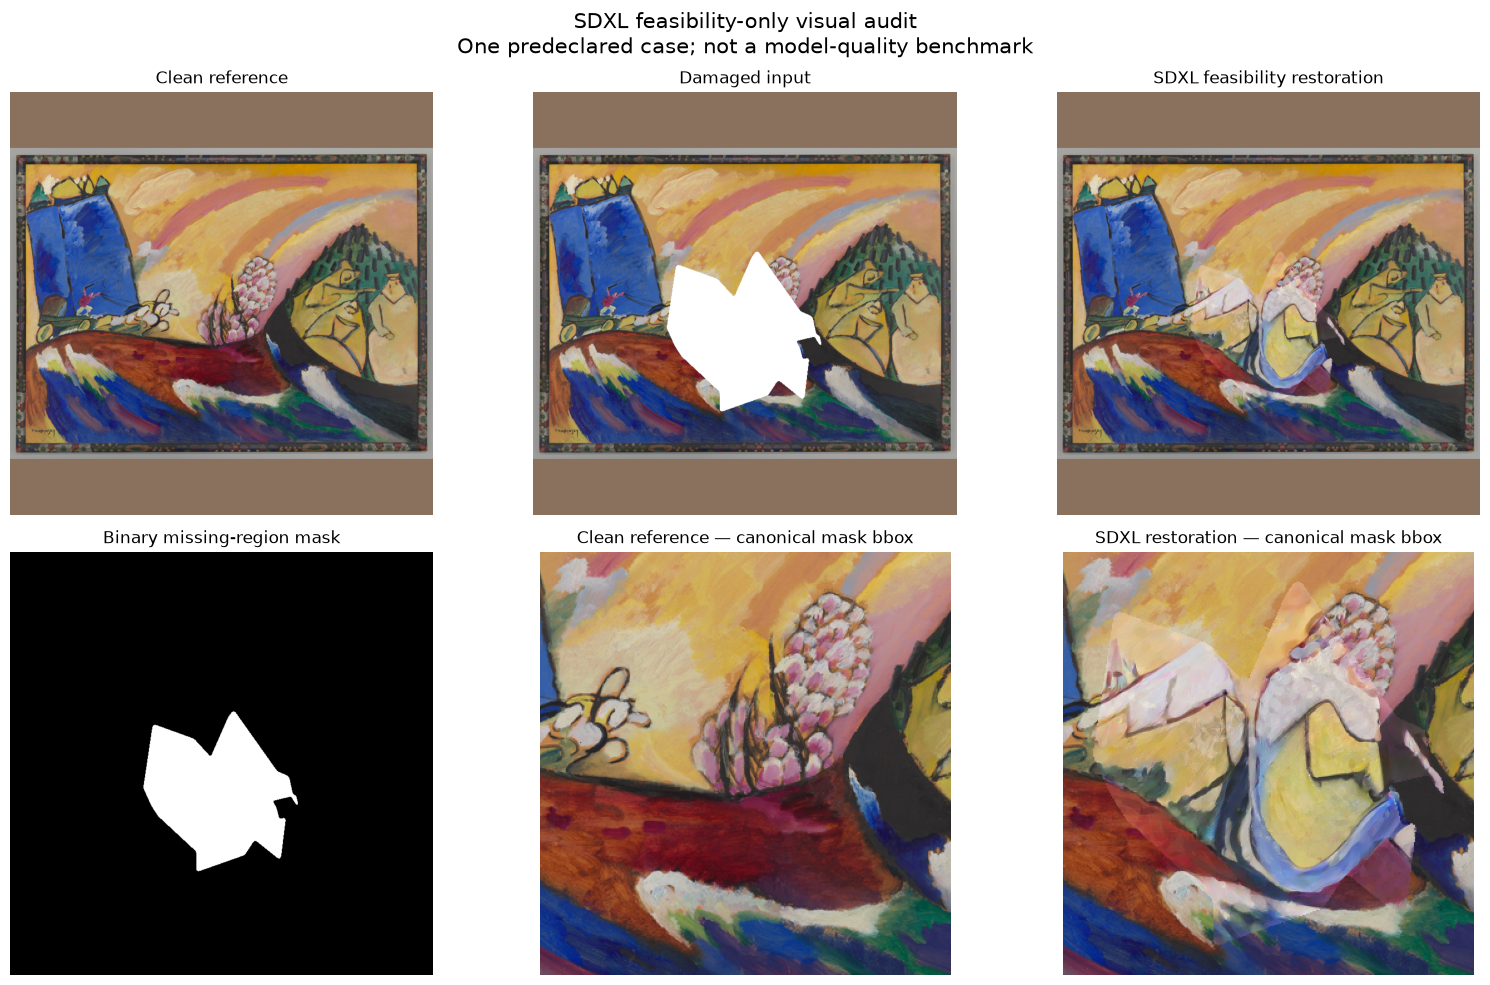

,review_id,evidence_type,observed,interpretation,scope,quality_claim_allowed
0,masked_region_filled,technical_visual,True,The white missing region was replaced with non...,single_predeclared_case,False
1,outside_mask_preserved,technical,True,Every pixel outside the approved mask matches ...,single_predeclared_case,False
2,clean_content_not_reconstructed,qualitative_visual,True,The generated pale geometric forms do not reco...,single_predeclared_case,False
3,local_discontinuity_visible,qualitative_visual,True,Some local shape and tonal transitions around ...,single_predeclared_case,False
4,historical_correctness_unknown,methodological,True,Visual plausibility cannot establish historica...,universal_limitation,False


Visual review rows: 5
Rows authorizing a quality claim: 0
The visual audit confirms technical execution, not SDXL restoration fidelity.


In [17]:
# ---------------------------------------------------------------------------
# Canonical bounding-box crops
# ---------------------------------------------------------------------------

clean_bbox_crop = crop_array(
    clean_array,
    canonical_bbox_region,
)

damaged_bbox_crop = crop_array(
    damaged_array,
    canonical_bbox_region,
)

restored_bbox_crop = crop_array(
    restored_array,
    canonical_bbox_region,
)


# ---------------------------------------------------------------------------
# Full-image and local-region visual audit
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 10),
)

axes[0, 0].imshow(clean_array)
axes[0, 0].set_title("Clean reference")

axes[0, 1].imshow(damaged_array)
axes[0, 1].set_title("Damaged input")

axes[0, 2].imshow(restored_array)
axes[0, 2].set_title("SDXL feasibility restoration")

axes[1, 0].imshow(
    binary_mask_array,
    cmap="gray",
    vmin=0,
    vmax=1,
)
axes[1, 0].set_title(
    "Binary missing-region mask"
)

axes[1, 1].imshow(clean_bbox_crop)
axes[1, 1].set_title(
    "Clean reference — canonical mask bbox"
)

axes[1, 2].imshow(restored_bbox_crop)
axes[1, 2].set_title(
    "SDXL restoration — canonical mask bbox"
)

for axis in axes.flat:
    axis.axis("off")

fig.suptitle(
    "SDXL feasibility-only visual audit\n"
    "One predeclared case; not a model-quality benchmark",
    fontsize=15,
)

plt.tight_layout()
plt.show()


# ---------------------------------------------------------------------------
# Bounded qualitative review
# ---------------------------------------------------------------------------

visual_review_df = pd.DataFrame(
    [
        {
            "review_id": (
                "masked_region_filled"
            ),
            "evidence_type": "technical_visual",
            "observed": True,
            "interpretation": (
                "The white missing region was replaced "
                "with nonconstant generated content."
            ),
            "scope": "single_predeclared_case",
            "quality_claim_allowed": False,
        },
        {
            "review_id": (
                "outside_mask_preserved"
            ),
            "evidence_type": "technical",
            "observed": True,
            "interpretation": (
                "Every pixel outside the approved mask "
                "matches the damaged input exactly."
            ),
            "scope": "single_predeclared_case",
            "quality_claim_allowed": False,
        },
        {
            "review_id": (
                "clean_content_not_reconstructed"
            ),
            "evidence_type": "qualitative_visual",
            "observed": True,
            "interpretation": (
                "The generated pale geometric forms do "
                "not reconstruct the clean reference's "
                "flower and internal structures."
            ),
            "scope": "single_predeclared_case",
            "quality_claim_allowed": False,
        },
        {
            "review_id": (
                "local_discontinuity_visible"
            ),
            "evidence_type": "qualitative_visual",
            "observed": True,
            "interpretation": (
                "Some local shape and tonal transitions "
                "around the reconstructed content remain "
                "visually apparent."
            ),
            "scope": "single_predeclared_case",
            "quality_claim_allowed": False,
        },
        {
            "review_id": (
                "historical_correctness_unknown"
            ),
            "evidence_type": "methodological",
            "observed": True,
            "interpretation": (
                "Visual plausibility cannot establish "
                "historical correctness, artist intent, "
                "or conservation suitability."
            ),
            "scope": "universal_limitation",
            "quality_claim_allowed": False,
        },
    ]
)

display(visual_review_df)

print(
    "Visual review rows:",
    len(visual_review_df),
)
print(
    "Rows authorizing a quality claim:",
    int(
        visual_review_df[
            "quality_claim_allowed"
        ].sum()
    ),
)
print(
    "The visual audit confirms technical execution, "
    "not SDXL restoration fidelity."
)

In [18]:
# ---------------------------------------------------------------------------
# Final availability decision
# ---------------------------------------------------------------------------

availability_decision_df = pd.DataFrame(
    [
        {
            "model_id": configured_model[
                "model_id"
            ],
            "availability_state": (
                SDXL_AVAILABILITY_STATE
            ),
            "probe_status": resolved_status,
            "probe_failure_type": (
                resolved_failure_type
            ),
            "probe_count": len(
                feasibility_attempts_df
            ),
            "technical_probe_passed": bool(
                resolved_attempt[
                    "technical_validation_passed"
                ]
            ),
            "runtime_seconds": float(
                resolved_attempt[
                    "runtime_seconds"
                ]
            ),
            "projected_primary_hours": float(
                resolved_attempt[
                    "projected_primary_hours"
                ]
            ),
            "projected_comparable_hours": float(
                resolved_attempt[
                    "projected_comparable_hours"
                ]
            ),
            "full_execution_authorized": bool(
                configured_scope[
                    "full_execution_authorized"
                ]
            ),
            "include_in_unified_metrics": False,
            "decision_reason": (
                "The pinned SDXL implementation is "
                "technically executable on the available "
                "6 GB GPU, but one probe cannot establish "
                "model quality and the projected 410-case "
                "and 1,010-candidate runtimes remain "
                "impractical for the current local study."
            ),
            "quality_interpretation": (
                "The single result visibly differs from "
                "the clean reference and cannot support "
                "fidelity or conservation claims."
            ),
        }
    ]
)

downstream_availability_df = pd.DataFrame(
    [
        {
            "downstream_scope": "notebooks_13_to_21",
            "sdxl_available": False,
            "required_state": (
                "full_evaluation_complete or explicitly "
                "supported partial_evaluation"
            ),
            "observed_state": (
                SDXL_AVAILABILITY_STATE
            ),
            "required_action": (
                "Exclude SDXL from unified metric tables; "
                "create no placeholder rows."
            ),
        },
        {
            "downstream_scope": "notebooks_22_to_35",
            "sdxl_available": False,
            "required_state": (
                "validated downstream-compatible "
                "candidate evidence"
            ),
            "observed_state": (
                SDXL_AVAILABILITY_STATE
            ),
            "required_action": (
                "Report SDXL as feasibility-only and "
                "retain explicit missing-method handling."
            ),
        },
    ]
)

future_compute_recommendation_df = pd.DataFrame(
    [
        {
            "execution_context": (
                "current_local_hardware"
            ),
            "recommendation": (
                "Retain feasibility_only; do not execute "
                "the complete 410/1010 design."
            ),
            "minimum_gpu_memory_gib": None,
            "preferred_gpu_memory_gib": None,
        },
        {
            "execution_context": (
                "future_full_sdxl_evaluation"
            ),
            "recommendation": (
                "Use dedicated higher-memory compute and "
                "rerun the normalized full candidate "
                "contract before enabling downstream metrics."
            ),
            "minimum_gpu_memory_gib": 12,
            "preferred_gpu_memory_gib": 16,
        },
    ]
)

display(availability_decision_df)
display(downstream_availability_df)
display(future_compute_recommendation_df)

print(
    "Validated SDXL availability state:",
    SDXL_AVAILABILITY_STATE,
)
print(
    "Include SDXL in unified metrics:",
    bool(
        availability_decision_df.loc[
            0,
            "include_in_unified_metrics",
        ]
    ),
)
print(
    "Full local SDXL execution authorized:",
    configured_scope[
        "full_execution_authorized"
    ],
)

,model_id,availability_state,probe_status,probe_failure_type,probe_count,technical_probe_passed,runtime_seconds,projected_primary_hours,projected_comparable_hours,full_execution_authorized,include_in_unified_metrics,decision_reason,quality_interpretation
0,sdxl_inpainting,feasibility_only,completed,none,1,True,694.081,79.048,194.728,False,False,The pinned SDXL implementation is technically ...,The single result visibly differs from the cle...


,downstream_scope,sdxl_available,required_state,observed_state,required_action
0,notebooks_13_to_21,False,full_evaluation_complete or explicitly support...,feasibility_only,Exclude SDXL from unified metric tables; creat...
1,notebooks_22_to_35,False,validated downstream-compatible candidate evid...,feasibility_only,Report SDXL as feasibility-only and retain exp...


,execution_context,recommendation,minimum_gpu_memory_gib,preferred_gpu_memory_gib
0,current_local_hardware,Retain feasibility_only; do not execute the co...,NaN,NaN
1,future_full_sdxl_evaluation,Use dedicated higher-memory compute and rerun ...,12.0,16.0


Validated SDXL availability state: feasibility_only
Include SDXL in unified metrics: False
Full local SDXL execution authorized: False


In [19]:
# ---------------------------------------------------------------------------
# Batch 5 validation
# ---------------------------------------------------------------------------


def add_batch_5_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage="batch_5_technical_visual_audit",
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# Worker evidence
add_batch_5_check(
    check_id="worker_job_result_contract",
    description=(
        "The persisted worker job and result use the "
        "approved schemas and attempt identity."
    ),
    expected={
        "job_schema": "sdxl_worker_job.v1",
        "result_schema": "sdxl_worker_result.v1",
        "attempt_id": (
            resolved_attempt["attempt_id"]
        ),
    },
    observed={
        "job_schema": persisted_worker_job[
            "job_schema_version"
        ],
        "result_schema": persisted_worker_result[
            "result_schema_version"
        ],
        "attempt_id": persisted_worker_result[
            "attempt_id"
        ],
    },
    passed=(
        persisted_worker_job[
            "job_schema_version"
        ] == "sdxl_worker_job.v1"
        and persisted_worker_result[
            "result_schema_version"
        ] == "sdxl_worker_result.v1"
        and persisted_worker_job[
            "attempt_id"
        ] == resolved_attempt["attempt_id"]
        and persisted_worker_result[
            "attempt_id"
        ] == resolved_attempt["attempt_id"]
    ),
)

worker_evidence_matches = bool(
    worker_evidence_consistency_df[
        "matches"
    ].all()
)

add_batch_5_check(
    check_id="parent_worker_reconciliation",
    description=(
        "The parent attempt table matches the isolated "
        "worker result for every audited field."
    ),
    expected=True,
    observed=worker_evidence_matches,
    passed=worker_evidence_matches,
    details=worker_evidence_consistency_df.to_dict(
        orient="records"
    ),
)


# Canonical technical regions
canonical_regions_valid = bool(
    canonical_masked_region.validity_status
    == "valid"
    and canonical_boundary_region.validity_status
    == "valid"
    and canonical_bbox_region.validity_status
    == "valid"
    and canonical_bbox_region.bbox
    is not None
)

add_batch_5_check(
    check_id="canonical_region_contract",
    description=(
        "Masked, boundary, and bounding-box regions were "
        "created by the canonical region helper."
    ),
    expected=True,
    observed={
        "regions_version": (
            REGIONS_MODULE_VERSION
        ),
        "masked_status": (
            canonical_masked_region
            .validity_status
        ),
        "boundary_status": (
            canonical_boundary_region
            .validity_status
        ),
        "bbox_status": (
            canonical_bbox_region
            .validity_status
        ),
        "bbox": canonical_bbox_region.bbox,
    },
    passed=canonical_regions_valid,
)

technical_checks_passed = bool(
    technical_audit_df["passed"].all()
)

add_batch_5_check(
    check_id="independent_technical_audit",
    description=(
        "The independently reloaded output passes geometry, "
        "mask, compositing, variation, and checksum checks."
    ),
    expected=True,
    observed=technical_checks_passed,
    passed=technical_checks_passed,
    details=technical_audit_df.to_dict(
        orient="records"
    ),
)

add_batch_5_check(
    check_id="exact_outside_mask_preservation",
    description=(
        "No output pixel outside the approved mask differs "
        "from the damaged input."
    ),
    expected=0,
    observed=outside_changed_pixels,
    passed=outside_changed_pixels == 0,
)

add_batch_5_check(
    check_id="masked_region_was_filled",
    description=(
        "The SDXL output contains nonconstant generated "
        "content inside the missing region."
    ),
    expected=True,
    observed={
        "inside_changed_fraction": round(
            inside_changed_fraction,
            6,
        ),
        "inside_nonwhite_fraction": round(
            restored_nonwhite_fraction,
            6,
        ),
        "inside_channel_std": round(
            restored_inside_channel_std,
            6,
        ),
    },
    passed=(
        inside_changed_fraction > 0
        and restored_nonwhite_fraction > 0
        and restored_inside_channel_std > 0
    ),
)


# Runtime and compute decision
add_batch_5_check(
    check_id="runtime_reconciliation",
    description=(
        "Worker model-load and inference durations fit "
        "inside the parent wall-clock runtime."
    ),
    expected=True,
    observed={
        "parent_runtime_seconds": (
            parent_runtime_seconds
        ),
        "worker_measured_seconds": (
            worker_measured_seconds
        ),
        "overhead_seconds": (
            parent_and_process_overhead_seconds
        ),
    },
    passed=(
        parent_runtime_seconds
        >= worker_measured_seconds
        and parent_and_process_overhead_seconds
        >= 0
    ),
)

add_batch_5_check(
    check_id="full_local_runtime_infeasible",
    description=(
        "Completed-runtime extrapolation remains too large "
        "for the current full local evaluation."
    ),
    expected={
        "primary_hours_greater_than": 75,
        "comparable_hours_greater_than": 190,
    },
    observed={
        "primary_hours": float(
            resolved_attempt[
                "projected_primary_hours"
            ]
        ),
        "comparable_hours": float(
            resolved_attempt[
                "projected_comparable_hours"
            ]
        ),
    },
    passed=(
        float(
            resolved_attempt[
                "projected_primary_hours"
            ]
        ) > 75
        and float(
            resolved_attempt[
                "projected_comparable_hours"
            ]
        ) > 190
    ),
)


# Interpretation boundary
visual_scope_valid = bool(
    len(visual_review_df) == 5
    and visual_review_df[
        "scope"
    ].isin(
        {
            "single_predeclared_case",
            "universal_limitation",
        }
    ).all()
    and not visual_review_df[
        "quality_claim_allowed"
    ].any()
)

add_batch_5_check(
    check_id="bounded_visual_interpretation",
    description=(
        "Qualitative observations are explicitly limited "
        "to one case and authorize no model-quality claim."
    ),
    expected=True,
    observed=visual_scope_valid,
    passed=visual_scope_valid,
    details=visual_review_df.to_dict(
        orient="records"
    ),
)

availability_decision_valid = bool(
    len(availability_decision_df) == 1
    and availability_decision_df.loc[
        0,
        "availability_state",
    ] == "feasibility_only"
    and availability_decision_df.loc[
        0,
        "probe_status",
    ] == "completed"
    and not availability_decision_df.loc[
        0,
        "include_in_unified_metrics",
    ]
    and not availability_decision_df.loc[
        0,
        "full_execution_authorized",
    ]
)

add_batch_5_check(
    check_id="availability_decision",
    description=(
        "A completed single probe remains feasibility-only "
        "and does not authorize full or partial evaluation."
    ),
    expected=True,
    observed=availability_decision_valid,
    passed=availability_decision_valid,
    details=availability_decision_df.to_dict(
        orient="records"
    ),
)

downstream_exclusion_valid = bool(
    not downstream_availability_df[
        "sdxl_available"
    ].any()
    and downstream_availability_df[
        "observed_state"
    ].eq("feasibility_only").all()
)

add_batch_5_check(
    check_id="downstream_conditional_exclusion",
    description=(
        "Notebooks 13-35 must exclude SDXL metric rows "
        "under the current feasibility-only state."
    ),
    expected=True,
    observed=downstream_exclusion_valid,
    passed=downstream_exclusion_valid,
    details=downstream_availability_df.to_dict(
        orient="records"
    ),
)


# No metric placeholders or premature canonical files
placeholder_metric_paths = [
    OUTPUT_ROOT / "data" / "candidates.csv",
    OUTPUT_ROOT / "metrics" / "runtime_summary.csv",
    OUTPUT_ROOT / "images" / "restored",
]

existing_placeholder_paths = [
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in placeholder_metric_paths
    if path.exists()
]

add_batch_5_check(
    check_id="no_placeholder_metric_branch",
    description=(
        "Feasibility-only mode created no candidate, metric, "
        "or restored-image branch."
    ),
    expected=[],
    observed=existing_placeholder_paths,
    passed=not existing_placeholder_paths,
)

premature_canonical_outputs = [
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in (
        OUTPUTS["feasibility_attempts"],
        OUTPUTS["feasibility_report"],
        OUTPUTS["run_manifest"],
        OUTPUTS["artifact_manifest"],
        OUTPUTS["validation_checks"],
    )
    if path.exists()
]

add_batch_5_check(
    check_id="canonical_persistence_deferred",
    description=(
        "Canonical persistence remains deferred until "
        "the report and validation batch."
    ),
    expected=[],
    observed=premature_canonical_outputs,
    passed=not premature_canonical_outputs,
)


# ---------------------------------------------------------------------------
# Render and enforce the Batch 5 gate
# ---------------------------------------------------------------------------

BATCH_5_VALIDATION_DF = VALIDATION.to_dataframe()

BATCH_5_ONLY_VALIDATION_DF = (
    BATCH_5_VALIDATION_DF.loc[
        BATCH_5_VALIDATION_DF[
            "validation_stage"
        ].eq("batch_5_technical_visual_audit")
    ]
    .reset_index(drop=True)
)

BATCH_5_VALIDATION_SUMMARY = VALIDATION.summary()

display(technical_audit_df)
display(worker_evidence_consistency_df)
display(runtime_breakdown_df)
display(visual_review_df)
display(availability_decision_df)
display(downstream_availability_df)
display(BATCH_5_ONLY_VALIDATION_DF)

print("Batch 5 cumulative validation summary:")
print(
    json.dumps(
        BATCH_5_VALIDATION_SUMMARY,
        indent=2,
    )
)

VALIDATION.raise_for_blocking()

print(
    "Batch 5 passed. SDXL is technically executable on "
    "the recorded hardware, but the single-case visual "
    "evidence and projected full-run cost retain the "
    "validated availability state feasibility_only. "
    "No SDXL metric placeholders were created."
)

,check,observed,expected,passed
0,output_geometry,768x768 RGB,768x768 RGB,True
1,mask_pixel_count,49001,49001,True
2,outside_mask_changed_pixels,0,0,True
3,inside_mask_changed_fraction,1.0,greater_than_0,True
4,inside_mask_nonwhite_fraction,1.0,greater_than_0,True
5,inside_mask_channel_variation,50.937911,greater_than_0,True
6,worker_output_checksum,1f94c2292693a96638ddfeabfc1272a8b075958460af1a...,64-character SHA-256,True


,field,parent_value,worker_value,matches
0,attempt_id,sdxl_probe__a80c364f5333,sdxl_probe__a80c364f5333,True
1,status,completed,completed,True
2,failure_type,none,none,True
3,model_load_succeeded,True,True,True
4,inference_completed,True,True,True
5,technical_validation_passed,True,True,True
6,outside_mask_changed_pixels,0,0,True


,runtime_component,seconds
0,model_load,2.801
1,inference,625.626
2,process_and_validation_overhead,65.654
3,parent_wall_clock_total,694.081


,review_id,evidence_type,observed,interpretation,scope,quality_claim_allowed
0,masked_region_filled,technical_visual,True,The white missing region was replaced with non...,single_predeclared_case,False
1,outside_mask_preserved,technical,True,Every pixel outside the approved mask matches ...,single_predeclared_case,False
2,clean_content_not_reconstructed,qualitative_visual,True,The generated pale geometric forms do not reco...,single_predeclared_case,False
3,local_discontinuity_visible,qualitative_visual,True,Some local shape and tonal transitions around ...,single_predeclared_case,False
4,historical_correctness_unknown,methodological,True,Visual plausibility cannot establish historica...,universal_limitation,False


,model_id,availability_state,probe_status,probe_failure_type,probe_count,technical_probe_passed,runtime_seconds,projected_primary_hours,projected_comparable_hours,full_execution_authorized,include_in_unified_metrics,decision_reason,quality_interpretation
0,sdxl_inpainting,feasibility_only,completed,none,1,True,694.081,79.048,194.728,False,False,The pinned SDXL implementation is technically ...,The single result visibly differs from the cle...


,downstream_scope,sdxl_available,required_state,observed_state,required_action
0,notebooks_13_to_21,False,full_evaluation_complete or explicitly support...,feasibility_only,Exclude SDXL from unified metric tables; creat...
1,notebooks_22_to_35,False,validated downstream-compatible candidate evid...,feasibility_only,Report SDXL as feasibility-only and retain exp...


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_5_technical_visual_audit,worker_job_result_contract,The persisted worker job and result use the ap...,blocking,"{""attempt_id"": ""sdxl_probe__a80c364f5333"", ""jo...","{""attempt_id"": ""sdxl_probe__a80c364f5333"", ""jo...",True,
1,batch_5_technical_visual_audit,parent_worker_reconciliation,The parent attempt table matches the isolated ...,blocking,True,True,True,"[{""field"": ""attempt_id"", ""matches"": true, ""par..."
2,batch_5_technical_visual_audit,canonical_region_contract,"Masked, boundary, and bounding-box regions wer...",blocking,True,"{""bbox"": [218, 266, 546, 604], ""bbox_status"": ...",True,
3,batch_5_technical_visual_audit,independent_technical_audit,The independently reloaded output passes geome...,blocking,True,True,True,"[{""check"": ""output_geometry"", ""expected"": ""768..."
4,batch_5_technical_visual_audit,exact_outside_mask_preservation,No output pixel outside the approved mask diff...,blocking,0,0,True,
5,batch_5_technical_visual_audit,masked_region_was_filled,The SDXL output contains nonconstant generated...,blocking,True,"{""inside_changed_fraction"": 1.0, ""inside_chann...",True,
6,batch_5_technical_visual_audit,runtime_reconciliation,Worker model-load and inference durations fit ...,blocking,True,"{""overhead_seconds"": 65.654, ""parent_runtime_s...",True,
7,batch_5_technical_visual_audit,full_local_runtime_infeasible,Completed-runtime extrapolation remains too la...,blocking,"{""comparable_hours_greater_than"": 190, ""primar...","{""comparable_hours"": 194.728, ""primary_hours"":...",True,
8,batch_5_technical_visual_audit,bounded_visual_interpretation,Qualitative observations are explicitly limite...,blocking,True,True,True,"[{""evidence_type"": ""technical_visual"", ""interp..."
9,batch_5_technical_visual_audit,availability_decision,A completed single probe remains feasibility-o...,blocking,True,True,True,"[{""availability_state"": ""feasibility_only"", ""d..."


Batch 5 cumulative validation summary:
{
  "check_count": 81,
  "passed_count": 81,
  "failed_count": 0,
  "blocking_failure_count": 0,
  "overall_passed": true,
  "failed_check_ids": []
}
Batch 5 passed. SDXL is technically executable on the recorded hardware, but the single-case visual evidence and projected full-run cost retain the validated availability state feasibility_only. No SDXL metric placeholders were created.


## Batch 6 — Feasibility Report and Canonical Evidence Persistence

This batch converts the completed single-case feasibility audit into the three canonical evidence files that can be persisted before manifest construction:

- `data/feasibility_attempts.csv`;
- `reports/feasibility_report.md`;
- `validation/checks.csv`.

The report records technical executability, observed runtime and memory evidence, the bounded visual audit, projected full-study runtime, and the validated `feasibility_only` downstream decision. It does not convert the temporary restoration into a canonical candidate or metric artifact.

In [20]:
import os

from IPython.display import Markdown

from restoration_eval.restoration_sdxl import (
    render_feasibility_report,
)

from restoration_eval.schemas import (
    SDXL_FEASIBILITY_ATTEMPT_COLUMNS,
)


# ---------------------------------------------------------------------------
# Report environment evidence
# ---------------------------------------------------------------------------

report_package_versions = {
    "python": platform.python_version(),
    **PACKAGE_VERSIONS,
}

report_hardware = {
    **HARDWARE,
    "gpu_peak_memory_bytes": int(
        resolved_attempt[
            "gpu_peak_memory_bytes"
        ]
    ),
    "gpu_peak_memory_fraction": round(
        gpu_peak_memory_fraction,
        4,
    ),
}


# ---------------------------------------------------------------------------
# Render the helper-owned seven-section report
# ---------------------------------------------------------------------------

feasibility_report_text = render_feasibility_report(
    feasibility_attempts_df,
    sdxl_config,
    package_versions=report_package_versions,
    hardware=report_hardware,
)

if (
    not str(
        resolved_attempt["error_type"]
    ).strip()
    and not str(
        resolved_attempt["error_message"]
    ).strip()
):
    feasibility_report_text = (
        feasibility_report_text.replace(
            "- Error: `: `",
            "- Error: none",
        )
    )


# ---------------------------------------------------------------------------
# Add the bounded single-case audit inside an approved section
# ---------------------------------------------------------------------------

visual_audit_markdown = f"""### Single-case technical and visual audit

The following observations apply only to the one predeclared case
`{resolved_attempt["case_id"]}`:

- The worker produced a valid 768 x 768 RGB result.
- The canonical missing region contains {masked_pixel_count:,} pixels.
- Pixels changed outside the approved mask: {outside_changed_pixels:,}.
- Fraction of masked pixels changed from the damaged input: {inside_changed_fraction:.6f}.
- Mean within-mask channel standard deviation: {restored_inside_channel_std:.6f}.
- Peak allocated GPU-memory fraction: {gpu_peak_memory_fraction:.4f}.
- Temporary restoration SHA-256: `{restored_sha256}`.
- The missing region was filled with nonconstant generated content.
- The generated pale geometric forms do not reconstruct the clean
  reference's flower and internal structures.
- Local shape and tonal discontinuities remain visibly apparent.

These observations confirm technical execution and exact compositing for
one case. They cannot support model-level fidelity, historical-correctness,
artist-intent, or conservation-suitability claims.

"""

interpretation_heading = (
    "## Interpretation and downstream contract\n\n"
)

if interpretation_heading not in feasibility_report_text:
    raise RuntimeError(
        "The helper-rendered report is missing the approved "
        "interpretation section."
    )

feasibility_report_text = (
    feasibility_report_text.replace(
        interpretation_heading,
        (
            interpretation_heading
            + visual_audit_markdown
        ),
        1,
    )
)


# ---------------------------------------------------------------------------
# Inspect the rendered report structure
# ---------------------------------------------------------------------------

report_h2_sections = [
    line.removeprefix("## ").strip()
    for line in feasibility_report_text.splitlines()
    if line.startswith("## ")
]

display(
    Markdown(
        feasibility_report_text
    )
)

print("Standalone feasibility report prepared.")
print(
    "Report characters:",
    len(feasibility_report_text),
)
print(
    "Level-two report sections:",
    report_h2_sections,
)
print(
    "Availability state:",
    SDXL_AVAILABILITY_STATE,
)
print(
    "Temporary restoration remains noncanonical:",
    worker_output_path.is_file(),
)

# SDXL feasibility report

## Decision

Validated availability state: **`feasibility_only`**.

Notebook 12 remains a feasibility audit. It does not create SDXL candidate rows,
restoration manifests, or placeholder metric rows. The result is evidence about
practical execution on the recorded hardware, not a ranking of SDXL restoration quality.

## Current quality-oriented probe

- Status: `completed`
- Failure classification: `none`
- Runtime including model loading: 694.1 seconds
- Guardrail: 1500 seconds, enforced around an isolated worker
- Model: `diffusers/stable-diffusion-xl-1.0-inpainting-0.1` at revision `115134f363124c53c7d878647567d04daf26e41e`
- Configuration: 768 x 768, 30 steps, guidance 7.5, strength 1.0, seed 2026
- Memory strategy: `sdxl_model_cpu_offload_sdpa_vae_slicing_tiling.v1`
- Technical validation passed: `True`
- Error: none

## Runtime projection

Approximately 79.0 hours for 410 primary cases and 194.7 hours for 1,010 comparable candidates.

The projection is a simple wall-clock extrapolation from one probe and includes
one-time model loading, so it is deliberately conservative and is not a benchmark.

## Environment

- Hardware: cuda_available=True, gpu_name=NVIDIA GeForce RTX 3060 Laptop GPU, gpu_peak_memory_bytes=5632166912, gpu_peak_memory_fraction=0.8743, gpu_total_memory_bytes=6441926656, gpu_total_memory_gib=6.0
- Packages: Pillow 9.5.0, PyYAML 6.0.3, accelerate 1.14.0, diffusers 0.27.2, pandas 2.3.3, python 3.12.6, safetensors 0.8.0, torch 2.5.1+cu121, transformers 4.48.3

## Legacy context

The deleted pre-refactor Notebook 25 is retained only through commit
`7a99ceb4` as contextual evidence:

- `legacy_512px_6_step_probe`: 267.4 seconds; completed but region completion was insufficient.
- `legacy_512px_12_step_probe`: 594.0 seconds; completed but hallucination and global alteration were observed.

These observations are not included as current attempt rows and are not used to
claim that SDXL is intrinsically poor. They show that reduced-step 512 px probes
either under-filled the region or introduced visible unrelated changes.

## Interpretation and downstream contract

### Single-case technical and visual audit

The following observations apply only to the one predeclared case
`canonical__p039__loss_large`:

- The worker produced a valid 768 x 768 RGB result.
- The canonical missing region contains 49,001 pixels.
- Pixels changed outside the approved mask: 0.
- Fraction of masked pixels changed from the damaged input: 1.000000.
- Mean within-mask channel standard deviation: 50.937911.
- Peak allocated GPU-memory fraction: 0.8743.
- Temporary restoration SHA-256: `1f94c2292693a96638ddfeabfc1272a8b075958460af1a18c9b36188b713187f`.
- The missing region was filled with nonconstant generated content.
- The generated pale geometric forms do not reconstruct the clean
  reference's flower and internal structures.
- Local shape and tonal discontinuities remain visibly apparent.

These observations confirm technical execution and exact compositing for
one case. They cannot support model-level fidelity, historical-correctness,
artist-intent, or conservation-suitability claims.

- A timeout or CUDA out-of-memory event is classified as a hardware/runtime limitation.
- No automatic retry, CPU fallback, lower resolution, or lower step count is attempted.
- Notebooks 13-35 must include SDXL only when a future validated run reports
  `full_evaluation_complete` or an explicitly supported `partial_evaluation`.
- The present `feasibility_only` state therefore excludes SDXL from unified metric computation.

## Limitations

- The feasibility branch evaluates whether the pinned SDXL inpainting implementation is practical on the available hardware; it is not a model-quality benchmark.
- A timeout or CUDA out-of-memory failure is hardware/runtime evidence and must not be interpreted as poor restoration quality.
- One predeclared case cannot characterize SDXL output quality, robustness, or stochastic uncertainty.
- The 25-minute guardrail includes model loading and inference and intentionally prevents automatic retries or slower fallback strategies.
- Full candidates, restored-image manifests, and metric placeholder rows are prohibited in feasibility-only mode.


Standalone feasibility report prepared.
Report characters: 4250
Level-two report sections: ['Decision', 'Current quality-oriented probe', 'Runtime projection', 'Environment', 'Legacy context', 'Interpretation and downstream contract', 'Limitations']
Availability state: feasibility_only
Temporary restoration remains noncanonical: True


In [21]:
# ---------------------------------------------------------------------------
# Exact canonical attempt table
# ---------------------------------------------------------------------------

canonical_feasibility_attempts_df = (
    feasibility_attempts_df.loc[
        :,
        list(
            SDXL_FEASIBILITY_ATTEMPT_COLUMNS
        ),
    ]
    .copy()
    .reset_index(drop=True)
)

canonical_attempt_schema_result = (
    validate_dataframe(
        canonical_feasibility_attempts_df,
        SDXL_FEASIBILITY_ATTEMPTS_SCHEMA,
        allow_extra_columns=False,
    )
)

expected_report_sections = (
    REPORT_STRUCTURE_DF[
        "section"
    ].tolist()
)

report_numeric_evidence_valid = all(
    fragment in feasibility_report_text
    for fragment in (
        "694.1 seconds",
        "79.0 hours for 410 primary cases",
        (
            "194.7 hours for 1,010 "
            "comparable candidates"
        ),
        configured_model["model_revision"],
    )
)

report_interpretation_boundary_valid = all(
    fragment in feasibility_report_text
    for fragment in (
        (
            "not a ranking of SDXL "
            "restoration quality"
        ),
        (
            "cannot support model-level "
            "fidelity"
        ),
        (
            "excludes SDXL from unified "
            "metric computation"
        ),
        "one predeclared case",
    )
)

canonical_file_targets = {
    OUTPUTS["feasibility_attempts"].resolve(),
    OUTPUTS["feasibility_report"].resolve(),
    OUTPUTS["run_manifest"].resolve(),
    OUTPUTS["artifact_manifest"].resolve(),
    OUTPUTS["validation_checks"].resolve(),
}

premature_core_outputs = [
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in (
        OUTPUTS["feasibility_attempts"],
        OUTPUTS["feasibility_report"],
        OUTPUTS["validation_checks"],
    )
    if path.exists()
]

existing_prohibited_outputs = [
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in prohibited_full_mode_paths.values()
    if path.exists()
]


# ---------------------------------------------------------------------------
# Batch 6 validation collector additions
# ---------------------------------------------------------------------------

def add_batch_6_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=(
            "batch_6_reporting_persistence"
        ),
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


add_batch_6_check(
    check_id="canonical_attempt_schema",
    description=(
        "The canonical feasibility-attempt table "
        "satisfies its exact normalized schema."
    ),
    expected=True,
    observed=(
        canonical_attempt_schema_result.passed
    ),
    passed=(
        canonical_attempt_schema_result.passed
        and not canonical_attempt_schema_result
        .unexpected_columns
        and list(
            canonical_feasibility_attempts_df.columns
        )
        == list(
            SDXL_FEASIBILITY_ATTEMPT_COLUMNS
        )
    ),
    details=(
        canonical_attempt_schema_result.to_dict()
    ),
)

add_batch_6_check(
    check_id="terminal_attempt_state",
    description=(
        "The single canonical attempt has a resolved "
        "terminal state and retained feasibility-only "
        "availability."
    ),
    expected={
        "rows": 1,
        "status": "completed",
        "availability_state": (
            "feasibility_only"
        ),
    },
    observed={
        "rows": len(
            canonical_feasibility_attempts_df
        ),
        "status": str(
            canonical_feasibility_attempts_df.loc[
                0,
                "status",
            ]
        ),
        "availability_state": str(
            canonical_feasibility_attempts_df.loc[
                0,
                "availability_state",
            ]
        ),
    },
    passed=(
        len(
            canonical_feasibility_attempts_df
        ) == 1
        and str(
            canonical_feasibility_attempts_df.loc[
                0,
                "status",
            ]
        ) == "completed"
        and str(
            canonical_feasibility_attempts_df.loc[
                0,
                "availability_state",
            ]
        ) == "feasibility_only"
    ),
)

add_batch_6_check(
    check_id="feasibility_decision_scope",
    description=(
        "The canonical result does not authorize full "
        "execution or unified metric inclusion."
    ),
    expected={
        "full_execution_authorized": False,
        "include_in_unified_metrics": False,
    },
    observed={
        "full_execution_authorized": bool(
            availability_decision_df.loc[
                0,
                "full_execution_authorized",
            ]
        ),
        "include_in_unified_metrics": bool(
            availability_decision_df.loc[
                0,
                "include_in_unified_metrics",
            ]
        ),
    },
    passed=(
        not bool(
            availability_decision_df.loc[
                0,
                "full_execution_authorized",
            ]
        )
        and not bool(
            availability_decision_df.loc[
                0,
                "include_in_unified_metrics",
            ]
        )
    ),
)

add_batch_6_check(
    check_id="exact_report_sections",
    description=(
        "The standalone report preserves all seven "
        "approved level-two sections in order."
    ),
    expected=expected_report_sections,
    observed=report_h2_sections,
    passed=(
        report_h2_sections
        == expected_report_sections
    ),
)

add_batch_6_check(
    check_id="report_numeric_evidence",
    description=(
        "The report includes the observed runtime, "
        "projected runtimes, and pinned revision."
    ),
    expected=True,
    observed=report_numeric_evidence_valid,
    passed=report_numeric_evidence_valid,
)

add_batch_6_check(
    check_id="report_interpretation_boundary",
    description=(
        "The report prohibits model-quality and "
        "conservation claims from the single probe."
    ),
    expected=True,
    observed=(
        report_interpretation_boundary_valid
    ),
    passed=(
        report_interpretation_boundary_valid
    ),
)

add_batch_6_check(
    check_id="canonical_target_contract",
    description=(
        "Exactly five unique canonical file targets "
        "are declared and the three Batch 6 targets "
        "do not yet pre-exist."
    ),
    expected={
        "canonical_target_count": 5,
        "premature_core_outputs": [],
    },
    observed={
        "canonical_target_count": len(
            canonical_file_targets
        ),
        "premature_core_outputs": (
            premature_core_outputs
        ),
    },
    passed=(
        len(canonical_file_targets) == 5
        and not premature_core_outputs
    ),
)

add_batch_6_check(
    check_id="no_placeholder_outputs",
    description=(
        "No candidates, restored-image branch, or "
        "runtime-summary placeholder exists."
    ),
    expected=[],
    observed=existing_prohibited_outputs,
    passed=not existing_prohibited_outputs,
)


# Validate the table before recording its own schema check.
pre_schema_validation_df = (
    VALIDATION.to_dataframe()
)

pre_schema_validation_result = (
    validate_dataframe(
        pre_schema_validation_df,
        VALIDATION_CHECKS_SCHEMA,
        allow_extra_columns=False,
    )
)

add_batch_6_check(
    check_id="validation_table_schema",
    description=(
        "The cumulative validation table satisfies "
        "validation_checks.v1 before persistence."
    ),
    expected=True,
    observed=(
        pre_schema_validation_result.passed
    ),
    passed=(
        pre_schema_validation_result.passed
        and not pre_schema_validation_result
        .unexpected_columns
    ),
    details=(
        pre_schema_validation_result.to_dict()
    ),
)


# ---------------------------------------------------------------------------
# Final pre-persistence validation table
# ---------------------------------------------------------------------------

CONSOLIDATED_VALIDATION_DF = (
    VALIDATION.to_dataframe()
)

consolidated_validation_schema_result = (
    validate_dataframe(
        CONSOLIDATED_VALIDATION_DF,
        VALIDATION_CHECKS_SCHEMA,
        allow_extra_columns=False,
    )
)

BATCH_6_ONLY_VALIDATION_DF = (
    CONSOLIDATED_VALIDATION_DF.loc[
        CONSOLIDATED_VALIDATION_DF[
            "validation_stage"
        ].eq(
            "batch_6_reporting_persistence"
        )
    ]
    .reset_index(drop=True)
)

display(
    canonical_feasibility_attempts_df
)
display(BATCH_6_ONLY_VALIDATION_DF)

print("Batch 6 evidence prepared.")
print(
    "Canonical attempt rows:",
    len(canonical_feasibility_attempts_df),
)
print(
    "Batch 6 validation checks:",
    len(BATCH_6_ONLY_VALIDATION_DF),
)
print(
    "Cumulative validation checks:",
    len(CONSOLIDATED_VALIDATION_DF),
)
print(
    "Cumulative validation schema passed:",
    consolidated_validation_schema_result.passed,
)

VALIDATION.raise_for_blocking()

if len(CONSOLIDATED_VALIDATION_DF) != 90:
    raise RuntimeError(
        "Expected 90 cumulative validation checks "
        "before persistence, observed "
        f"{len(CONSOLIDATED_VALIDATION_DF)}."
    )

print(
    "Batch 6 pre-persistence gate passed: "
    "90/90 cumulative checks."
)

,attempt_id,attempt_index,evidence_origin,case_id,painting_id,experiment_id,damage_or_degradation_type,input_image_path,mask_or_effect_path,input_sha256,...,gpu_peak_memory_bytes,projected_primary_hours,projected_comparable_hours,availability_state,status,failure_type,worker_return_code,error_type,error_message,issue
0,sdxl_probe__a80c364f5333,1,current_execution,canonical__p039__loss_large,p039,canonical_missing_region,binary_missing_region,outputs/04_canonical_damaged_image_generation/...,outputs/03_canonical_mask_generation/images/ma...,6d68f7e8be7320b6f253bc81c48a76dc26f1f8828d3cb7...,...,5632166912,79.048,194.728,feasibility_only,completed,none,0,,,


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_6_reporting_persistence,canonical_attempt_schema,The canonical feasibility-attempt table satisf...,blocking,True,True,True,"{""column_count"": 63, ""duplicate_primary_key_ro..."
1,batch_6_reporting_persistence,terminal_attempt_state,The single canonical attempt has a resolved te...,blocking,"{""availability_state"": ""feasibility_only"", ""ro...","{""availability_state"": ""feasibility_only"", ""ro...",True,
2,batch_6_reporting_persistence,feasibility_decision_scope,The canonical result does not authorize full e...,blocking,"{""full_execution_authorized"": false, ""include_...","{""full_execution_authorized"": false, ""include_...",True,
3,batch_6_reporting_persistence,exact_report_sections,The standalone report preserves all seven appr...,blocking,"[""Decision"", ""Current quality-oriented probe"",...","[""Decision"", ""Current quality-oriented probe"",...",True,
4,batch_6_reporting_persistence,report_numeric_evidence,"The report includes the observed runtime, proj...",blocking,True,True,True,
5,batch_6_reporting_persistence,report_interpretation_boundary,The report prohibits model-quality and conserv...,blocking,True,True,True,
6,batch_6_reporting_persistence,canonical_target_contract,Exactly five unique canonical file targets are...,blocking,"{""canonical_target_count"": 5, ""premature_core_...","{""canonical_target_count"": 5, ""premature_core_...",True,
7,batch_6_reporting_persistence,no_placeholder_outputs,"No candidates, restored-image branch, or runti...",blocking,[],[],True,
8,batch_6_reporting_persistence,validation_table_schema,The cumulative validation table satisfies vali...,blocking,True,True,True,"{""column_count"": 8, ""duplicate_primary_key_row..."


Batch 6 evidence prepared.
Canonical attempt rows: 1
Batch 6 validation checks: 9
Cumulative validation checks: 90
Cumulative validation schema passed: True
Batch 6 pre-persistence gate passed: 90/90 cumulative checks.


In [22]:
# ---------------------------------------------------------------------------
# Atomic canonical persistence
# ---------------------------------------------------------------------------

VALIDATION.raise_for_blocking()

OUTPUTS[
    "feasibility_attempts"
].parent.mkdir(
    parents=True,
    exist_ok=True,
)

OUTPUTS[
    "feasibility_report"
].parent.mkdir(
    parents=True,
    exist_ok=True,
)

OUTPUTS[
    "validation_checks"
].parent.mkdir(
    parents=True,
    exist_ok=True,
)

temporary_attempts_path = (
    OUTPUTS["feasibility_attempts"]
    .with_suffix(".csv.tmp")
)

temporary_report_path = (
    OUTPUTS["feasibility_report"]
    .with_suffix(".md.tmp")
)

temporary_attempts_path.unlink(
    missing_ok=True
)

temporary_report_path.unlink(
    missing_ok=True
)

print("Persisting canonical file 1/3: feasibility attempts")

try:
    canonical_feasibility_attempts_df.to_csv(
        temporary_attempts_path,
        index=False,
    )

    os.replace(
        temporary_attempts_path,
        OUTPUTS["feasibility_attempts"],
    )
finally:
    temporary_attempts_path.unlink(
        missing_ok=True
    )

print("Persisting canonical file 2/3: feasibility report")

try:
    temporary_report_path.write_text(
        feasibility_report_text,
        encoding="utf-8",
    )

    os.replace(
        temporary_report_path,
        OUTPUTS["feasibility_report"],
    )
finally:
    temporary_report_path.unlink(
        missing_ok=True
    )

print("Persisting canonical file 3/3: validation checks")

VALIDATION.write_csv(
    OUTPUTS["validation_checks"]
)


# ---------------------------------------------------------------------------
# Reload canonical evidence from disk
# ---------------------------------------------------------------------------

feasibility_attempts_reloaded_df = (
    pd.read_csv(
        OUTPUTS["feasibility_attempts"],
        keep_default_na=False,
    )
)

feasibility_report_reloaded_text = (
    OUTPUTS["feasibility_report"].read_text(
        encoding="utf-8",
    )
)

validation_checks_reloaded_df = (
    pd.read_csv(
        OUTPUTS["validation_checks"],
        keep_default_na=False,
    )
)

attempts_reload_schema_result = (
    validate_dataframe(
        feasibility_attempts_reloaded_df,
        SDXL_FEASIBILITY_ATTEMPTS_SCHEMA,
        allow_extra_columns=False,
    )
)

validation_reload_schema_result = (
    validate_dataframe(
        validation_checks_reloaded_df,
        VALIDATION_CHECKS_SCHEMA,
        allow_extra_columns=False,
    )
)

reloaded_report_h2_sections = [
    line.removeprefix("## ").strip()
    for line
    in feasibility_report_reloaded_text.splitlines()
    if line.startswith("## ")
]

persisted_core_file_summary_df = (
    pd.DataFrame(
        [
            {
                "artifact": artifact,
                "relative_path": to_repo_relative(
                    path,
                    PROJECT_ROOT,
                ),
                "size_bytes": path.stat().st_size,
                "sha256": sha256_file(path),
            }
            for artifact, path in (
                (
                    "sdxl.feasibility_attempts",
                    OUTPUTS[
                        "feasibility_attempts"
                    ],
                ),
                (
                    "sdxl.feasibility_report",
                    OUTPUTS[
                        "feasibility_report"
                    ],
                ),
                (
                    "validation."
                    "12_sdxl_feasibility_or_restoration",
                    OUTPUTS[
                        "validation_checks"
                    ],
                ),
            )
        ]
    )
)

display(
    feasibility_attempts_reloaded_df
)
display(
    persisted_core_file_summary_df
)

print("Canonical evidence persisted and reloaded.")
print(
    "Attempt rows:",
    len(feasibility_attempts_reloaded_df),
)
print(
    "Validation rows:",
    len(validation_checks_reloaded_df),
)
print(
    "Attempt schema passed:",
    attempts_reload_schema_result.passed,
)
print(
    "Validation schema passed:",
    validation_reload_schema_result.passed,
)
print(
    "Report text matches memory:",
    (
        feasibility_report_reloaded_text
        == feasibility_report_text
    ),
)

Persisting canonical file 1/3: feasibility attempts
Persisting canonical file 2/3: feasibility report
Persisting canonical file 3/3: validation checks


,attempt_id,attempt_index,evidence_origin,case_id,painting_id,experiment_id,damage_or_degradation_type,input_image_path,mask_or_effect_path,input_sha256,...,gpu_peak_memory_bytes,projected_primary_hours,projected_comparable_hours,availability_state,status,failure_type,worker_return_code,error_type,error_message,issue
0,sdxl_probe__a80c364f5333,1,current_execution,canonical__p039__loss_large,p039,canonical_missing_region,binary_missing_region,outputs/04_canonical_damaged_image_generation/...,outputs/03_canonical_mask_generation/images/ma...,6d68f7e8be7320b6f253bc81c48a76dc26f1f8828d3cb7...,...,5632166912,79.048,194.728,feasibility_only,completed,none,0,,,


,artifact,relative_path,size_bytes,sha256
0,sdxl.feasibility_attempts,outputs/12_sdxl_feasibility_or_restoration/dat...,2375,a2d188a930f9e863188069c16d2d47909cfd736073e32b...
1,sdxl.feasibility_report,outputs/12_sdxl_feasibility_or_restoration/rep...,4332,fed1f23d3419580c8d39f9015dd6366de877cbb5387bf7...
2,validation.12_sdxl_feasibility_or_restoration,outputs/12_sdxl_feasibility_or_restoration/val...,39414,4a2de8a96ce50a0e6cf9ef456ae229f7e4cdf2f4087fe6...


Canonical evidence persisted and reloaded.
Attempt rows: 1
Validation rows: 90
Attempt schema passed: True
Validation schema passed: True
Report text matches memory: True


In [23]:
# ---------------------------------------------------------------------------
# Independent persistence validation
# ---------------------------------------------------------------------------

PERSISTENCE_VALIDATION = (
    ValidationCollector()
)


def add_persistence_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    PERSISTENCE_VALIDATION.add(
        validation_stage=(
            "batch_6_persistence_reload"
        ),
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


expected_persisted_core_paths = {
    OUTPUTS["feasibility_attempts"].resolve(),
    OUTPUTS["feasibility_report"].resolve(),
    OUTPUTS["validation_checks"].resolve(),
}

observed_nonwork_output_paths = {
    path.resolve()
    for path in OUTPUT_ROOT.rglob("*")
    if (
        path.is_file()
        and "work"
        not in path.relative_to(
            OUTPUT_ROOT
        ).parts
    )
}

attempt_key_fields_match = bool(
    str(
        feasibility_attempts_reloaded_df.loc[
            0,
            "attempt_id",
        ]
    )
    == str(resolved_attempt["attempt_id"])
    and str(
        feasibility_attempts_reloaded_df.loc[
            0,
            "case_id",
        ]
    )
    == str(resolved_attempt["case_id"])
    and str(
        feasibility_attempts_reloaded_df.loc[
            0,
            "status",
        ]
    )
    == "completed"
    and str(
        feasibility_attempts_reloaded_df.loc[
            0,
            "availability_state",
        ]
    )
    == "feasibility_only"
    and int(
        feasibility_attempts_reloaded_df.loc[
            0,
            "outside_mask_changed_pixels",
        ]
    )
    == 0
    and bool(
        feasibility_attempts_reloaded_df.loc[
            0,
            "technical_validation_passed",
        ]
    )
    and float(
        feasibility_attempts_reloaded_df.loc[
            0,
            "runtime_seconds",
        ]
    )
    == float(
        resolved_attempt["runtime_seconds"]
    )
)

expected_validation_keys = {
    (
        str(row["validation_stage"]),
        str(row["check_id"]),
    )
    for _, row
    in CONSOLIDATED_VALIDATION_DF.iterrows()
}

reloaded_validation_keys = {
    (
        str(row["validation_stage"]),
        str(row["check_id"]),
    )
    for _, row
    in validation_checks_reloaded_df.iterrows()
}

reloaded_passed_series = (
    validation_checks_reloaded_df[
        "passed"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("true")
)

reloaded_blocking_failure_mask = (
    validation_checks_reloaded_df[
        "severity"
    ]
    .astype(str)
    .eq("blocking")
    & ~reloaded_passed_series
)

core_file_integrity_valid = bool(
    len(persisted_core_file_summary_df) == 3
    and persisted_core_file_summary_df[
        "size_bytes"
    ].gt(0).all()
    and persisted_core_file_summary_df[
        "sha256"
    ].astype(str).str.len().eq(64).all()
)

manifest_paths_existing = [
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in (
        OUTPUTS["run_manifest"],
        OUTPUTS["artifact_manifest"],
    )
    if path.exists()
]

observed_work_paths = {
    path.resolve()
    for path in OUTPUTS[
        "attempt_work_directory"
    ].rglob("*")
    if path.is_file()
}

approved_work_paths = {
    Path(path).resolve()
    for path in WORKER_OWNED_PATHS
}

prohibited_outputs_after_persistence = [
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in prohibited_full_mode_paths.values()
    if path.exists()
]


add_persistence_check(
    check_id="exact_core_output_set",
    description=(
        "Exactly the three approved Batch 6 canonical "
        "files exist outside the work directory."
    ),
    expected=sorted(
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path
        in expected_persisted_core_paths
    ),
    observed=sorted(
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path
        in observed_nonwork_output_paths
    ),
    passed=(
        observed_nonwork_output_paths
        == expected_persisted_core_paths
    ),
)

add_persistence_check(
    check_id="attempt_table_reload",
    description=(
        "The reloaded attempt table satisfies its exact "
        "schema and preserves the terminal evidence."
    ),
    expected={
        "rows": 1,
        "schema_valid": True,
        "key_fields_match": True,
    },
    observed={
        "rows": len(
            feasibility_attempts_reloaded_df
        ),
        "schema_valid": (
            attempts_reload_schema_result.passed
        ),
        "key_fields_match": (
            attempt_key_fields_match
        ),
    },
    passed=(
        len(
            feasibility_attempts_reloaded_df
        ) == 1
        and attempts_reload_schema_result.passed
        and not attempts_reload_schema_result
        .unexpected_columns
        and attempt_key_fields_match
    ),
)

add_persistence_check(
    check_id="report_reload",
    description=(
        "The reloaded report matches the in-memory text "
        "and preserves the approved section order."
    ),
    expected={
        "text_matches": True,
        "sections": expected_report_sections,
    },
    observed={
        "text_matches": (
            feasibility_report_reloaded_text
            == feasibility_report_text
        ),
        "sections": (
            reloaded_report_h2_sections
        ),
    },
    passed=(
        feasibility_report_reloaded_text
        == feasibility_report_text
        and reloaded_report_h2_sections
        == expected_report_sections
    ),
)

add_persistence_check(
    check_id="validation_table_reload",
    description=(
        "The reloaded consolidated validation table "
        "retains all 90 keys with no blocking failure."
    ),
    expected={
        "rows": 90,
        "keys_match": True,
        "blocking_failures": 0,
    },
    observed={
        "rows": len(
            validation_checks_reloaded_df
        ),
        "keys_match": (
            reloaded_validation_keys
            == expected_validation_keys
        ),
        "blocking_failures": int(
            reloaded_blocking_failure_mask.sum()
        ),
    },
    passed=(
        validation_reload_schema_result.passed
        and not validation_reload_schema_result
        .unexpected_columns
        and len(
            validation_checks_reloaded_df
        ) == 90
        and reloaded_validation_keys
        == expected_validation_keys
        and not reloaded_blocking_failure_mask.any()
    ),
)

add_persistence_check(
    check_id="core_file_integrity",
    description=(
        "Every persisted core file is nonempty and has "
        "a valid SHA-256 checksum."
    ),
    expected=True,
    observed=core_file_integrity_valid,
    passed=core_file_integrity_valid,
    details=(
        persisted_core_file_summary_df
        .to_dict(orient="records")
    ),
)

add_persistence_check(
    check_id="manifest_persistence_deferred",
    description=(
        "The run and artifact manifests remain deferred "
        "until Batch 7."
    ),
    expected=[],
    observed=manifest_paths_existing,
    passed=not manifest_paths_existing,
)

add_persistence_check(
    check_id="worker_files_remain_owned",
    description=(
        "The three temporary execution files remain "
        "available for manifest construction and final cleanup."
    ),
    expected=sorted(
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path in approved_work_paths
    ),
    observed=sorted(
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path in observed_work_paths
    ),
    passed=(
        observed_work_paths
        == approved_work_paths
    ),
)

add_persistence_check(
    check_id="no_metric_placeholders",
    description=(
        "Canonical persistence created no SDXL candidate, "
        "metric, or restored-image placeholder branch."
    ),
    expected=[],
    observed=(
        prohibited_outputs_after_persistence
    ),
    passed=(
        not prohibited_outputs_after_persistence
    ),
)


# ---------------------------------------------------------------------------
# Render and enforce the persistence gate
# ---------------------------------------------------------------------------

PERSISTENCE_CHECKS_DF = (
    PERSISTENCE_VALIDATION.to_dataframe()
)

PERSISTENCE_VALIDATION_SUMMARY = (
    PERSISTENCE_VALIDATION.summary()
)

display(PERSISTENCE_CHECKS_DF)
display(persisted_core_file_summary_df)

print("Batch 6 persistence summary:")
print(
    json.dumps(
        PERSISTENCE_VALIDATION_SUMMARY,
        indent=2,
    )
)
print(
    "Canonical attempts:",
    to_repo_relative(
        OUTPUTS["feasibility_attempts"],
        PROJECT_ROOT,
    ),
)
print(
    "Canonical report:",
    to_repo_relative(
        OUTPUTS["feasibility_report"],
        PROJECT_ROOT,
    ),
)
print(
    "Canonical validation:",
    to_repo_relative(
        OUTPUTS["validation_checks"],
        PROJECT_ROOT,
    ),
)

PERSISTENCE_VALIDATION.raise_for_blocking()

print(
    "Batch 6 passed. Three canonical evidence files "
    "were persisted and reloaded successfully. The "
    "temporary SDXL image remains noncanonical, the "
    "normalized manifests remain deferred, and no metric "
    "placeholder branch was created."
)
print(
    "Next approved stage: Batch 7 - artifact manifest "
    "and provisional run manifest construction."
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_6_persistence_reload,exact_core_output_set,Exactly the three approved Batch 6 canonical f...,blocking,"[""outputs/12_sdxl_feasibility_or_restoration/d...","[""outputs/12_sdxl_feasibility_or_restoration/d...",True,
1,batch_6_persistence_reload,attempt_table_reload,The reloaded attempt table satisfies its exact...,blocking,"{""key_fields_match"": true, ""rows"": 1, ""schema_...","{""key_fields_match"": true, ""rows"": 1, ""schema_...",True,
2,batch_6_persistence_reload,report_reload,The reloaded report matches the in-memory text...,blocking,"{""sections"": [""Decision"", ""Current quality-ori...","{""sections"": [""Decision"", ""Current quality-ori...",True,
3,batch_6_persistence_reload,validation_table_reload,The reloaded consolidated validation table ret...,blocking,"{""blocking_failures"": 0, ""keys_match"": true, ""...","{""blocking_failures"": 0, ""keys_match"": true, ""...",True,
4,batch_6_persistence_reload,core_file_integrity,Every persisted core file is nonempty and has ...,blocking,True,True,True,"[{""artifact"": ""sdxl.feasibility_attempts"", ""re..."
5,batch_6_persistence_reload,manifest_persistence_deferred,The run and artifact manifests remain deferred...,blocking,[],[],True,
6,batch_6_persistence_reload,worker_files_remain_owned,The three temporary execution files remain ava...,blocking,"[""outputs/12_sdxl_feasibility_or_restoration/w...","[""outputs/12_sdxl_feasibility_or_restoration/w...",True,
7,batch_6_persistence_reload,no_metric_placeholders,Canonical persistence created no SDXL candidat...,blocking,[],[],True,


,artifact,relative_path,size_bytes,sha256
0,sdxl.feasibility_attempts,outputs/12_sdxl_feasibility_or_restoration/dat...,2375,a2d188a930f9e863188069c16d2d47909cfd736073e32b...
1,sdxl.feasibility_report,outputs/12_sdxl_feasibility_or_restoration/rep...,4332,fed1f23d3419580c8d39f9015dd6366de877cbb5387bf7...
2,validation.12_sdxl_feasibility_or_restoration,outputs/12_sdxl_feasibility_or_restoration/val...,39414,4a2de8a96ce50a0e6cf9ef456ae229f7e4cdf2f4087fe6...


Batch 6 persistence summary:
{
  "check_count": 8,
  "passed_count": 8,
  "failed_count": 0,
  "blocking_failure_count": 0,
  "overall_passed": true,
  "failed_check_ids": []
}
Canonical attempts: outputs/12_sdxl_feasibility_or_restoration/data/feasibility_attempts.csv
Canonical report: outputs/12_sdxl_feasibility_or_restoration/reports/feasibility_report.md
Canonical validation: outputs/12_sdxl_feasibility_or_restoration/validation/checks.csv
Batch 6 passed. Three canonical evidence files were persisted and reloaded successfully. The temporary SDXL image remains noncanonical, the normalized manifests remain deferred, and no metric placeholder branch was created.
Next approved stage: Batch 7 - artifact manifest and provisional run manifest construction.


## Batch 7 — Normalized Manifests and Provisional Handoff

This batch creates the three-record normalized artifact manifest and the provisional run manifest.

The artifact manifest describes only the canonical scientific evidence:

- feasibility attempts;
- feasibility report;
- consolidated validation checks.

The artifact manifest and run manifest are themselves canonical notebook outputs, but they are not recursively included as artifact records. The run remains `running`, with `completion_gate_passed = false`, until Batch 8 completes the roadmap audit, project-path registry handoff, and temporary worker-file cleanup.

In [24]:
from restoration_eval.manifests import (
    artifact_records_dataframe,
    build_artifact_record,
    build_run_manifest,
    configuration_checksums,
    write_artifact_manifest,
    write_run_manifest,
)

from restoration_eval.schemas import (
    RUN_MANIFEST_REQUIRED_KEYS,
)


# ---------------------------------------------------------------------------
# Enforce upstream persistence gates
# ---------------------------------------------------------------------------

if not VALIDATION.overall_passed:
    raise RuntimeError(
        "The cumulative Notebook 12 validation "
        "gate has not passed."
    )

if not PERSISTENCE_VALIDATION.overall_passed:
    raise RuntimeError(
        "The Batch 6 persistence gate has not passed."
    )

required_artifact_source_paths = (
    OUTPUTS["feasibility_attempts"],
    OUTPUTS["feasibility_report"],
    OUTPUTS["validation_checks"],
)

missing_artifact_source_paths = [
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in required_artifact_source_paths
    if not path.is_file()
]

if missing_artifact_source_paths:
    raise FileNotFoundError(
        "Canonical artifact sources are missing: "
        f"{missing_artifact_source_paths}"
    )


# ---------------------------------------------------------------------------
# Exact three-record artifact contract
# ---------------------------------------------------------------------------

artifact_specifications = [
    {
        "artifact_key": (
            "sdxl.feasibility_attempts"
        ),
        "path": OUTPUTS[
            "feasibility_attempts"
        ],
        "artifact_type": "table",
        "artifact_role": (
            "feasibility_evidence"
        ),
        "schema_version": (
            SDXL_FEASIBILITY_ATTEMPTS_SCHEMA
            .version
        ),
        "row_count": len(
            feasibility_attempts_reloaded_df
        ),
    },
    {
        "artifact_key": (
            "sdxl.feasibility_report"
        ),
        "path": OUTPUTS[
            "feasibility_report"
        ],
        "artifact_type": "report",
        "artifact_role": (
            "feasibility_reporting"
        ),
        "schema_version": sdxl_config[
            "schema_versions"
        ]["feasibility_report"],
        "row_count": None,
    },
    {
        "artifact_key": (
            "validation."
            "12_sdxl_feasibility_or_restoration"
        ),
        "path": OUTPUTS[
            "validation_checks"
        ],
        "artifact_type": "table",
        "artifact_role": (
            "validation_evidence"
        ),
        "schema_version": (
            VALIDATION_CHECKS_SCHEMA.version
        ),
        "row_count": len(
            validation_checks_reloaded_df
        ),
    },
]

artifact_records = []

for artifact_index, specification in enumerate(
    artifact_specifications,
    start=1,
):
    print(
        "Building artifact record "
        f"{artifact_index}/"
        f"{len(artifact_specifications)}: "
        f"{specification['artifact_key']}"
    )

    artifact_records.append(
        build_artifact_record(
            artifact_key=(
                specification[
                    "artifact_key"
                ]
            ),
            producer_notebook=NOTEBOOK_STEM,
            path=specification["path"],
            artifact_type=(
                specification[
                    "artifact_type"
                ]
            ),
            artifact_role=(
                specification[
                    "artifact_role"
                ]
            ),
            schema_version=(
                specification[
                    "schema_version"
                ]
            ),
            dataset_scope=sdxl_config[
                "dataset"
            ]["dataset_scope"],
            experiment_id=sdxl_config[
                "dataset"
            ]["experiment_id"],
            validation_status="passed",
            row_count=(
                specification["row_count"]
            ),
            project_root=PROJECT_ROOT,
        )
    )

artifact_manifest_df = (
    artifact_records_dataframe(
        artifact_records
    )
)

artifact_manifest_schema_result = (
    validate_dataframe(
        artifact_manifest_df,
        ARTIFACT_MANIFEST_SCHEMA,
        allow_extra_columns=False,
    )
)

expected_artifact_keys = {
    "sdxl.feasibility_attempts",
    "sdxl.feasibility_report",
    (
        "validation."
        "12_sdxl_feasibility_or_restoration"
    ),
}

observed_artifact_keys = set(
    artifact_manifest_df[
        "artifact_key"
    ].astype(str)
)

if (
    not artifact_manifest_schema_result.passed
    or artifact_manifest_schema_result
    .unexpected_columns
    or len(artifact_manifest_df) != 3
    or observed_artifact_keys
    != expected_artifact_keys
):
    raise RuntimeError(
        "The three-record SDXL artifact manifest "
        "does not satisfy its normalized contract."
    )

write_artifact_manifest(
    OUTPUTS["artifact_manifest"],
    artifact_records,
)


# ---------------------------------------------------------------------------
# Immediate artifact-manifest reload
# ---------------------------------------------------------------------------

artifact_manifest_reloaded_df = (
    pd.read_csv(
        OUTPUTS["artifact_manifest"],
        keep_default_na=False,
    )
)

artifact_manifest_reload_result = (
    validate_dataframe(
        artifact_manifest_reloaded_df,
        ARTIFACT_MANIFEST_SCHEMA,
        allow_extra_columns=False,
    )
)

display(artifact_manifest_reloaded_df)

print("Artifact manifest persisted and reloaded.")
print(
    "Artifact records:",
    len(artifact_manifest_reloaded_df),
)
print(
    "Artifact schema passed:",
    artifact_manifest_reload_result.passed,
)
print(
    "Artifact keys:",
    sorted(observed_artifact_keys),
)

Building artifact record 1/3: sdxl.feasibility_attempts
Building artifact record 2/3: sdxl.feasibility_report
Building artifact record 3/3: validation.12_sdxl_feasibility_or_restoration


,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_319468b5e03bb57ff0f7,sdxl.feasibility_attempts,12_sdxl_feasibility_or_restoration,table,feasibility_evidence,outputs/12_sdxl_feasibility_or_restoration/dat...,csv,controlled_50,cross_experiment_sdxl_feasibility,sdxl_feasibility_attempts.v1,1,1,2375,a2d188a930f9e863188069c16d2d47909cfd736073e32b...,passed
1,artifact_b230585b5611a932b8e4,sdxl.feasibility_report,12_sdxl_feasibility_or_restoration,report,feasibility_reporting,outputs/12_sdxl_feasibility_or_restoration/rep...,md,controlled_50,cross_experiment_sdxl_feasibility,report.sdxl_feasibility.v1,,1,4332,fed1f23d3419580c8d39f9015dd6366de877cbb5387bf7...,passed
2,artifact_7e8d1f869641970a0a26,validation.12_sdxl_feasibility_or_restoration,12_sdxl_feasibility_or_restoration,table,validation_evidence,outputs/12_sdxl_feasibility_or_restoration/val...,csv,controlled_50,cross_experiment_sdxl_feasibility,validation_checks.v1,90,1,39414,4a2de8a96ce50a0e6cf9ef456ae229f7e4cdf2f4087fe6...,passed


Artifact manifest persisted and reloaded.
Artifact records: 3
Artifact schema passed: True
Artifact keys: ['sdxl.feasibility_attempts', 'sdxl.feasibility_report', 'validation.12_sdxl_feasibility_or_restoration']


In [25]:
# ---------------------------------------------------------------------------
# Versioned configuration evidence
# ---------------------------------------------------------------------------

CONFIGURATION_PATHS = [
    to_repo_relative(
        INPUTS["sdxl_config"],
        PROJECT_ROOT,
    ),
    to_repo_relative(
        INPUTS[
            "evaluation_contract_config"
        ],
        PROJECT_ROOT,
    ),
    to_repo_relative(
        INPUTS[
            "stable_diffusion_config"
        ],
        PROJECT_ROOT,
    ),
]

CONFIGURATION_CHECKSUMS = (
    configuration_checksums(
        CONFIGURATION_PATHS,
        project_root=PROJECT_ROOT,
    )
)

MANIFEST_PACKAGE_NAMES = (
    "torch",
    "diffusers",
    "transformers",
    "accelerate",
    "safetensors",
    "Pillow",
    "pandas",
    "PyYAML",
)

dataset_versions = {
    "dataset_id": sdxl_config[
        "dataset"
    ]["dataset_id"],
    "dataset_version": sdxl_config[
        "dataset"
    ]["dataset_version"],
    "dataset_scope": sdxl_config[
        "dataset"
    ]["dataset_scope"],
    "experiment_id": sdxl_config[
        "dataset"
    ]["experiment_id"],
}


# ---------------------------------------------------------------------------
# Expected and observed provisional counts
# ---------------------------------------------------------------------------

expected_run_counts = {
    "feasibility_attempt_rows": 1,
    "completed_probe_rows": 1,
    "artifact_records": 3,
    "canonical_output_files": 5,
    "consolidated_validation_rows": 90,
    "persistence_checks": 8,
    "manifest_handoff_checks": 7,
    "full_execution_rows": 0,
    "unified_metric_rows": 0,
}

observed_run_counts = {
    "feasibility_attempt_rows": int(
        len(
            feasibility_attempts_reloaded_df
        )
    ),
    "completed_probe_rows": int(
        feasibility_attempts_reloaded_df[
            "status"
        ].astype(str).eq(
            "completed"
        ).sum()
    ),
    "artifact_records": int(
        len(
            artifact_manifest_reloaded_df
        )
    ),
    "canonical_output_files": 5,
    "consolidated_validation_rows": int(
        len(
            validation_checks_reloaded_df
        )
    ),
    "persistence_checks": int(
        len(PERSISTENCE_CHECKS_DF)
    ),
    "manifest_handoff_checks": 0,
    "full_execution_rows": 0,
    "unified_metric_rows": 0,
}


# ---------------------------------------------------------------------------
# Provisional universal run manifest
# ---------------------------------------------------------------------------

provisional_run_manifest = (
    build_run_manifest(
        notebook_id=NOTEBOOK_ID,
        notebook_name=NOTEBOOK_NAME,
        origin=ORIGIN,
        run_status="running",
        started_at_utc=RUN_STARTED_AT_UTC,
        completed_at_utc="",
        inventory_run_id=inventory_run[
            "inventory_run_id"
        ],
        dataset_versions=dataset_versions,
        configuration_paths=(
            CONFIGURATION_PATHS
        ),
        configuration_checksums_by_path=(
            CONFIGURATION_CHECKSUMS
        ),
        helper_versions=HELPER_VERSIONS,
        inputs=INPUT_CONTRACT_DF.to_dict(
            orient="records"
        ),
        outputs=OUTPUT_CONTRACT_DF.to_dict(
            orient="records"
        ),
        expected_counts=expected_run_counts,
        observed_counts=observed_run_counts,
        validation_summary={
            "consolidated_notebook_checks": (
                VALIDATION.summary()
            ),
            "persistence_reload_checks": (
                PERSISTENCE_VALIDATION.summary()
            ),
            "manifest_handoff_checks": {
                "status": (
                    "pending_manifest_reload"
                ),
                "overall_passed": False,
            },
        },
        known_limitations=sdxl_config[
            "known_limitations"
        ],
        project_root=PROJECT_ROOT,
        package_names=(
            MANIFEST_PACKAGE_NAMES
        ),
        hardware=report_hardware,
    )
)

provisional_run_manifest.update(
    {
        "validation_status": "passed",
        "availability_state": (
            SDXL_AVAILABILITY_STATE
        ),
        "model_id": configured_model[
            "model_id"
        ],
        "selected_case_id": str(
            resolved_attempt["case_id"]
        ),
        "full_execution_authorized": False,
        "include_in_unified_metrics": False,
        "completion_gate_passed": False,
        "work_cleanup_completed": False,
        "artifact_manifest_path": (
            to_repo_relative(
                OUTPUTS[
                    "artifact_manifest"
                ],
                PROJECT_ROOT,
            )
        ),
        "artifact_record_count": 3,
        "canonical_output_file_count": 5,
        "execution_summary": {
            "probe_status": str(
                resolved_attempt["status"]
            ),
            "failure_type": str(
                resolved_attempt[
                    "failure_type"
                ]
            ),
            "runtime_seconds": float(
                resolved_attempt[
                    "runtime_seconds"
                ]
            ),
            "model_load_seconds": float(
                resolved_attempt[
                    "model_load_seconds"
                ]
            ),
            "inference_seconds": float(
                resolved_attempt[
                    "inference_seconds"
                ]
            ),
            "timeout_seconds": int(
                resolved_attempt[
                    "timeout_seconds"
                ]
            ),
            "gpu_peak_memory_bytes": int(
                resolved_attempt[
                    "gpu_peak_memory_bytes"
                ]
            ),
            "outside_mask_changed_pixels": int(
                resolved_attempt[
                    "outside_mask_changed_pixels"
                ]
            ),
            "projected_primary_hours": float(
                resolved_attempt[
                    "projected_primary_hours"
                ]
            ),
            "projected_comparable_hours": float(
                resolved_attempt[
                    "projected_comparable_hours"
                ]
            ),
        },
        "downstream_contract": {
            "notebooks_13_to_35": (
                "exclude_sdxl_metrics"
            ),
            "placeholder_rows_allowed": False,
            "required_future_state": (
                "full_evaluation_complete "
                "or explicitly supported "
                "partial_evaluation"
            ),
        },
    }
)

missing_required_run_keys = sorted(
    set(RUN_MANIFEST_REQUIRED_KEYS)
    - set(provisional_run_manifest)
)

if missing_required_run_keys:
    raise RuntimeError(
        "The provisional run manifest is missing "
        f"required keys: {missing_required_run_keys}"
    )

RUN_ID = str(
    provisional_run_manifest["run_id"]
)

write_run_manifest(
    OUTPUTS["run_manifest"],
    provisional_run_manifest,
)

print("Provisional run manifest persisted.")
print("Run ID:", RUN_ID)
print(
    "Run status:",
    provisional_run_manifest[
        "run_status"
    ],
)
print(
    "Completion gate passed:",
    provisional_run_manifest[
        "completion_gate_passed"
    ],
)
print(
    "Git dirty:",
    provisional_run_manifest[
        "git_dirty"
    ],
)

Provisional run manifest persisted.
Run ID: run_84b81c35c60141dcbe1e2c8cdc0252ca
Run status: running
Completion gate passed: False
Git dirty: True


In [26]:
# ---------------------------------------------------------------------------
# Reload normalized manifests
# ---------------------------------------------------------------------------

artifact_manifest_reloaded_df = (
    pd.read_csv(
        OUTPUTS["artifact_manifest"],
        keep_default_na=False,
    )
)

with OUTPUTS["run_manifest"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    run_manifest_reloaded = json.load(handle)

artifact_manifest_reload_result = (
    validate_dataframe(
        artifact_manifest_reloaded_df,
        ARTIFACT_MANIFEST_SCHEMA,
        allow_extra_columns=False,
    )
)

reloaded_run_missing_keys = sorted(
    set(RUN_MANIFEST_REQUIRED_KEYS)
    - set(run_manifest_reloaded)
)


# ---------------------------------------------------------------------------
# Artifact path and checksum verification
# ---------------------------------------------------------------------------

artifact_path_failures = []
artifact_checksum_failures = []
artifact_size_failures = []

for artifact_index, artifact_row in enumerate(
    artifact_manifest_reloaded_df.itertuples(
        index=False
    ),
    start=1,
):
    print(
        "Verifying artifact "
        f"{artifact_index}/"
        f"{len(artifact_manifest_reloaded_df)}: "
        f"{artifact_row.artifact_key}"
    )

    artifact_path = (
        PROJECT_ROOT
        / str(artifact_row.relative_path)
    )

    if not artifact_path.is_file():
        artifact_path_failures.append(
            str(artifact_row.relative_path)
        )
        continue

    observed_checksum = sha256_file(
        artifact_path
    )

    if (
        observed_checksum
        != str(artifact_row.checksum)
    ):
        artifact_checksum_failures.append(
            {
                "artifact_key": str(
                    artifact_row.artifact_key
                ),
                "expected": str(
                    artifact_row.checksum
                ),
                "observed": (
                    observed_checksum
                ),
            }
        )

    if (
        int(artifact_path.stat().st_size)
        != int(artifact_row.size_bytes)
    ):
        artifact_size_failures.append(
            {
                "artifact_key": str(
                    artifact_row.artifact_key
                ),
                "expected": int(
                    artifact_row.size_bytes
                ),
                "observed": int(
                    artifact_path.stat().st_size
                ),
            }
        )


# ---------------------------------------------------------------------------
# Run-manifest evidence verification
# ---------------------------------------------------------------------------

observed_configuration_checksums = (
    configuration_checksums(
        CONFIGURATION_PATHS,
        project_root=PROJECT_ROOT,
    )
)

run_manifest_contract_valid = bool(
    not reloaded_run_missing_keys
    and run_manifest_reloaded[
        "manifest_schema_version"
    ] == "run_manifest.v1"
    and run_manifest_reloaded[
        "run_id"
    ] == RUN_ID
    and run_manifest_reloaded[
        "run_status"
    ] == "running"
    and run_manifest_reloaded[
        "completed_at_utc"
    ] == ""
    and not run_manifest_reloaded[
        "completion_gate_passed"
    ]
    and not run_manifest_reloaded[
        "work_cleanup_completed"
    ]
)

run_manifest_evidence_valid = bool(
    run_manifest_reloaded[
        "inventory_run_id"
    ] == inventory_run[
        "inventory_run_id"
    ]
    and run_manifest_reloaded[
        "configuration_paths"
    ] == CONFIGURATION_PATHS
    and run_manifest_reloaded[
        "configuration_checksums"
    ] == observed_configuration_checksums
    and run_manifest_reloaded[
        "availability_state"
    ] == "feasibility_only"
    and not run_manifest_reloaded[
        "full_execution_authorized"
    ]
    and not run_manifest_reloaded[
        "include_in_unified_metrics"
    ]
    and run_manifest_reloaded[
        "artifact_record_count"
    ] == 3
    and run_manifest_reloaded[
        "canonical_output_file_count"
    ] == 5
)


# ---------------------------------------------------------------------------
# Exact canonical and work-file scopes
# ---------------------------------------------------------------------------

expected_canonical_output_paths = {
    OUTPUTS["feasibility_attempts"].resolve(),
    OUTPUTS["feasibility_report"].resolve(),
    OUTPUTS["run_manifest"].resolve(),
    OUTPUTS["artifact_manifest"].resolve(),
    OUTPUTS["validation_checks"].resolve(),
}

observed_canonical_output_paths = {
    path.resolve()
    for path in OUTPUT_ROOT.rglob("*")
    if (
        path.is_file()
        and "work"
        not in path.relative_to(
            OUTPUT_ROOT
        ).parts
    )
}

temporary_canonical_paths = [
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in observed_canonical_output_paths
    if path.suffix.lower() == ".tmp"
]

observed_work_paths = {
    path.resolve()
    for path in OUTPUTS[
        "attempt_work_directory"
    ].rglob("*")
    if path.is_file()
}

approved_work_paths = {
    Path(path).resolve()
    for path in WORKER_OWNED_PATHS
}

prohibited_manifest_stage_outputs = [
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in prohibited_full_mode_paths.values()
    if path.exists()
]


# ---------------------------------------------------------------------------
# Manifest-handoff validation
# ---------------------------------------------------------------------------

MANIFEST_HANDOFF_VALIDATION = (
    ValidationCollector()
)


def add_manifest_handoff_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    MANIFEST_HANDOFF_VALIDATION.add(
        validation_stage=(
            "batch_7_manifest_handoff"
        ),
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


artifact_contract_valid = bool(
    artifact_manifest_reload_result.passed
    and not artifact_manifest_reload_result
    .unexpected_columns
    and len(
        artifact_manifest_reloaded_df
    ) == 3
    and set(
        artifact_manifest_reloaded_df[
            "artifact_key"
        ].astype(str)
    )
    == expected_artifact_keys
    and artifact_manifest_reloaded_df[
        "validation_status"
    ].astype(str).eq(
        "passed"
    ).all()
)

add_manifest_handoff_check(
    check_id="artifact_manifest_contract",
    description=(
        "artifacts.csv satisfies its exact schema "
        "and contains the three declared evidence artifacts."
    ),
    expected={
        "records": 3,
        "artifact_keys": sorted(
            expected_artifact_keys
        ),
    },
    observed={
        "records": len(
            artifact_manifest_reloaded_df
        ),
        "artifact_keys": sorted(
            artifact_manifest_reloaded_df[
                "artifact_key"
            ].astype(str).tolist()
        ),
    },
    passed=artifact_contract_valid,
)

add_manifest_handoff_check(
    check_id="artifact_paths_and_checksums",
    description=(
        "Every artifact path exists and matches its "
        "persisted checksum and size."
    ),
    expected={
        "path_failures": [],
        "checksum_failures": [],
        "size_failures": [],
    },
    observed={
        "path_failures": (
            artifact_path_failures
        ),
        "checksum_failures": (
            artifact_checksum_failures
        ),
        "size_failures": (
            artifact_size_failures
        ),
    },
    passed=(
        not artifact_path_failures
        and not artifact_checksum_failures
        and not artifact_size_failures
    ),
)

add_manifest_handoff_check(
    check_id="provisional_run_manifest",
    description=(
        "The provisional run manifest has all required "
        "keys, a stable run ID, and running status."
    ),
    expected={
        "missing_keys": [],
        "run_status": "running",
        "completion_gate_passed": False,
    },
    observed={
        "missing_keys": (
            reloaded_run_missing_keys
        ),
        "run_status": (
            run_manifest_reloaded[
                "run_status"
            ]
        ),
        "completion_gate_passed": (
            run_manifest_reloaded[
                "completion_gate_passed"
            ]
        ),
    },
    passed=run_manifest_contract_valid,
)

add_manifest_handoff_check(
    check_id="run_manifest_evidence",
    description=(
        "The run manifest preserves the inventory, "
        "configuration, availability, and count evidence."
    ),
    expected=True,
    observed=run_manifest_evidence_valid,
    passed=run_manifest_evidence_valid,
)

add_manifest_handoff_check(
    check_id="exact_canonical_output_set",
    description=(
        "Exactly five canonical files exist outside "
        "the temporary work directory."
    ),
    expected=sorted(
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path
        in expected_canonical_output_paths
    ),
    observed=sorted(
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path
        in observed_canonical_output_paths
    ),
    passed=(
        observed_canonical_output_paths
        == expected_canonical_output_paths
        and not temporary_canonical_paths
    ),
    details={
        "temporary_paths": (
            temporary_canonical_paths
        )
    },
)

add_manifest_handoff_check(
    check_id="work_files_noncanonical",
    description=(
        "Only the three explicitly owned worker files "
        "remain under the noncanonical work directory."
    ),
    expected=sorted(
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path in approved_work_paths
    ),
    observed=sorted(
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path in observed_work_paths
    ),
    passed=(
        observed_work_paths
        == approved_work_paths
    ),
)

add_manifest_handoff_check(
    check_id="no_metric_placeholders",
    description=(
        "Manifest construction created no candidate, "
        "metric, or restored-image placeholder branch."
    ),
    expected=[],
    observed=(
        prohibited_manifest_stage_outputs
    ),
    passed=(
        not prohibited_manifest_stage_outputs
    ),
)


# ---------------------------------------------------------------------------
# Render and enforce the manifest-handoff gate
# ---------------------------------------------------------------------------

MANIFEST_HANDOFF_CHECKS_DF = (
    MANIFEST_HANDOFF_VALIDATION
    .to_dataframe()
)

MANIFEST_HANDOFF_SUMMARY = (
    MANIFEST_HANDOFF_VALIDATION.summary()
)

display(MANIFEST_HANDOFF_CHECKS_DF)
display(artifact_manifest_reloaded_df)

print("Batch 7 manifest-handoff summary:")
print(
    json.dumps(
        MANIFEST_HANDOFF_SUMMARY,
        indent=2,
    )
)

MANIFEST_HANDOFF_VALIDATION.raise_for_blocking()

if len(MANIFEST_HANDOFF_CHECKS_DF) != 7:
    raise RuntimeError(
        "Expected seven Batch 7 manifest-handoff "
        "checks."
    )

print(
    "Initial manifest handoff passed: 7/7 checks."
)

Verifying artifact 1/3: sdxl.feasibility_attempts
Verifying artifact 2/3: sdxl.feasibility_report
Verifying artifact 3/3: validation.12_sdxl_feasibility_or_restoration


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_7_manifest_handoff,artifact_manifest_contract,artifacts.csv satisfies its exact schema and c...,blocking,"{""artifact_keys"": [""sdxl.feasibility_attempts""...","{""artifact_keys"": [""sdxl.feasibility_attempts""...",True,
1,batch_7_manifest_handoff,artifact_paths_and_checksums,Every artifact path exists and matches its per...,blocking,"{""checksum_failures"": [], ""path_failures"": [],...","{""checksum_failures"": [], ""path_failures"": [],...",True,
2,batch_7_manifest_handoff,provisional_run_manifest,The provisional run manifest has all required ...,blocking,"{""completion_gate_passed"": false, ""missing_key...","{""completion_gate_passed"": false, ""missing_key...",True,
3,batch_7_manifest_handoff,run_manifest_evidence,"The run manifest preserves the inventory, conf...",blocking,True,True,True,
4,batch_7_manifest_handoff,exact_canonical_output_set,Exactly five canonical files exist outside the...,blocking,"[""outputs/12_sdxl_feasibility_or_restoration/d...","[""outputs/12_sdxl_feasibility_or_restoration/d...",True,"{""temporary_paths"": []}"
5,batch_7_manifest_handoff,work_files_noncanonical,Only the three explicitly owned worker files r...,blocking,"[""outputs/12_sdxl_feasibility_or_restoration/w...","[""outputs/12_sdxl_feasibility_or_restoration/w...",True,
6,batch_7_manifest_handoff,no_metric_placeholders,"Manifest construction created no candidate, me...",blocking,[],[],True,


,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_319468b5e03bb57ff0f7,sdxl.feasibility_attempts,12_sdxl_feasibility_or_restoration,table,feasibility_evidence,outputs/12_sdxl_feasibility_or_restoration/dat...,csv,controlled_50,cross_experiment_sdxl_feasibility,sdxl_feasibility_attempts.v1,1,1,2375,a2d188a930f9e863188069c16d2d47909cfd736073e32b...,passed
1,artifact_b230585b5611a932b8e4,sdxl.feasibility_report,12_sdxl_feasibility_or_restoration,report,feasibility_reporting,outputs/12_sdxl_feasibility_or_restoration/rep...,md,controlled_50,cross_experiment_sdxl_feasibility,report.sdxl_feasibility.v1,,1,4332,fed1f23d3419580c8d39f9015dd6366de877cbb5387bf7...,passed
2,artifact_7e8d1f869641970a0a26,validation.12_sdxl_feasibility_or_restoration,12_sdxl_feasibility_or_restoration,table,validation_evidence,outputs/12_sdxl_feasibility_or_restoration/val...,csv,controlled_50,cross_experiment_sdxl_feasibility,validation_checks.v1,90,1,39414,4a2de8a96ce50a0e6cf9ef456ae229f7e4cdf2f4087fe6...,passed


Batch 7 manifest-handoff summary:
{
  "check_count": 7,
  "passed_count": 7,
  "failed_count": 0,
  "blocking_failure_count": 0,
  "overall_passed": true,
  "failed_check_ids": []
}
Initial manifest handoff passed: 7/7 checks.


In [27]:
# ---------------------------------------------------------------------------
# Persist the completed Batch 7 handoff summary
# ---------------------------------------------------------------------------

MANIFEST_HANDOFF_VALIDATION.raise_for_blocking()

provisional_run_manifest[
    "validation_summary"
][
    "manifest_handoff_checks"
] = MANIFEST_HANDOFF_SUMMARY

provisional_run_manifest[
    "observed_counts"
][
    "manifest_handoff_checks"
] = int(
    len(MANIFEST_HANDOFF_CHECKS_DF)
)

provisional_run_manifest[
    "manifest_handoff_passed"
] = True

provisional_run_manifest[
    "provisional_manifest_updated_at_utc"
] = utc_now_iso()

write_run_manifest(
    OUTPUTS["run_manifest"],
    provisional_run_manifest,
)


# ---------------------------------------------------------------------------
# Final Batch 7 reload
# ---------------------------------------------------------------------------

with OUTPUTS["run_manifest"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    batch_7_run_manifest = json.load(handle)

batch_7_missing_run_keys = sorted(
    set(RUN_MANIFEST_REQUIRED_KEYS)
    - set(batch_7_run_manifest)
)

batch_7_canonical_paths = {
    path.resolve()
    for path in OUTPUT_ROOT.rglob("*")
    if (
        path.is_file()
        and "work"
        not in path.relative_to(
            OUTPUT_ROOT
        ).parts
    )
}

BATCH_7_PASSED = bool(
    not batch_7_missing_run_keys
    and batch_7_run_manifest[
        "run_id"
    ] == RUN_ID
    and batch_7_run_manifest[
        "run_status"
    ] == "running"
    and batch_7_run_manifest[
        "validation_status"
    ] == "passed"
    and batch_7_run_manifest[
        "availability_state"
    ] == "feasibility_only"
    and batch_7_run_manifest[
        "manifest_handoff_passed"
    ]
    and batch_7_run_manifest[
        "validation_summary"
    ][
        "manifest_handoff_checks"
    ][
        "overall_passed"
    ]
    and batch_7_run_manifest[
        "observed_counts"
    ][
        "manifest_handoff_checks"
    ] == 7
    and not batch_7_run_manifest[
        "completion_gate_passed"
    ]
    and not batch_7_run_manifest[
        "work_cleanup_completed"
    ]
    and batch_7_canonical_paths
    == expected_canonical_output_paths
    and MANIFEST_HANDOFF_VALIDATION
    .overall_passed
)

if not BATCH_7_PASSED:
    raise RuntimeError(
        "The final Batch 7 provisional-manifest "
        "gate failed."
    )

batch_7_summary_df = pd.DataFrame(
    [
        {
            "run_id": RUN_ID,
            "run_status": (
                batch_7_run_manifest[
                    "run_status"
                ]
            ),
            "validation_status": (
                batch_7_run_manifest[
                    "validation_status"
                ]
            ),
            "availability_state": (
                batch_7_run_manifest[
                    "availability_state"
                ]
            ),
            "artifact_records": len(
                artifact_manifest_reloaded_df
            ),
            "canonical_output_files": len(
                batch_7_canonical_paths
            ),
            "consolidated_checks": len(
                validation_checks_reloaded_df
            ),
            "persistence_checks": len(
                PERSISTENCE_CHECKS_DF
            ),
            "manifest_handoff_checks": len(
                MANIFEST_HANDOFF_CHECKS_DF
            ),
            "completion_gate_passed": (
                batch_7_run_manifest[
                    "completion_gate_passed"
                ]
            ),
            "work_cleanup_completed": (
                batch_7_run_manifest[
                    "work_cleanup_completed"
                ]
            ),
        }
    ]
)

display(batch_7_summary_df)
display(artifact_manifest_reloaded_df)

print("Batch 7 passed:", BATCH_7_PASSED)
print("Run ID:", RUN_ID)
print(
    "Provisional run status:",
    batch_7_run_manifest[
        "run_status"
    ],
)
print(
    "Artifact records:",
    len(artifact_manifest_reloaded_df),
)
print(
    "Canonical output files:",
    len(batch_7_canonical_paths),
)
print(
    "Temporary worker files retained:",
    len(observed_work_paths),
)
print(
    "Next approved stage: Batch 8 - roadmap "
    "completion audit, project-path registry handoff, "
    "worker-file cleanup, and completed run manifest."
)

,run_id,run_status,validation_status,availability_state,artifact_records,canonical_output_files,consolidated_checks,persistence_checks,manifest_handoff_checks,completion_gate_passed,work_cleanup_completed
0,run_84b81c35c60141dcbe1e2c8cdc0252ca,running,passed,feasibility_only,3,5,90,8,7,False,False


,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_319468b5e03bb57ff0f7,sdxl.feasibility_attempts,12_sdxl_feasibility_or_restoration,table,feasibility_evidence,outputs/12_sdxl_feasibility_or_restoration/dat...,csv,controlled_50,cross_experiment_sdxl_feasibility,sdxl_feasibility_attempts.v1,1,1,2375,a2d188a930f9e863188069c16d2d47909cfd736073e32b...,passed
1,artifact_b230585b5611a932b8e4,sdxl.feasibility_report,12_sdxl_feasibility_or_restoration,report,feasibility_reporting,outputs/12_sdxl_feasibility_or_restoration/rep...,md,controlled_50,cross_experiment_sdxl_feasibility,report.sdxl_feasibility.v1,,1,4332,fed1f23d3419580c8d39f9015dd6366de877cbb5387bf7...,passed
2,artifact_7e8d1f869641970a0a26,validation.12_sdxl_feasibility_or_restoration,12_sdxl_feasibility_or_restoration,table,validation_evidence,outputs/12_sdxl_feasibility_or_restoration/val...,csv,controlled_50,cross_experiment_sdxl_feasibility,validation_checks.v1,90,1,39414,4a2de8a96ce50a0e6cf9ef456ae229f7e4cdf2f4087fe6...,passed


Batch 7 passed: True
Run ID: run_84b81c35c60141dcbe1e2c8cdc0252ca
Provisional run status: running
Artifact records: 3
Canonical output files: 5
Temporary worker files retained: 3
Next approved stage: Batch 8 - roadmap completion audit, project-path registry handoff, worker-file cleanup, and completed run manifest.


## Batch 8 — Roadmap Completion, Registry Handoff, and Finalization

This batch maps every applicable Notebook 12 roadmap responsibility to implementation evidence, validates the complete five-file canonical output set, updates the normalized project-path registry, removes only the explicitly owned temporary worker files, transitions the stable run manifest from `running` to `completed`, and renders the final completion-gate table.

The project inventory is refreshed only after the saved final notebook and outputs receive an external read-only inspection.

In [28]:
# ---------------------------------------------------------------------------
# Reload every final evidence source
# ---------------------------------------------------------------------------

final_attempts_df = pd.read_csv(
    OUTPUTS["feasibility_attempts"],
    keep_default_na=False,
)

final_validation_df = pd.read_csv(
    OUTPUTS["validation_checks"],
    keep_default_na=False,
)

final_artifact_manifest_df = pd.read_csv(
    OUTPUTS["artifact_manifest"],
    keep_default_na=False,
)

final_report_text = (
    OUTPUTS["feasibility_report"].read_text(
        encoding="utf-8",
    )
)

with OUTPUTS["run_manifest"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    final_provisional_run_manifest = (
        json.load(handle)
    )

current_project_registry = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)


# ---------------------------------------------------------------------------
# Final schema and filesystem evidence
# ---------------------------------------------------------------------------

final_attempt_schema_result = (
    validate_dataframe(
        final_attempts_df,
        SDXL_FEASIBILITY_ATTEMPTS_SCHEMA,
        allow_extra_columns=False,
    )
)

final_validation_schema_result = (
    validate_dataframe(
        final_validation_df,
        VALIDATION_CHECKS_SCHEMA,
        allow_extra_columns=False,
    )
)

final_artifact_schema_result = (
    validate_dataframe(
        final_artifact_manifest_df,
        ARTIFACT_MANIFEST_SCHEMA,
        allow_extra_columns=False,
    )
)

final_validation_passed_series = (
    final_validation_df["passed"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("true")
)

final_blocking_failure_mask = (
    final_validation_df["severity"]
    .astype(str)
    .eq("blocking")
    & ~final_validation_passed_series
)

final_artifact_integrity_failures = []

for artifact_row in (
    final_artifact_manifest_df
    .itertuples(index=False)
):
    artifact_path = (
        PROJECT_ROOT
        / str(artifact_row.relative_path)
    )

    if not artifact_path.is_file():
        final_artifact_integrity_failures.append(
            {
                "artifact_key": str(
                    artifact_row.artifact_key
                ),
                "failure": "missing_path",
            }
        )
        continue

    observed_checksum = sha256_file(
        artifact_path
    )

    if (
        observed_checksum
        != str(artifact_row.checksum)
    ):
        final_artifact_integrity_failures.append(
            {
                "artifact_key": str(
                    artifact_row.artifact_key
                ),
                "failure": (
                    "checksum_mismatch"
                ),
            }
        )

expected_final_canonical_paths = {
    OUTPUTS["feasibility_attempts"].resolve(),
    OUTPUTS["feasibility_report"].resolve(),
    OUTPUTS["run_manifest"].resolve(),
    OUTPUTS["artifact_manifest"].resolve(),
    OUTPUTS["validation_checks"].resolve(),
}

observed_final_canonical_paths = {
    path.resolve()
    for path in OUTPUT_ROOT.rglob("*")
    if (
        path.is_file()
        and "work"
        not in path.relative_to(
            OUTPUT_ROOT
        ).parts
    )
}

approved_worker_paths = {
    Path(path).resolve()
    for path in WORKER_OWNED_PATHS
}

observed_worker_paths = {
    path.resolve()
    for path in OUTPUTS[
        "attempt_work_directory"
    ].rglob("*")
    if path.is_file()
}

worker_scope_safe = bool(
    observed_worker_paths
    == approved_worker_paths
    and all(
        path.is_relative_to(
            OUTPUTS[
                "attempt_work_directory"
            ].resolve()
        )
        for path in observed_worker_paths
    )
)

final_report_sections = [
    line.removeprefix("## ").strip()
    for line in final_report_text.splitlines()
    if line.startswith("## ")
]

required_input_files_exist = all(
    path.is_file()
    for path in INPUTS.values()
)

no_full_branch_outputs = not any(
    path.exists()
    for path
    in prohibited_full_mode_paths.values()
)

allowed_availability_states_match = (
    set(
        sdxl_config[
            "availability"
        ]["allowed_states"]
    )
    == {
        "full_evaluation_complete",
        "partial_evaluation",
        "feasibility_only",
        "unavailable",
        "failed",
    }
)

report_distinguishes_hardware_and_quality = all(
    fragment in final_report_text
    for fragment in (
        (
            "hardware/runtime limitation"
        ),
        (
            "not a ranking of SDXL "
            "restoration quality"
        ),
        (
            "cannot support model-level "
            "fidelity"
        ),
    )
)

report_documents_compute = all(
    fragment in final_report_text
    for fragment in (
        "79.0 hours for 410 primary cases",
        (
            "194.7 hours for 1,010 "
            "comparable candidates"
        ),
    )
)

report_documents_downstream_contract = (
    "excludes SDXL from unified metric computation"
    in final_report_text
)


# ---------------------------------------------------------------------------
# Roadmap requirement table
# ---------------------------------------------------------------------------

roadmap_completion_records = []


def add_roadmap_requirement(
    requirement_id,
    requirement,
    evidence,
    passed,
    applicability="applicable",
    omission_reason="",
):
    roadmap_completion_records.append(
        {
            "requirement_id": requirement_id,
            "truth_source": (
                "docs/final_notebook_roadmap.md"
            ),
            "requirement": requirement,
            "applicability": applicability,
            "evidence": evidence,
            "omission_reason": omission_reason,
            "passed": bool(passed),
            "status": (
                "not_applicable"
                if applicability
                == "not_applicable"
                else (
                    "passed"
                    if passed
                    else "failed"
                )
            ),
        }
    )


add_roadmap_requirement(
    requirement_id="nb12_r01",
    requirement=(
        "Record model, revision, precision, "
        "resolution, device, VRAM, memory policy, "
        "runtime, failures, and error messages."
    ),
    evidence=(
        "feasibility_attempts.csv, "
        "feasibility_report.md, and run_manifest.json"
    ),
    passed=(
        final_attempt_schema_result.passed
        and len(final_attempts_df) == 1
        and final_attempts_df.loc[
            0,
            "model_revision",
        ] == configured_model[
            "model_revision"
        ]
        and float(
            final_attempts_df.loc[
                0,
                "runtime_seconds",
            ]
        ) > 0
    ),
)

add_roadmap_requirement(
    requirement_id="nb12_r02",
    requirement=(
        "Distinguish hardware feasibility evidence "
        "from model-quality evidence."
    ),
    evidence=(
        "Bounded report interpretation and "
        "Batch 5 visual-review table"
    ),
    passed=(
        report_distinguishes_hardware_and_quality
        and not visual_review_df[
            "quality_claim_allowed"
        ].any()
    ),
)

add_roadmap_requirement(
    requirement_id="nb12_r03",
    requirement=(
        "Use the complete explicit availability-state "
        "vocabulary."
    ),
    evidence=(
        "sdxl.yaml availability policy and "
        "feasibility-attempt schema"
    ),
    passed=(
        allowed_availability_states_match
        and final_attempts_df.loc[
            0,
            "availability_state",
        ] == "feasibility_only"
    ),
)

add_roadmap_requirement(
    requirement_id="nb12_r04",
    requirement=(
        "If suitable compute exists, execute the full "
        "compatible candidate and repeated-seed branch."
    ),
    evidence=(
        "Full branch explicitly prohibited by the "
        "validated feasibility-only decision"
    ),
    passed=no_full_branch_outputs,
    applicability="not_applicable",
    omission_reason=(
        "The single quality-oriented probe projects "
        "approximately 79 hours for 410 primary cases "
        "and 195 hours for 1,010 candidates on the "
        "recorded 6 GB GPU. Full execution is therefore "
        "outside the approved current compute scope."
    ),
)

add_roadmap_requirement(
    requirement_id="nb12_r05",
    requirement=(
        "Retain a compact feasibility audit when "
        "full execution is infeasible."
    ),
    evidence=(
        "One normalized attempt row and one "
        "standalone feasibility report"
    ),
    passed=(
        len(final_attempts_df) == 1
        and len(final_report_text) > 0
        and final_report_sections
        == expected_report_sections
    ),
)

add_roadmap_requirement(
    requirement_id="nb12_r06",
    requirement=(
        "Create no placeholder metric or candidate rows."
    ),
    evidence=(
        "No candidates.csv, runtime_summary.csv, or "
        "images/restored branch"
    ),
    passed=no_full_branch_outputs,
)

add_roadmap_requirement(
    requirement_id="nb12_r07",
    requirement=(
        "Document projected compute requirements."
    ),
    evidence=(
        "79.048 projected primary hours and "
        "194.728 projected comparable hours"
    ),
    passed=report_documents_compute,
)

add_roadmap_requirement(
    requirement_id="nb12_r08",
    requirement=(
        "Persist the feasibility-only canonical outputs."
    ),
    evidence=(
        "data/feasibility_attempts.csv and "
        "reports/feasibility_report.md"
    ),
    passed=(
        OUTPUTS[
            "feasibility_attempts"
        ].is_file()
        and OUTPUTS[
            "feasibility_report"
        ].is_file()
    ),
)

add_roadmap_requirement(
    requirement_id="nb12_r09",
    requirement=(
        "Persist universal run, artifact, and "
        "validation manifests."
    ),
    evidence=(
        "run_manifest.json, artifacts.csv, "
        "and validation/checks.csv"
    ),
    passed=(
        observed_final_canonical_paths
        == expected_final_canonical_paths
        and not final_artifact_integrity_failures
        and not final_blocking_failure_mask.any()
    ),
)

add_roadmap_requirement(
    requirement_id="nb12_r10",
    requirement=(
        "Expose conditional availability to "
        "Notebooks 13-35."
    ),
    evidence=(
        "Run-manifest downstream contract and "
        "feasibility report"
    ),
    passed=(
        final_provisional_run_manifest[
            "availability_state"
        ] == "feasibility_only"
        and not final_provisional_run_manifest[
            "include_in_unified_metrics"
        ]
        and report_documents_downstream_contract
    ),
)

add_roadmap_requirement(
    requirement_id="nb12_r11",
    requirement=(
        "Validate every declared normalized input "
        "before execution."
    ),
    evidence=(
        "Batch 1-2 validation checks and exact INPUTS "
        "contract"
    ),
    passed=(
        required_input_files_exist
        and not final_validation_df.loc[
            final_validation_df[
                "validation_stage"
            ].isin(
                {
                    "batch_1_preflight",
                    "batch_2_input_design",
                }
            ),
            "passed",
        ]
        .astype(str)
        .str.lower()
        .eq("false")
        .any()
    ),
)

add_roadmap_requirement(
    requirement_id="nb12_r12",
    requirement=(
        "Use canonical spatial regions and perform "
        "bounded visual QA."
    ),
    evidence=(
        f"regions.py {REGIONS_MODULE_VERSION}; "
        "six-panel full-image and mask-bbox audit"
    ),
    passed=(
        canonical_masked_region.validity_status
        == "valid"
        and canonical_boundary_region
        .validity_status
        == "valid"
        and canonical_bbox_region
        .validity_status
        == "valid"
        and len(visual_review_df) == 5
    ),
)

add_roadmap_requirement(
    requirement_id="nb12_r13",
    requirement=(
        "Document limitations and prohibited claims."
    ),
    evidence=(
        "Seven-section feasibility report and "
        "versioned known_limitations configuration"
    ),
    passed=(
        len(
            sdxl_config[
                "known_limitations"
            ]
        ) >= 5
        and "## Limitations"
        in final_report_text
        and report_distinguishes_hardware_and_quality
    ),
)

add_roadmap_requirement(
    requirement_id="nb12_r14",
    requirement=(
        "Provide deterministic, bounded, and "
        "idempotent rerun behavior."
    ),
    evidence=(
        "Pinned case/model/revision/seed, one attempt, "
        "no retry, deterministic artifact IDs, and "
        "atomic canonical persistence"
    ),
    passed=(
        len(final_attempts_df) == 1
        and configured_selection[
            "prohibit_metric_selection"
        ]
        and not configured_execution[
            "retry_failed_attempts"
        ]
        and final_artifact_manifest_df[
            "artifact_id"
        ].is_unique
        and final_validation_df[
            [
                "validation_stage",
                "check_id",
            ]
        ].duplicated().sum() == 0
    ),
)

ROADMAP_COMPLETION_DF = pd.DataFrame(
    roadmap_completion_records
)

ROADMAP_REQUIREMENTS_PASSED = bool(
    ROADMAP_COMPLETION_DF[
        "passed"
    ].all()
)

display(ROADMAP_COMPLETION_DF)

print("Roadmap requirements:", len(ROADMAP_COMPLETION_DF))
print(
    "Applicable requirements passed:",
    int(
        ROADMAP_COMPLETION_DF.loc[
            ROADMAP_COMPLETION_DF[
                "applicability"
            ].eq("applicable"),
            "passed",
        ].sum()
    ),
)
print(
    "Not-applicable requirements:",
    int(
        ROADMAP_COMPLETION_DF[
            "applicability"
        ].eq("not_applicable").sum()
    ),
)
print(
    "Roadmap completion passed:",
    ROADMAP_REQUIREMENTS_PASSED,
)

,requirement_id,truth_source,requirement,applicability,evidence,omission_reason,passed,status
0,nb12_r01,docs/final_notebook_roadmap.md,"Record model, revision, precision, resolution,...",applicable,"feasibility_attempts.csv, feasibility_report.m...",,True,passed
1,nb12_r02,docs/final_notebook_roadmap.md,Distinguish hardware feasibility evidence from...,applicable,Bounded report interpretation and Batch 5 visu...,,True,passed
2,nb12_r03,docs/final_notebook_roadmap.md,Use the complete explicit availability-state v...,applicable,sdxl.yaml availability policy and feasibility-...,,True,passed
3,nb12_r04,docs/final_notebook_roadmap.md,"If suitable compute exists, execute the full c...",not_applicable,Full branch explicitly prohibited by the valid...,The single quality-oriented probe projects app...,True,not_applicable
4,nb12_r05,docs/final_notebook_roadmap.md,Retain a compact feasibility audit when full e...,applicable,One normalized attempt row and one standalone ...,,True,passed
5,nb12_r06,docs/final_notebook_roadmap.md,Create no placeholder metric or candidate rows.,applicable,"No candidates.csv, runtime_summary.csv, or ima...",,True,passed
6,nb12_r07,docs/final_notebook_roadmap.md,Document projected compute requirements.,applicable,79.048 projected primary hours and 194.728 pro...,,True,passed
7,nb12_r08,docs/final_notebook_roadmap.md,Persist the feasibility-only canonical outputs.,applicable,data/feasibility_attempts.csv and reports/feas...,,True,passed
8,nb12_r09,docs/final_notebook_roadmap.md,"Persist universal run, artifact, and validatio...",applicable,"run_manifest.json, artifacts.csv, and validati...",,True,passed
9,nb12_r10,docs/final_notebook_roadmap.md,Expose conditional availability to Notebooks 1...,applicable,Run-manifest downstream contract and feasibili...,,True,passed


Roadmap requirements: 14
Applicable requirements passed: 13
Not-applicable requirements: 1
Roadmap completion passed: True


In [29]:
# ---------------------------------------------------------------------------
# Pre-registry completion validation
# ---------------------------------------------------------------------------

PRECOMPLETION_VALIDATION = (
    ValidationCollector()
)


def add_precompletion_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    PRECOMPLETION_VALIDATION.add(
        validation_stage=(
            "batch_8_precompletion"
        ),
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


add_precompletion_check(
    check_id="roadmap_responsibilities",
    description=(
        "Every applicable Notebook 12 roadmap "
        "responsibility has implementation evidence."
    ),
    expected={
        "requirements": 14,
        "failed": 0,
    },
    observed={
        "requirements": len(
            ROADMAP_COMPLETION_DF
        ),
        "failed": int(
            (
                ~ROADMAP_COMPLETION_DF[
                    "passed"
                ]
            ).sum()
        ),
    },
    passed=(
        len(ROADMAP_COMPLETION_DF) == 14
        and ROADMAP_REQUIREMENTS_PASSED
    ),
)

add_precompletion_check(
    check_id="required_inputs",
    description=(
        "Every declared Notebook 12 input still exists."
    ),
    expected=True,
    observed=required_input_files_exist,
    passed=required_input_files_exist,
)

add_precompletion_check(
    check_id="canonical_schemas",
    description=(
        "Attempts, validation checks, and artifact "
        "records reload under their exact schemas."
    ),
    expected=True,
    observed={
        "attempts": (
            final_attempt_schema_result.passed
        ),
        "validation": (
            final_validation_schema_result.passed
        ),
        "artifacts": (
            final_artifact_schema_result.passed
        ),
    },
    passed=(
        final_attempt_schema_result.passed
        and not final_attempt_schema_result
        .unexpected_columns
        and final_validation_schema_result.passed
        and not final_validation_schema_result
        .unexpected_columns
        and final_artifact_schema_result.passed
        and not final_artifact_schema_result
        .unexpected_columns
    ),
)

add_precompletion_check(
    check_id="consolidated_validation",
    description=(
        "The consolidated validation table contains "
        "90 checks with no blocking failure."
    ),
    expected={
        "rows": 90,
        "blocking_failures": 0,
    },
    observed={
        "rows": len(final_validation_df),
        "blocking_failures": int(
            final_blocking_failure_mask.sum()
        ),
    },
    passed=(
        len(final_validation_df) == 90
        and not final_blocking_failure_mask.any()
    ),
)

add_precompletion_check(
    check_id="artifact_integrity",
    description=(
        "All three artifact records resolve to files "
        "with matching checksums."
    ),
    expected=[],
    observed=(
        final_artifact_integrity_failures
    ),
    passed=(
        not final_artifact_integrity_failures
    ),
)

add_precompletion_check(
    check_id="provisional_run_state",
    description=(
        "The stable Batch 7 run remains validated and "
        "provisional before finalization."
    ),
    expected={
        "run_id": RUN_ID,
        "run_status": "running",
        "completion_gate_passed": False,
    },
    observed={
        "run_id": (
            final_provisional_run_manifest[
                "run_id"
            ]
        ),
        "run_status": (
            final_provisional_run_manifest[
                "run_status"
            ]
        ),
        "completion_gate_passed": (
            final_provisional_run_manifest[
                "completion_gate_passed"
            ]
        ),
    },
    passed=(
        final_provisional_run_manifest[
            "run_id"
        ] == RUN_ID
        and final_provisional_run_manifest[
            "run_status"
        ] == "running"
        and not final_provisional_run_manifest[
            "completion_gate_passed"
        ]
        and BATCH_7_PASSED
    ),
)

add_precompletion_check(
    check_id="exact_canonical_output_set",
    description=(
        "Exactly five declared canonical files exist "
        "outside the work directory."
    ),
    expected=sorted(
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path
        in expected_final_canonical_paths
    ),
    observed=sorted(
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path
        in observed_final_canonical_paths
    ),
    passed=(
        observed_final_canonical_paths
        == expected_final_canonical_paths
    ),
)

add_precompletion_check(
    check_id="output_ownership",
    description=(
        "Every canonical file belongs to the exact "
        "Notebook 12 output root."
    ),
    expected=True,
    observed=all(
        path.is_relative_to(
            OUTPUT_ROOT.resolve()
        )
        for path
        in observed_final_canonical_paths
    ),
    passed=all(
        path.is_relative_to(
            OUTPUT_ROOT.resolve()
        )
        for path
        in observed_final_canonical_paths
    ),
)

add_precompletion_check(
    check_id="feasibility_only_scope",
    description=(
        "The full candidate, metric, and restoration "
        "branches remain absent."
    ),
    expected=True,
    observed=no_full_branch_outputs,
    passed=no_full_branch_outputs,
)

add_precompletion_check(
    check_id="visual_and_region_qa",
    description=(
        "Canonical region validation and bounded "
        "single-case visual QA both passed."
    ),
    expected=True,
    observed={
        "regions_valid": bool(
            canonical_masked_region
            .validity_status
            == "valid"
            and canonical_boundary_region
            .validity_status
            == "valid"
            and canonical_bbox_region
            .validity_status
            == "valid"
        ),
        "visual_review_rows": len(
            visual_review_df
        ),
        "quality_claim_rows": int(
            visual_review_df[
                "quality_claim_allowed"
            ].sum()
        ),
    },
    passed=(
        canonical_masked_region
        .validity_status
        == "valid"
        and canonical_boundary_region
        .validity_status
        == "valid"
        and canonical_bbox_region
        .validity_status
        == "valid"
        and len(visual_review_df) == 5
        and not visual_review_df[
            "quality_claim_allowed"
        ].any()
    ),
)

add_precompletion_check(
    check_id="limitations_and_deviations",
    description=(
        "The report documents limitations, projected "
        "compute, and the inapplicable full branch."
    ),
    expected=True,
    observed=(
        report_documents_compute
        and report_distinguishes_hardware_and_quality
    ),
    passed=(
        report_documents_compute
        and report_distinguishes_hardware_and_quality
        and not ROADMAP_COMPLETION_DF.loc[
            ROADMAP_COMPLETION_DF[
                "applicability"
            ].eq("not_applicable"),
            "omission_reason",
        ].astype(str).eq("").any()
    ),
)

add_precompletion_check(
    check_id="idempotence_contract",
    description=(
        "The bounded attempt and canonical persistence "
        "contracts are deterministic and duplicate-free."
    ),
    expected=True,
    observed=bool(
        final_artifact_manifest_df[
            "artifact_id"
        ].is_unique
        and final_validation_df[
            [
                "validation_stage",
                "check_id",
            ]
        ].duplicated().sum() == 0
    ),
    passed=bool(
        final_artifact_manifest_df[
            "artifact_id"
        ].is_unique
        and final_artifact_manifest_df[
            "artifact_key"
        ].is_unique
        and final_validation_df[
            [
                "validation_stage",
                "check_id",
            ]
        ].duplicated().sum() == 0
    ),
)

registry_artifact_records_eligible = bool(
    len(final_artifact_manifest_df) == 3
    and final_artifact_manifest_df[
        "validation_status"
    ].astype(str).eq(
        "passed"
    ).all()
    and not final_artifact_manifest_df[
        "artifact_role"
    ].astype(str).str.lower().isin(
        {"temporary", "qa"}
    ).any()
)

add_precompletion_check(
    check_id="registry_records_eligible",
    description=(
        "All three artifact records are validated "
        "canonical records eligible for registry handoff."
    ),
    expected=True,
    observed=(
        registry_artifact_records_eligible
    ),
    passed=(
        registry_artifact_records_eligible
    ),
)

add_precompletion_check(
    check_id="owned_cleanup_scope",
    description=(
        "Only the three explicitly returned worker "
        "files are eligible for final cleanup."
    ),
    expected=True,
    observed={
        "worker_files": len(
            observed_worker_paths
        ),
        "scope_safe": worker_scope_safe,
    },
    passed=(
        len(observed_worker_paths) == 3
        and worker_scope_safe
    ),
)


# ---------------------------------------------------------------------------
# Render and enforce pre-registry gate
# ---------------------------------------------------------------------------

PRECOMPLETION_CHECKS_DF = (
    PRECOMPLETION_VALIDATION.to_dataframe()
)

PRECOMPLETION_SUMMARY = (
    PRECOMPLETION_VALIDATION.summary()
)

display(ROADMAP_COMPLETION_DF)
display(PRECOMPLETION_CHECKS_DF)

print("Precompletion summary:")
print(
    json.dumps(
        PRECOMPLETION_SUMMARY,
        indent=2,
    )
)

PRECOMPLETION_VALIDATION.raise_for_blocking()

if len(PRECOMPLETION_CHECKS_DF) != 14:
    raise RuntimeError(
        "Expected 14 precompletion checks."
    )

print(
    "Pre-registry completion gate passed: "
    "14/14 checks."
)

,requirement_id,truth_source,requirement,applicability,evidence,omission_reason,passed,status
0,nb12_r01,docs/final_notebook_roadmap.md,"Record model, revision, precision, resolution,...",applicable,"feasibility_attempts.csv, feasibility_report.m...",,True,passed
1,nb12_r02,docs/final_notebook_roadmap.md,Distinguish hardware feasibility evidence from...,applicable,Bounded report interpretation and Batch 5 visu...,,True,passed
2,nb12_r03,docs/final_notebook_roadmap.md,Use the complete explicit availability-state v...,applicable,sdxl.yaml availability policy and feasibility-...,,True,passed
3,nb12_r04,docs/final_notebook_roadmap.md,"If suitable compute exists, execute the full c...",not_applicable,Full branch explicitly prohibited by the valid...,The single quality-oriented probe projects app...,True,not_applicable
4,nb12_r05,docs/final_notebook_roadmap.md,Retain a compact feasibility audit when full e...,applicable,One normalized attempt row and one standalone ...,,True,passed
5,nb12_r06,docs/final_notebook_roadmap.md,Create no placeholder metric or candidate rows.,applicable,"No candidates.csv, runtime_summary.csv, or ima...",,True,passed
6,nb12_r07,docs/final_notebook_roadmap.md,Document projected compute requirements.,applicable,79.048 projected primary hours and 194.728 pro...,,True,passed
7,nb12_r08,docs/final_notebook_roadmap.md,Persist the feasibility-only canonical outputs.,applicable,data/feasibility_attempts.csv and reports/feas...,,True,passed
8,nb12_r09,docs/final_notebook_roadmap.md,"Persist universal run, artifact, and validatio...",applicable,"run_manifest.json, artifacts.csv, and validati...",,True,passed
9,nb12_r10,docs/final_notebook_roadmap.md,Expose conditional availability to Notebooks 1...,applicable,Run-manifest downstream contract and feasibili...,,True,passed


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_8_precompletion,roadmap_responsibilities,Every applicable Notebook 12 roadmap responsib...,blocking,"{""failed"": 0, ""requirements"": 14}","{""failed"": 0, ""requirements"": 14}",True,
1,batch_8_precompletion,required_inputs,Every declared Notebook 12 input still exists.,blocking,True,True,True,
2,batch_8_precompletion,canonical_schemas,"Attempts, validation checks, and artifact reco...",blocking,True,"{""artifacts"": true, ""attempts"": true, ""validat...",True,
3,batch_8_precompletion,consolidated_validation,The consolidated validation table contains 90 ...,blocking,"{""blocking_failures"": 0, ""rows"": 90}","{""blocking_failures"": 0, ""rows"": 90}",True,
4,batch_8_precompletion,artifact_integrity,All three artifact records resolve to files wi...,blocking,[],[],True,
5,batch_8_precompletion,provisional_run_state,The stable Batch 7 run remains validated and p...,blocking,"{""completion_gate_passed"": false, ""run_id"": ""r...","{""completion_gate_passed"": false, ""run_id"": ""r...",True,
6,batch_8_precompletion,exact_canonical_output_set,Exactly five declared canonical files exist ou...,blocking,"[""outputs/12_sdxl_feasibility_or_restoration/d...","[""outputs/12_sdxl_feasibility_or_restoration/d...",True,
7,batch_8_precompletion,output_ownership,Every canonical file belongs to the exact Note...,blocking,True,True,True,
8,batch_8_precompletion,feasibility_only_scope,"The full candidate, metric, and restoration br...",blocking,True,True,True,
9,batch_8_precompletion,visual_and_region_qa,Canonical region validation and bounded single...,blocking,True,"{""quality_claim_rows"": 0, ""regions_valid"": tru...",True,


Precompletion summary:
{
  "check_count": 14,
  "passed_count": 14,
  "failed_count": 0,
  "blocking_failure_count": 0,
  "overall_passed": true,
  "failed_check_ids": []
}
Pre-registry completion gate passed: 14/14 checks.


In [30]:
from restoration_eval.paths import (
    upsert_project_path_artifacts,
    write_project_paths_registry,
)


# ---------------------------------------------------------------------------
# Update only after the precompletion gate passes
# ---------------------------------------------------------------------------

PRECOMPLETION_VALIDATION.raise_for_blocking()

registry_before = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

registry_before_errors = (
    validate_project_paths_registry(
        registry_before
    )
)

registry_before_keys = {
    str(record["artifact_key"])
    for record in registry_before[
        "artifacts"
    ]
}

registry_handoff_records = (
    final_artifact_manifest_df
    .to_dict(orient="records")
)

expected_registry_keys_after = (
    registry_before_keys
    | expected_artifact_keys
)

updated_registry_payload = (
    upsert_project_path_artifacts(
        registry_before,
        registry_handoff_records,
    )
)

registry_json_path, registry_markdown_path = (
    write_project_paths_registry(
        updated_registry_payload,
        PROJECT_ROOT,
    )
)


# ---------------------------------------------------------------------------
# Reload both registry views
# ---------------------------------------------------------------------------

registry_after = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

registry_after_errors = (
    validate_project_paths_registry(
        registry_after
    )
)

registry_markdown_text = (
    registry_markdown_path.read_text(
        encoding="utf-8",
    )
)

registry_after_map = {
    str(record["artifact_key"]): record
    for record in registry_after[
        "artifacts"
    ]
}

registry_record_mismatches = []

for artifact_row in (
    final_artifact_manifest_df
    .itertuples(index=False)
):
    artifact_key = str(
        artifact_row.artifact_key
    )

    registry_record = (
        registry_after_map.get(
            artifact_key
        )
    )

    if registry_record is None:
        registry_record_mismatches.append(
            {
                "artifact_key": artifact_key,
                "failure": "missing_record",
            }
        )
        continue

    expected_record_values = {
        "producer_notebook": str(
            artifact_row.producer_notebook
        ),
        "relative_path": str(
            artifact_row.relative_path
        ),
        "artifact_role": str(
            artifact_row.artifact_role
        ),
        "schema_version": str(
            artifact_row.schema_version
        ),
        "validation_status": "passed",
        "checksum": str(
            artifact_row.checksum
        ),
    }

    observed_record_values = {
        key: str(
            registry_record.get(
                key,
                "",
            )
        )
        for key
        in expected_record_values
    }

    if (
        observed_record_values
        != expected_record_values
    ):
        registry_record_mismatches.append(
            {
                "artifact_key": artifact_key,
                "expected": (
                    expected_record_values
                ),
                "observed": (
                    observed_record_values
                ),
            }
        )

registry_handoff_markdown_valid = all(
    artifact_key in registry_markdown_text
    for artifact_key
    in expected_artifact_keys
)


# ---------------------------------------------------------------------------
# Registry-handoff validation
# ---------------------------------------------------------------------------

REGISTRY_HANDOFF_VALIDATION = (
    ValidationCollector()
)


def add_registry_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    REGISTRY_HANDOFF_VALIDATION.add(
        validation_stage=(
            "batch_8_registry_handoff"
        ),
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


add_registry_check(
    check_id="registry_before_valid",
    description=(
        "The existing project-path registry was valid "
        "before Notebook 12 records were upserted."
    ),
    expected=[],
    observed=registry_before_errors,
    passed=not registry_before_errors,
)

add_registry_check(
    check_id="registry_key_upsert",
    description=(
        "The registry contains the union of existing "
        "keys and the three Notebook 12 artifact keys."
    ),
    expected={
        "record_count": len(
            expected_registry_keys_after
        ),
        "notebook_12_keys": sorted(
            expected_artifact_keys
        ),
    },
    observed={
        "record_count": len(
            registry_after["artifacts"]
        ),
        "notebook_12_keys": sorted(
            expected_artifact_keys
            & set(registry_after_map)
        ),
    },
    passed=(
        set(registry_after_map)
        == expected_registry_keys_after
        and len(
            registry_after["artifacts"]
        )
        == len(
            expected_registry_keys_after
        )
    ),
)

add_registry_check(
    check_id="registry_artifact_match",
    description=(
        "All three registry records match their "
        "normalized artifact-manifest evidence."
    ),
    expected=[],
    observed=registry_record_mismatches,
    passed=not registry_record_mismatches,
)

add_registry_check(
    check_id="registry_views_reload",
    description=(
        "The JSON and Markdown registry views reload "
        "and expose all Notebook 12 artifact keys."
    ),
    expected={
        "json_valid": True,
        "markdown_valid": True,
    },
    observed={
        "json_valid": (
            not registry_after_errors
        ),
        "markdown_valid": (
            registry_handoff_markdown_valid
        ),
    },
    passed=(
        registry_json_path.is_file()
        and registry_markdown_path.is_file()
        and not registry_after_errors
        and registry_handoff_markdown_valid
    ),
)


# ---------------------------------------------------------------------------
# Render and enforce registry gate
# ---------------------------------------------------------------------------

REGISTRY_HANDOFF_CHECKS_DF = (
    REGISTRY_HANDOFF_VALIDATION
    .to_dataframe()
)

REGISTRY_HANDOFF_SUMMARY = (
    REGISTRY_HANDOFF_VALIDATION.summary()
)

notebook_12_registry_df = pd.DataFrame(
    [
        registry_after_map[
            artifact_key
        ]
        for artifact_key
        in sorted(expected_artifact_keys)
    ]
)

display(REGISTRY_HANDOFF_CHECKS_DF)
display(notebook_12_registry_df)

print("Registry handoff summary:")
print(
    json.dumps(
        REGISTRY_HANDOFF_SUMMARY,
        indent=2,
    )
)
print(
    "Registry records before:",
    len(registry_before["artifacts"]),
)
print(
    "Registry records after:",
    len(registry_after["artifacts"]),
)

REGISTRY_HANDOFF_VALIDATION.raise_for_blocking()

print(
    "Project-path registry handoff passed: "
    "4/4 checks."
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_8_registry_handoff,registry_before_valid,The existing project-path registry was valid b...,blocking,[],[],True,
1,batch_8_registry_handoff,registry_key_upsert,The registry contains the union of existing ke...,blocking,"{""notebook_12_keys"": [""sdxl.feasibility_attemp...","{""notebook_12_keys"": [""sdxl.feasibility_attemp...",True,
2,batch_8_registry_handoff,registry_artifact_match,All three registry records match their normali...,blocking,[],[],True,
3,batch_8_registry_handoff,registry_views_reload,The JSON and Markdown registry views reload an...,blocking,"{""json_valid"": true, ""markdown_valid"": true}","{""json_valid"": true, ""markdown_valid"": true}",True,


,artifact_key,producer_notebook,relative_path,artifact_type,artifact_role,schema_version,dataset_scope,experiment_scope,validation_status,row_count,file_count,checksum
0,sdxl.feasibility_attempts,12_sdxl_feasibility_or_restoration,outputs/12_sdxl_feasibility_or_restoration/dat...,table,feasibility_evidence,sdxl_feasibility_attempts.v1,controlled_50,cross_experiment_sdxl_feasibility,passed,1,1,a2d188a930f9e863188069c16d2d47909cfd736073e32b...
1,sdxl.feasibility_report,12_sdxl_feasibility_or_restoration,outputs/12_sdxl_feasibility_or_restoration/rep...,report,feasibility_reporting,report.sdxl_feasibility.v1,controlled_50,cross_experiment_sdxl_feasibility,passed,,1,fed1f23d3419580c8d39f9015dd6366de877cbb5387bf7...
2,validation.12_sdxl_feasibility_or_restoration,12_sdxl_feasibility_or_restoration,outputs/12_sdxl_feasibility_or_restoration/val...,table,validation_evidence,validation_checks.v1,controlled_50,cross_experiment_sdxl_feasibility,passed,90,1,4a2de8a96ce50a0e6cf9ef456ae229f7e4cdf2f4087fe6...


Registry handoff summary:
{
  "check_count": 4,
  "passed_count": 4,
  "failed_count": 0,
  "blocking_failure_count": 0,
  "overall_passed": true,
  "failed_check_ids": []
}
Registry records before: 67
Registry records after: 70
Project-path registry handoff passed: 4/4 checks.


In [31]:
from restoration_eval.restoration_sdxl import (
    cleanup_owned_worker_files,
)


# ---------------------------------------------------------------------------
# Require every pre-cleanup gate
# ---------------------------------------------------------------------------

PRECOMPLETION_VALIDATION.raise_for_blocking()
REGISTRY_HANDOFF_VALIDATION.raise_for_blocking()
MANIFEST_HANDOFF_VALIDATION.raise_for_blocking()
PERSISTENCE_VALIDATION.raise_for_blocking()
VALIDATION.raise_for_blocking()


# ---------------------------------------------------------------------------
# Validate and print exact cleanup targets
# ---------------------------------------------------------------------------

owned_cleanup_paths = [
    Path(path).resolve()
    for path in WORKER_OWNED_PATHS
]

attempt_work_root = OUTPUTS[
    "attempt_work_directory"
].resolve()

cleanup_scope_safe = bool(
    set(owned_cleanup_paths)
    == observed_worker_paths
    and all(
        path.is_relative_to(
            attempt_work_root
        )
        for path in owned_cleanup_paths
    )
)

if not cleanup_scope_safe:
    raise RuntimeError(
        "Worker cleanup targets do not match the "
        "validated owned-file scope."
    )

print("Approved worker cleanup targets:")

for cleanup_index, cleanup_path in enumerate(
    owned_cleanup_paths,
    start=1,
):
    print(
        f"  {cleanup_index}/"
        f"{len(owned_cleanup_paths)}: "
        f"{to_repo_relative(cleanup_path, PROJECT_ROOT)}"
    )


# ---------------------------------------------------------------------------
# Remove only explicitly worker-owned files
# ---------------------------------------------------------------------------

removed_worker_files = (
    cleanup_owned_worker_files(
        owned_cleanup_paths
    )
)

work_root = (
    OUTPUT_ROOT / "work"
)

if (
    work_root.is_dir()
    and not any(work_root.iterdir())
):
    work_root.rmdir()

remaining_work_files = [
    path
    for path in work_root.rglob("*")
    if path.is_file()
] if work_root.is_dir() else []

cleanup_completed = bool(
    len(removed_worker_files)
    == len(owned_cleanup_paths)
    and not remaining_work_files
    and not work_root.exists()
)


# ---------------------------------------------------------------------------
# Revalidate canonical artifacts after cleanup
# ---------------------------------------------------------------------------

post_cleanup_artifact_failures = []

for artifact_row in (
    final_artifact_manifest_df
    .itertuples(index=False)
):
    artifact_path = (
        PROJECT_ROOT
        / str(artifact_row.relative_path)
    )

    if (
        not artifact_path.is_file()
        or sha256_file(artifact_path)
        != str(artifact_row.checksum)
    ):
        post_cleanup_artifact_failures.append(
            str(artifact_row.artifact_key)
        )

post_cleanup_canonical_paths = {
    path.resolve()
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

post_cleanup_placeholders = [
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path
    in prohibited_full_mode_paths.values()
    if path.exists()
]


# ---------------------------------------------------------------------------
# Prepare the completed run manifest
# ---------------------------------------------------------------------------

completed_run_manifest = json.loads(
    json.dumps(
        final_provisional_run_manifest
    )
)

RUN_COMPLETED_AT_UTC = utc_now_iso()

completed_run_manifest.update(
    {
        "run_status": "completed",
        "completed_at_utc": (
            RUN_COMPLETED_AT_UTC
        ),
        "validation_status": "passed",
        "refactor_status": "completed",
        "availability_state": (
            "feasibility_only"
        ),
        "completion_gate_passed": True,
        "work_cleanup_completed": True,
        "manifest_handoff_passed": True,
        "registry_handoff_passed": True,
        "roadmap_completion_passed": True,
        "full_execution_authorized": False,
        "include_in_unified_metrics": False,
        "registry_summary": {
            "registry_schema_version": (
                registry_after[
                    "registry_schema_version"
                ]
            ),
            "json_path": to_repo_relative(
                registry_json_path,
                PROJECT_ROOT,
            ),
            "markdown_path": (
                to_repo_relative(
                    registry_markdown_path,
                    PROJECT_ROOT,
                )
            ),
            "records_before": len(
                registry_before["artifacts"]
            ),
            "records_after": len(
                registry_after["artifacts"]
            ),
            "registered_artifact_keys": (
                sorted(
                    expected_artifact_keys
                )
            ),
            "json_sha256": sha256_file(
                registry_json_path
            ),
            "markdown_sha256": sha256_file(
                registry_markdown_path
            ),
        },
        "cleanup_summary": {
            "cleanup_scope": (
                "explicit_worker_owned_files"
            ),
            "removed_file_count": len(
                removed_worker_files
            ),
            "removed_paths": [
                to_repo_relative(
                    Path(path),
                    PROJECT_ROOT,
                )
                for path in removed_worker_files
            ],
            "remaining_work_files": len(
                remaining_work_files
            ),
            "work_root_removed": (
                not work_root.exists()
            ),
        },
    }
)

completed_run_manifest[
    "observed_counts"
].update(
    {
        "precompletion_checks": int(
            len(PRECOMPLETION_CHECKS_DF)
        ),
        "registry_handoff_checks": int(
            len(REGISTRY_HANDOFF_CHECKS_DF)
        ),
        "removed_worker_files": int(
            len(removed_worker_files)
        ),
    }
)

completed_run_manifest[
    "validation_summary"
].update(
    {
        "precompletion_checks": (
            PRECOMPLETION_SUMMARY
        ),
        "registry_handoff_checks": (
            REGISTRY_HANDOFF_SUMMARY
        ),
    }
)


# ---------------------------------------------------------------------------
# Final completion validation
# ---------------------------------------------------------------------------

FINAL_COMPLETION_VALIDATION = (
    ValidationCollector()
)


def add_final_completion_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    FINAL_COMPLETION_VALIDATION.add(
        validation_stage=(
            "batch_8_final_completion"
        ),
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


add_final_completion_check(
    check_id="precompletion_gate",
    description=(
        "The complete roadmap and filesystem "
        "precompletion gate passed."
    ),
    expected=True,
    observed=(
        PRECOMPLETION_VALIDATION
        .overall_passed
    ),
    passed=(
        PRECOMPLETION_VALIDATION
        .overall_passed
    ),
)

add_final_completion_check(
    check_id="registry_handoff",
    description=(
        "All three validated artifacts were registered "
        "in both project-path registry views."
    ),
    expected=True,
    observed=(
        REGISTRY_HANDOFF_VALIDATION
        .overall_passed
    ),
    passed=(
        REGISTRY_HANDOFF_VALIDATION
        .overall_passed
    ),
)

add_final_completion_check(
    check_id="owned_work_cleanup",
    description=(
        "Exactly the three worker-owned temporary files "
        "and the resulting empty work root were removed."
    ),
    expected={
        "removed_files": 3,
        "remaining_files": 0,
        "work_root_exists": False,
    },
    observed={
        "removed_files": len(
            removed_worker_files
        ),
        "remaining_files": len(
            remaining_work_files
        ),
        "work_root_exists": (
            work_root.exists()
        ),
    },
    passed=cleanup_completed,
)

add_final_completion_check(
    check_id="canonical_outputs_preserved",
    description=(
        "Cleanup preserved exactly the five canonical "
        "Notebook 12 files."
    ),
    expected=sorted(
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path
        in expected_final_canonical_paths
    ),
    observed=sorted(
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path
        in post_cleanup_canonical_paths
    ),
    passed=(
        post_cleanup_canonical_paths
        == expected_final_canonical_paths
    ),
)

add_final_completion_check(
    check_id="artifact_integrity_preserved",
    description=(
        "All three canonical artifact checksums remain "
        "valid after temporary-file cleanup."
    ),
    expected=[],
    observed=(
        post_cleanup_artifact_failures
    ),
    passed=(
        not post_cleanup_artifact_failures
    ),
)

add_final_completion_check(
    check_id="downstream_availability_contract",
    description=(
        "The completed handoff retains feasibility-only "
        "availability and excludes SDXL metric rows."
    ),
    expected={
        "availability_state": (
            "feasibility_only"
        ),
        "include_in_unified_metrics": False,
        "placeholder_paths": [],
    },
    observed={
        "availability_state": (
            completed_run_manifest[
                "availability_state"
            ]
        ),
        "include_in_unified_metrics": (
            completed_run_manifest[
                "include_in_unified_metrics"
            ]
        ),
        "placeholder_paths": (
            post_cleanup_placeholders
        ),
    },
    passed=(
        completed_run_manifest[
            "availability_state"
        ] == "feasibility_only"
        and not completed_run_manifest[
            "include_in_unified_metrics"
        ]
        and not post_cleanup_placeholders
    ),
)

completed_manifest_prepared = bool(
    completed_run_manifest[
        "run_id"
    ] == RUN_ID
    and completed_run_manifest[
        "run_status"
    ] == "completed"
    and completed_run_manifest[
        "completed_at_utc"
    ]
    and completed_run_manifest[
        "validation_status"
    ] == "passed"
    and completed_run_manifest[
        "completion_gate_passed"
    ]
    and completed_run_manifest[
        "work_cleanup_completed"
    ]
    and completed_run_manifest[
        "registry_handoff_passed"
    ]
)

add_final_completion_check(
    check_id="completed_manifest_prepared",
    description=(
        "The stable run manifest is prepared for its "
        "completed state with all final flags."
    ),
    expected=True,
    observed=completed_manifest_prepared,
    passed=completed_manifest_prepared,
)


# ---------------------------------------------------------------------------
# Persist and reload the completed manifest
# ---------------------------------------------------------------------------

FINAL_COMPLETION_CHECKS_DF = (
    FINAL_COMPLETION_VALIDATION
    .to_dataframe()
)

FINAL_COMPLETION_SUMMARY = (
    FINAL_COMPLETION_VALIDATION.summary()
)

completed_run_manifest[
    "validation_summary"
][
    "final_completion_checks"
] = FINAL_COMPLETION_SUMMARY

completed_run_manifest[
    "observed_counts"
][
    "final_completion_checks"
] = int(
    len(FINAL_COMPLETION_CHECKS_DF)
)

write_run_manifest(
    OUTPUTS["run_manifest"],
    completed_run_manifest,
)

with OUTPUTS["run_manifest"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    final_run_manifest = json.load(handle)

final_run_missing_keys = sorted(
    set(RUN_MANIFEST_REQUIRED_KEYS)
    - set(final_run_manifest)
)

final_canonical_paths = {
    path.resolve()
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

FINAL_NOTEBOOK_COMPLETION_PASSED = bool(
    not final_run_missing_keys
    and final_run_manifest[
        "run_id"
    ] == RUN_ID
    and final_run_manifest[
        "run_status"
    ] == "completed"
    and final_run_manifest[
        "completed_at_utc"
    ]
    == RUN_COMPLETED_AT_UTC
    and final_run_manifest[
        "validation_status"
    ] == "passed"
    and final_run_manifest[
        "availability_state"
    ] == "feasibility_only"
    and final_run_manifest[
        "completion_gate_passed"
    ]
    and final_run_manifest[
        "work_cleanup_completed"
    ]
    and final_run_manifest[
        "registry_handoff_passed"
    ]
    and final_run_manifest[
        "roadmap_completion_passed"
    ]
    and final_run_manifest[
        "validation_summary"
    ][
        "final_completion_checks"
    ][
        "overall_passed"
    ]
    and FINAL_COMPLETION_VALIDATION
    .overall_passed
    and final_canonical_paths
    == expected_final_canonical_paths
    and not work_root.exists()
    and not post_cleanup_placeholders
)

if not FINAL_NOTEBOOK_COMPLETION_PASSED:
    raise RuntimeError(
        "Notebook 12 final completion gate failed."
    )


# ---------------------------------------------------------------------------
# Final rendered completion summary
# ---------------------------------------------------------------------------

final_completion_summary_df = pd.DataFrame(
    [
        {
            "notebook_id": NOTEBOOK_ID,
            "notebook_stem": NOTEBOOK_STEM,
            "run_id": RUN_ID,
            "run_status": (
                final_run_manifest[
                    "run_status"
                ]
            ),
            "validation_status": (
                final_run_manifest[
                    "validation_status"
                ]
            ),
            "availability_state": (
                final_run_manifest[
                    "availability_state"
                ]
            ),
            "roadmap_requirements": len(
                ROADMAP_COMPLETION_DF
            ),
            "consolidated_checks": len(
                final_validation_df
            ),
            "persistence_checks": len(
                PERSISTENCE_CHECKS_DF
            ),
            "manifest_handoff_checks": len(
                MANIFEST_HANDOFF_CHECKS_DF
            ),
            "precompletion_checks": len(
                PRECOMPLETION_CHECKS_DF
            ),
            "registry_handoff_checks": len(
                REGISTRY_HANDOFF_CHECKS_DF
            ),
            "final_completion_checks": len(
                FINAL_COMPLETION_CHECKS_DF
            ),
            "artifact_records": len(
                final_artifact_manifest_df
            ),
            "canonical_output_files": len(
                final_canonical_paths
            ),
            "worker_files_remaining": len(
                remaining_work_files
            ),
            "completion_gate_passed": (
                FINAL_NOTEBOOK_COMPLETION_PASSED
            ),
        }
    ]
)

display(ROADMAP_COMPLETION_DF)
display(FINAL_COMPLETION_CHECKS_DF)
display(final_completion_summary_df)

print(
    "Final completion-check summary:"
)
print(
    json.dumps(
        FINAL_COMPLETION_SUMMARY,
        indent=2,
    )
)
print(
    "\nNotebook 12 completion gate passed:",
    FINAL_NOTEBOOK_COMPLETION_PASSED,
)
print(
    "Run status:",
    final_run_manifest["run_status"],
)
print(
    "Availability state:",
    final_run_manifest[
        "availability_state"
    ],
)
print(
    "Canonical output files:",
    len(final_canonical_paths),
)
print(
    "Registered Notebook 12 artifacts:",
    len(expected_artifact_keys),
)
print(
    "Temporary worker files remaining:",
    len(remaining_work_files),
)
print(
    "Post-notebook action: update the status header, "
    "save the notebook, perform final external "
    "inspection, and refresh the project inventory."
)

Approved worker cleanup targets:
  1/3: outputs/12_sdxl_feasibility_or_restoration/work/attempts/sdxl_probe__a80c364f5333.job.json
  2/3: outputs/12_sdxl_feasibility_or_restoration/work/attempts/sdxl_probe__a80c364f5333.result.json
  3/3: outputs/12_sdxl_feasibility_or_restoration/work/attempts/sdxl_probe__a80c364f5333.png


,requirement_id,truth_source,requirement,applicability,evidence,omission_reason,passed,status
0,nb12_r01,docs/final_notebook_roadmap.md,"Record model, revision, precision, resolution,...",applicable,"feasibility_attempts.csv, feasibility_report.m...",,True,passed
1,nb12_r02,docs/final_notebook_roadmap.md,Distinguish hardware feasibility evidence from...,applicable,Bounded report interpretation and Batch 5 visu...,,True,passed
2,nb12_r03,docs/final_notebook_roadmap.md,Use the complete explicit availability-state v...,applicable,sdxl.yaml availability policy and feasibility-...,,True,passed
3,nb12_r04,docs/final_notebook_roadmap.md,"If suitable compute exists, execute the full c...",not_applicable,Full branch explicitly prohibited by the valid...,The single quality-oriented probe projects app...,True,not_applicable
4,nb12_r05,docs/final_notebook_roadmap.md,Retain a compact feasibility audit when full e...,applicable,One normalized attempt row and one standalone ...,,True,passed
5,nb12_r06,docs/final_notebook_roadmap.md,Create no placeholder metric or candidate rows.,applicable,"No candidates.csv, runtime_summary.csv, or ima...",,True,passed
6,nb12_r07,docs/final_notebook_roadmap.md,Document projected compute requirements.,applicable,79.048 projected primary hours and 194.728 pro...,,True,passed
7,nb12_r08,docs/final_notebook_roadmap.md,Persist the feasibility-only canonical outputs.,applicable,data/feasibility_attempts.csv and reports/feas...,,True,passed
8,nb12_r09,docs/final_notebook_roadmap.md,"Persist universal run, artifact, and validatio...",applicable,"run_manifest.json, artifacts.csv, and validati...",,True,passed
9,nb12_r10,docs/final_notebook_roadmap.md,Expose conditional availability to Notebooks 1...,applicable,Run-manifest downstream contract and feasibili...,,True,passed


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_8_final_completion,precompletion_gate,The complete roadmap and filesystem precomplet...,blocking,True,True,True,
1,batch_8_final_completion,registry_handoff,All three validated artifacts were registered ...,blocking,True,True,True,
2,batch_8_final_completion,owned_work_cleanup,Exactly the three worker-owned temporary files...,blocking,"{""remaining_files"": 0, ""removed_files"": 3, ""wo...","{""remaining_files"": 0, ""removed_files"": 3, ""wo...",True,
3,batch_8_final_completion,canonical_outputs_preserved,Cleanup preserved exactly the five canonical N...,blocking,"[""outputs/12_sdxl_feasibility_or_restoration/d...","[""outputs/12_sdxl_feasibility_or_restoration/d...",True,
4,batch_8_final_completion,artifact_integrity_preserved,All three canonical artifact checksums remain ...,blocking,[],[],True,
5,batch_8_final_completion,downstream_availability_contract,The completed handoff retains feasibility-only...,blocking,"{""availability_state"": ""feasibility_only"", ""in...","{""availability_state"": ""feasibility_only"", ""in...",True,
6,batch_8_final_completion,completed_manifest_prepared,The stable run manifest is prepared for its co...,blocking,True,True,True,


,notebook_id,notebook_stem,run_id,run_status,validation_status,availability_state,roadmap_requirements,consolidated_checks,persistence_checks,manifest_handoff_checks,precompletion_checks,registry_handoff_checks,final_completion_checks,artifact_records,canonical_output_files,worker_files_remaining,completion_gate_passed
0,12,12_sdxl_feasibility_or_restoration,run_84b81c35c60141dcbe1e2c8cdc0252ca,completed,passed,feasibility_only,14,90,8,7,14,4,7,3,5,0,True


Final completion-check summary:
{
  "check_count": 7,
  "passed_count": 7,
  "failed_count": 0,
  "blocking_failure_count": 0,
  "overall_passed": true,
  "failed_check_ids": []
}

Notebook 12 completion gate passed: True
Run status: completed
Availability state: feasibility_only
Canonical output files: 5
Registered Notebook 12 artifacts: 3
Temporary worker files remaining: 0
Post-notebook action: update the status header, save the notebook, perform final external inspection, and refresh the project inventory.
